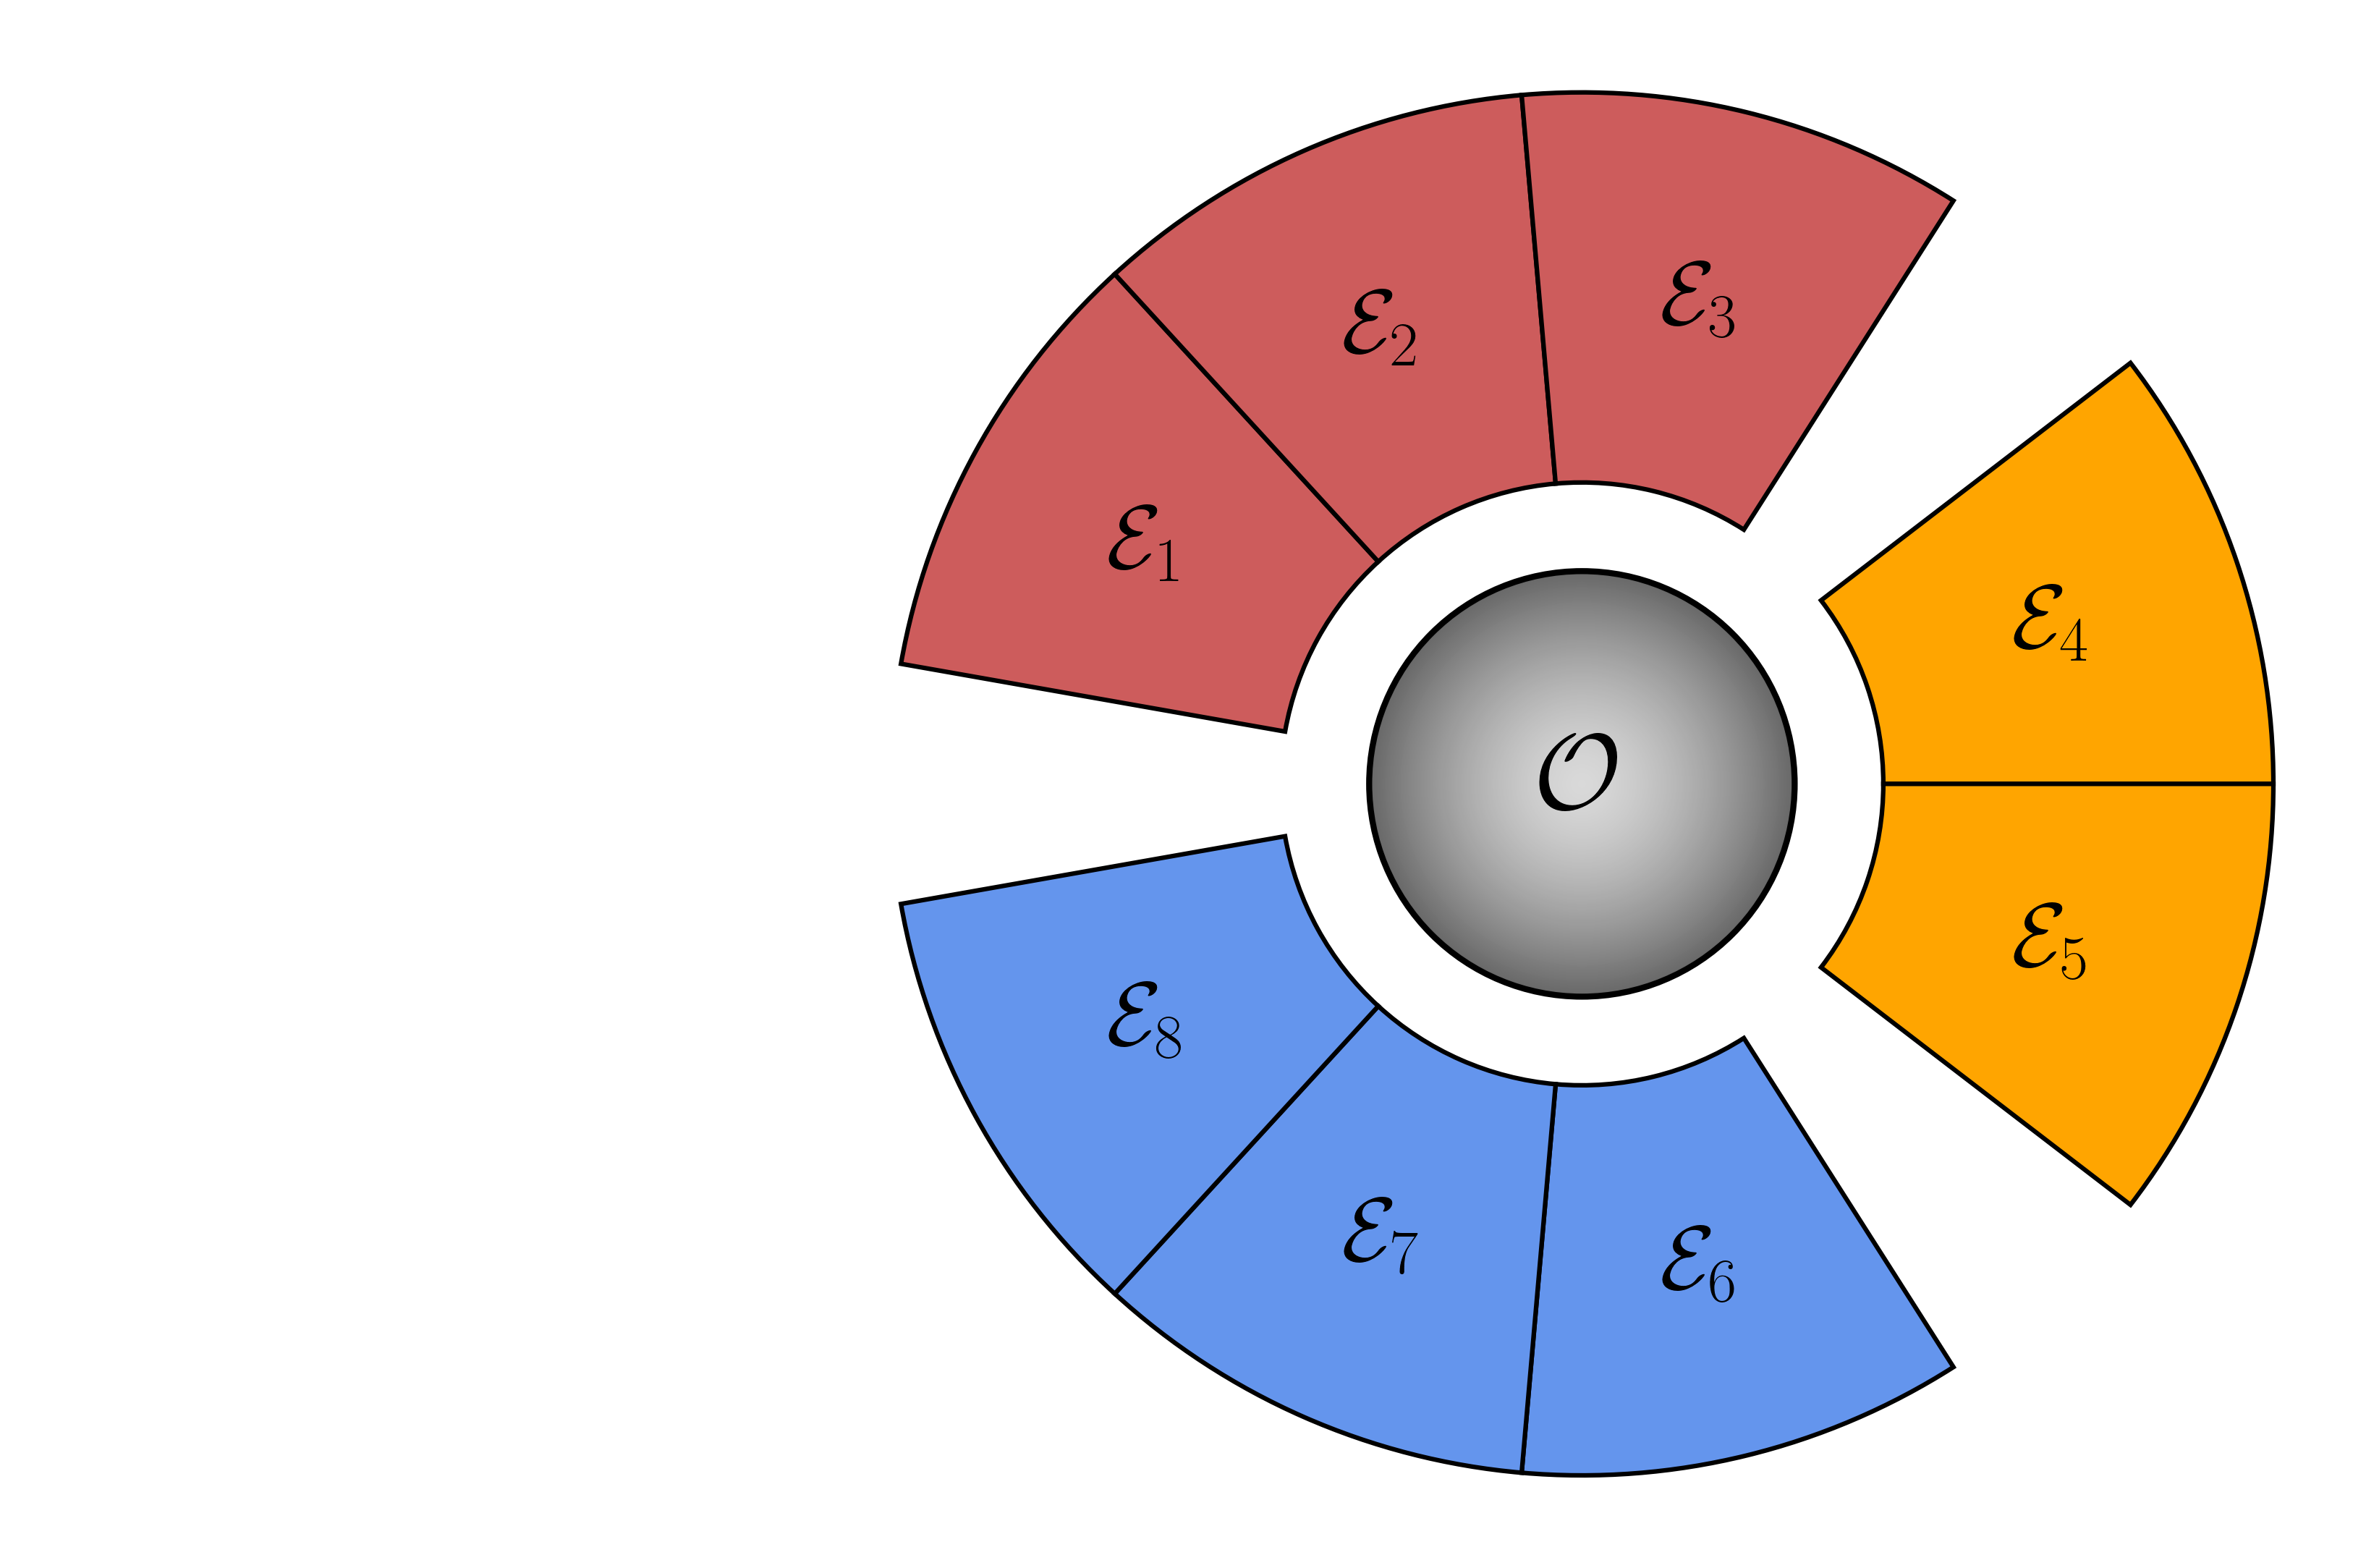

In [5]:
# QD - Zurek Picture Illustration 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1 (Đỏ): 3 mảnh, Cụm 2 (Vàng): 2 mảnh, Cụm 3 (Xanh): 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# Màu sắc theo thứ tự từ trái sang phải
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# Tọa độ vị trí cho hình tròn S (đặt bên trái, x_S < 0)
x_S, y_S = -3.5, 0.0                 # Tâm hình tròn S bên trái
r_S = 0.60                           # Bán kính hình tròn S

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC & THỨ TỰ TỪ TRÁI SANG PHẢI
# ==========================================
# Bắt đầu vẽ từ cụm đỏ ở phía trên bên trái (sau khe hở phía trái 180 độ)
# Đi theo chiều kim đồng hồ để xếp thứ tự mảnh từ trái sang phải (từ góc ~170° giảm dần về góc tiêu chuẩn)
start_angle = 180 - cluster_gap_deg / 2
current_angle = start_angle

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta1 = current_angle - slice_angle
        theta2 = current_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ ĐƯỜNG NẰM NGANG NỐI S VÀ O
# ==========================================


# ==========================================
# 3. VẼ HÌNH TRÒN O VÀ S (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{O}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)


# ==========================================
# 4. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
ax.set_xlim(x_S - r_S - 0.3, r_outer_env + 0.2)
ax.set_ylim(-r_outer_env - 0.2, r_outer_env + 0.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig(r"Figure\QD_Zurek_Illustration.eps", dpi=600, bbox_inches='tight')
plt.savefig(r"Figure\QD_Zurek_Illustration.png", dpi=600, bbox_inches='tight')
plt.show()

In [6]:
# QC-Zurek 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate

# Thiết lập độ phân giải cao cho hình ảnh
mpl.rcParams['figure.dpi'] = 600

# Khai báo các thanh ghi (giữ tên phân biệt để tránh lỗi trùng tên)
q0 = QuantumRegister(1, 'q0')
q1 = QuantumRegister(1, 'q1')
q2 = QuantumRegister(1, 'q2')
q3 = QuantumRegister(1, 'q3')
qdots = QuantumRegister(1, 'qdots')
q11 = QuantumRegister(1, 'q11')

# Khởi tạo mạch
qc = QuantumCircuit(q0, q1, q2, q3, qdots, q11)

# Khối khởi tạo
qc.h(q0)
qc.barrier()

# Khối tương tác môi trường
u3_gate = UGate(np.pi, 0, 0, label="U").control(1)
qc.append(u3_gate, [q0, q1])
qc.append(u3_gate, [q0, q2])
qc.append(u3_gate, [q0, q3])
qc.append(u3_gate, [q0, q11])

# 1. Vẽ mạch từ Qiskit bằng MPL backend
fig = qc.draw(output="mpl", idle_wires=True)
ax = fig.axes[0]

# 2. Xử lý các nhãn gốc: ẩn văn bản và xóa hộp bbox
original_y_coords = []
for text in ax.texts:
    x, y = text.get_position()
    # Các nhãn qubit luôn nằm bên trái dây (x < 0)
    if x < 0:
        original_y_coords.append(y)
        # Ẩn văn bản cũ
        text.set_visible(False)
        # !!! SỬA LỖI TẠI ĐÂY !!!
        # Xóa bỏ hộp bbox mặc định để nó không đè lên chữ mới
        text.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0.0))

# Sắp xếp tọa độ y thực tế từ trên xuống dưới
original_y_coords = sorted(original_y_coords, reverse=True)

# 3. Danh sách nhãn LaTeX theo đúng thứ tự: S -> E1 -> E2 -> E3 -> ⋮ -> E11
latex_labels = [
    r'$\mathcal{S}$',
    r'$\mathcal{E}_1$',
    r'$\mathcal{E}_2$',
    r'$\mathcal{E}_3$',
    r'$\vdots$',
    r'$\mathcal{E}_{10}$'
]

# 4. Ghi đè nhãn LaTeX mới vào đúng tọa độ y của từng dây
# Tinh chỉnh độ cao bằng y_offset nếu cần (ví dụ -0.05)
y_offset = -0.01
y_dots = original_y_coords[4]
x_offset = -0.95  # Dịch sang trái để tránh trùng với dây
for line in ax.lines:
    ydata = line.get_ydata()
    if len(ydata) > 0 and all(np.isclose(y, y_dots) for y in ydata):
        line.set_visible(False)  # Ẩn hoàn toàn wire
for y_pos, label in zip(original_y_coords, latex_labels):
    # Dấu 3 chấm đứng nhích nhẹ sang phải cho thẳng hàng với chữ E
    x_pos = x_offset if label == r'$\vdots$' else x_offset
    
    ax.text(
        x_pos, y_pos + y_offset, label,
        fontsize=20,
        ha='left', # Căn lề phải
        va='center', # Căn giữa theo chiều dọc
        color='black',
        zorder=100  # Đảm bảo chữ luôn nằm trên cùng
    )
fig.savefig(r"Figure\QC_Zurek.eps", dpi=600, bbox_inches='tight')
fig.savefig(r"Figure\QC_Zurek.png", dpi=600, bbox_inches='tight')
# Hiển thị hình
fig

KeyboardInterrupt: 

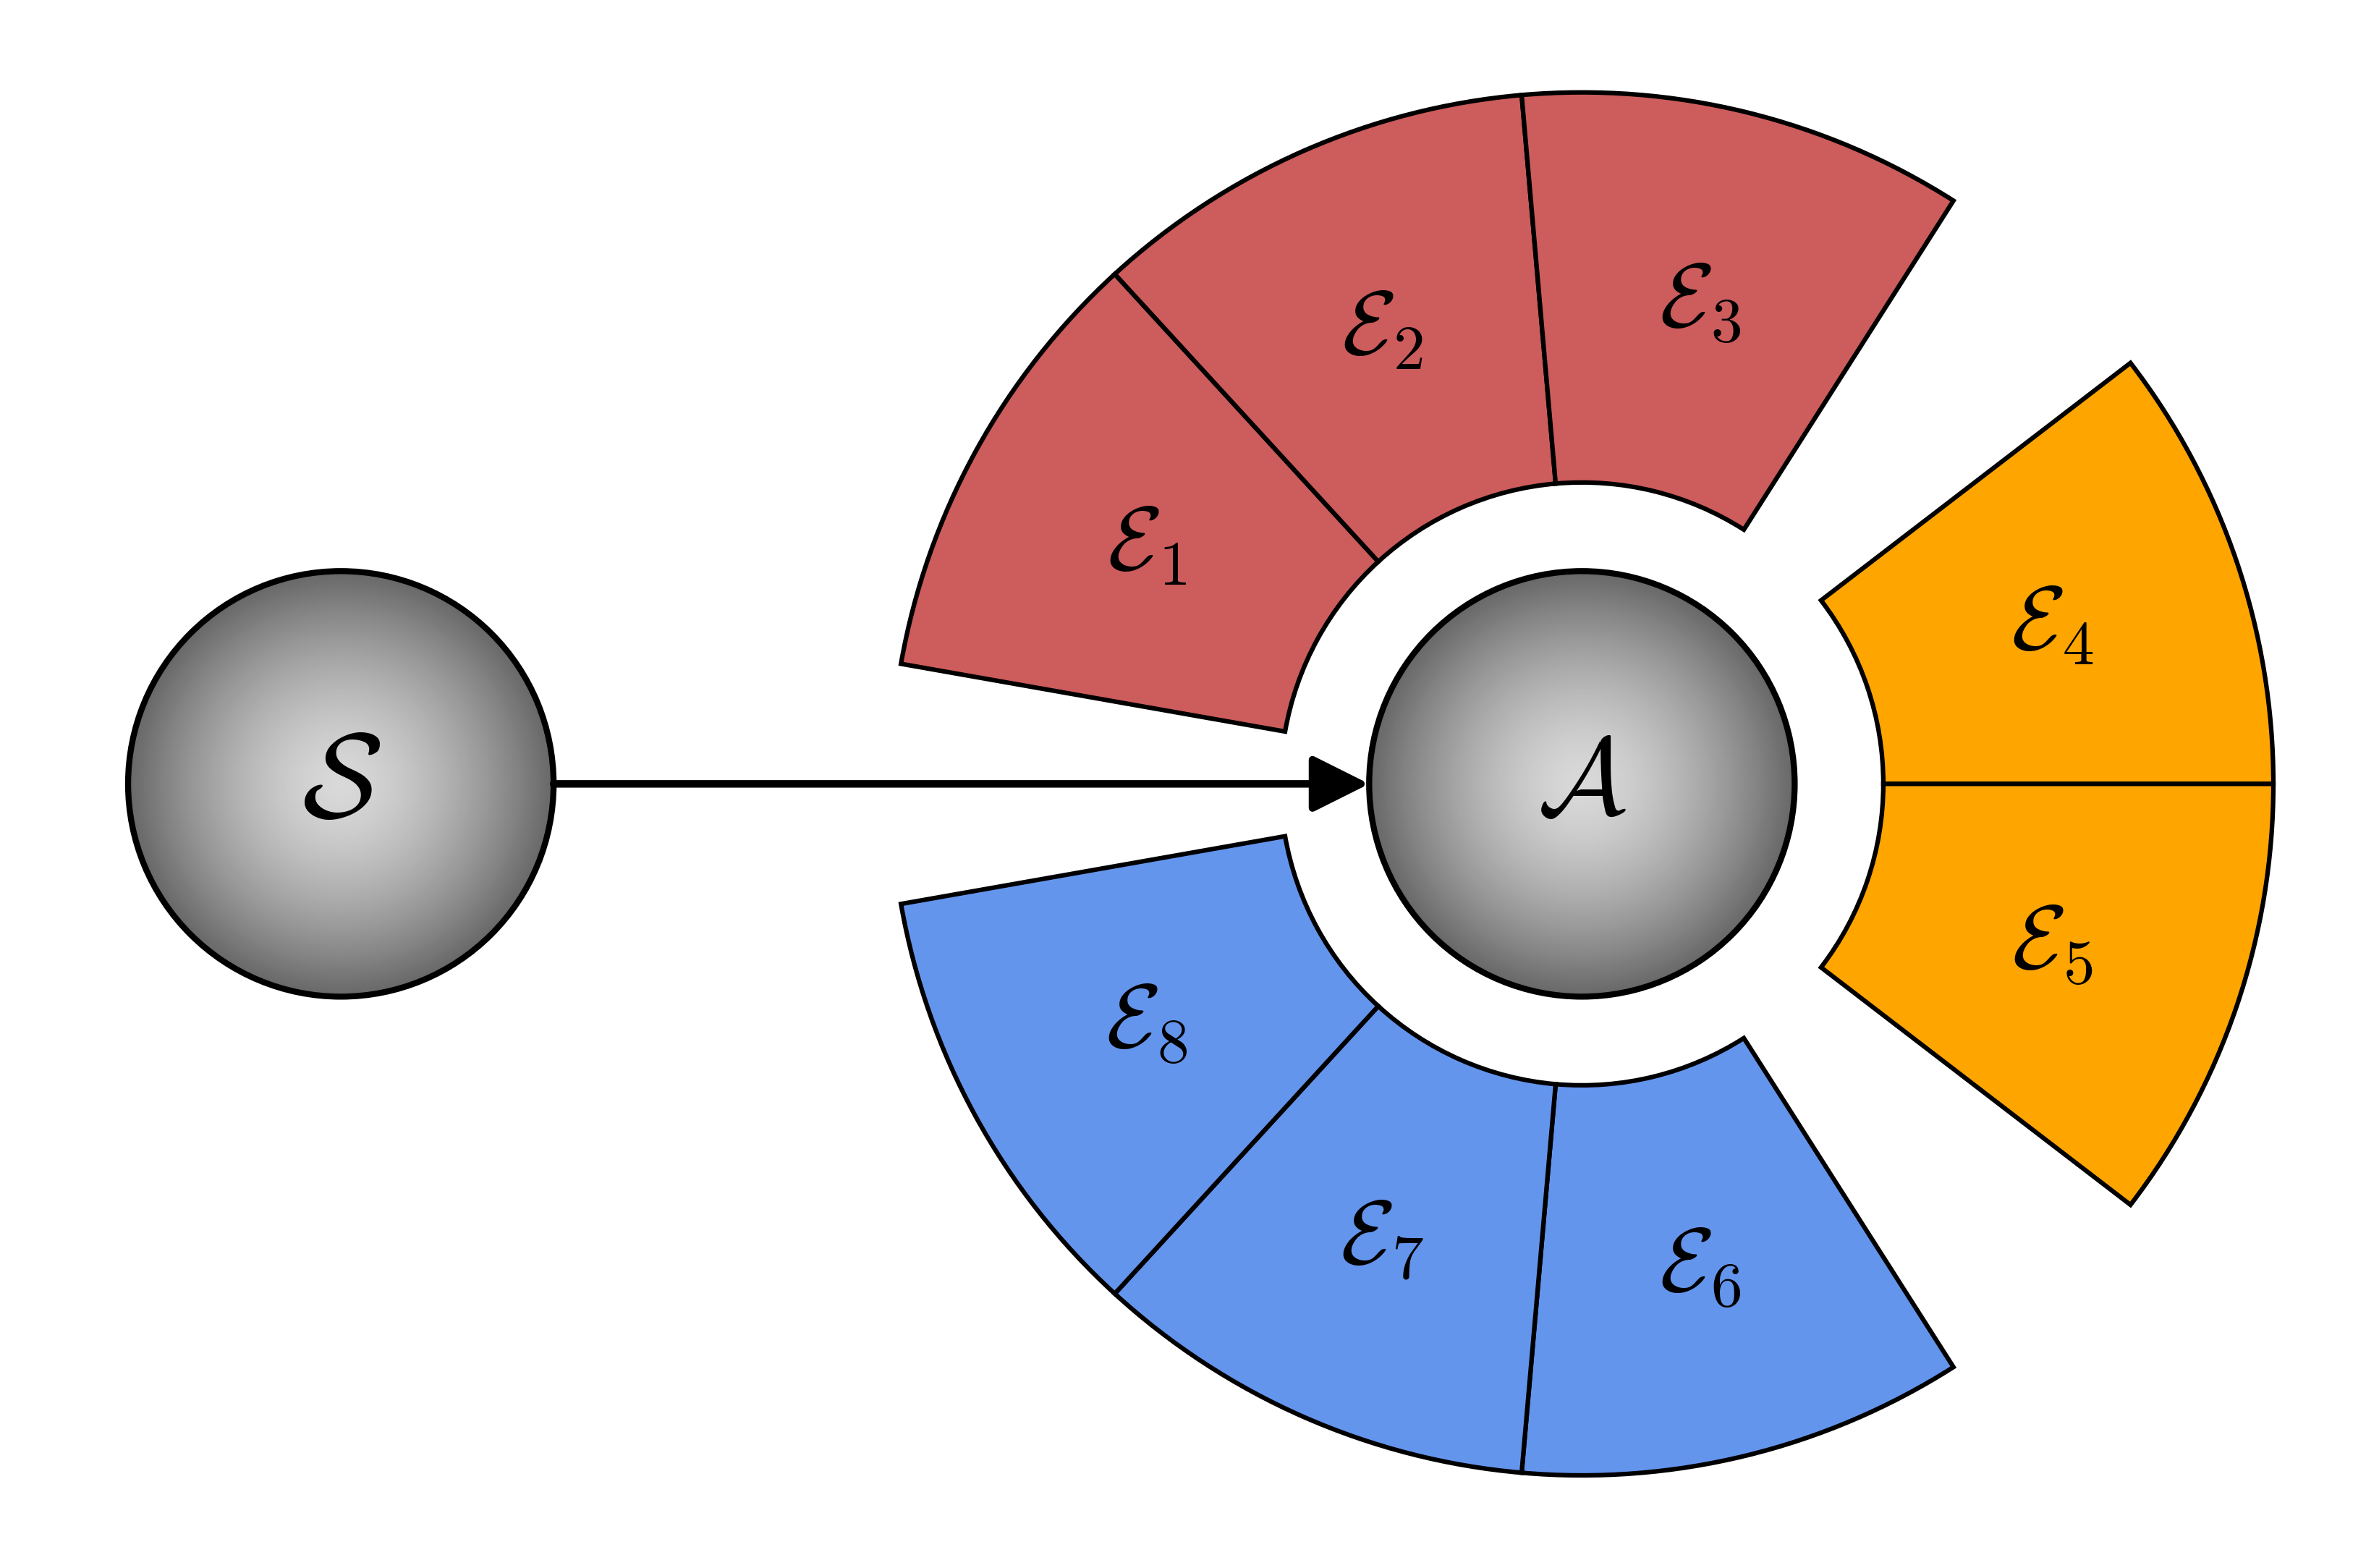

In [1]:
# QD - Wigner Picture Illustration 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1 (Đỏ): 3 mảnh, Cụm 2 (Vàng): 2 mảnh, Cụm 3 (Xanh): 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# Màu sắc theo thứ tự từ trái sang phải
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# Tọa độ vị trí cho hình tròn S (đặt bên trái, x_S < 0)
x_S, y_S = -3.5, 0.0                 # Tâm hình tròn S bên trái
r_S = 0.60                           # Bán kính hình tròn S

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC & THỨ TỰ TỪ TRÁI SANG PHẢI
# ==========================================
# Bắt đầu vẽ từ cụm đỏ ở phía trên bên trái (sau khe hở phía trái 180 độ)
# Đi theo chiều kim đồng hồ để xếp thứ tự mảnh từ trái sang phải (từ góc ~170° giảm dần về góc tiêu chuẩn)
start_angle = 180 - cluster_gap_deg / 2
current_angle = start_angle

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta1 = current_angle - slice_angle
        theta2 = current_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ ĐƯỜNG NẰM NGANG NỐI S VÀ O
# ==========================================
# Mũi tên từ S tới O qua khe hở phía trái
ax.annotate('', xy=(-r_object, 0), xytext=(x_S + r_S, 0),
            arrowprops=dict(arrowstyle='- |>', mutation_scale=40, color='black',
                            lw=2.5, shrinkA=0, shrinkB=0), zorder=3)

# ==========================================
# 3. VẼ HÌNH TRÒN O VÀ S (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{A}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)

# Vẽ S bên trái (-3.5, 0)
draw_gradient_circle(x_S, y_S, r_S, z_base=2)
ax.text(x_S, y_S, r'$\mathcal{S}$', fontsize=40, fontstyle='italic', ha='center', va='center', zorder=5)

# ==========================================
# 4. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
ax.set_xlim(x_S - r_S - 0.3, r_outer_env + 0.2)
ax.set_ylim(-r_outer_env - 0.2, r_outer_env + 0.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig(r"Figure\QD_Wigner_Illustration.eps", dpi=600, bbox_inches='tight')
plt.savefig(r"Figure\QD_Wigner_Illustration.png", dpi=600, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


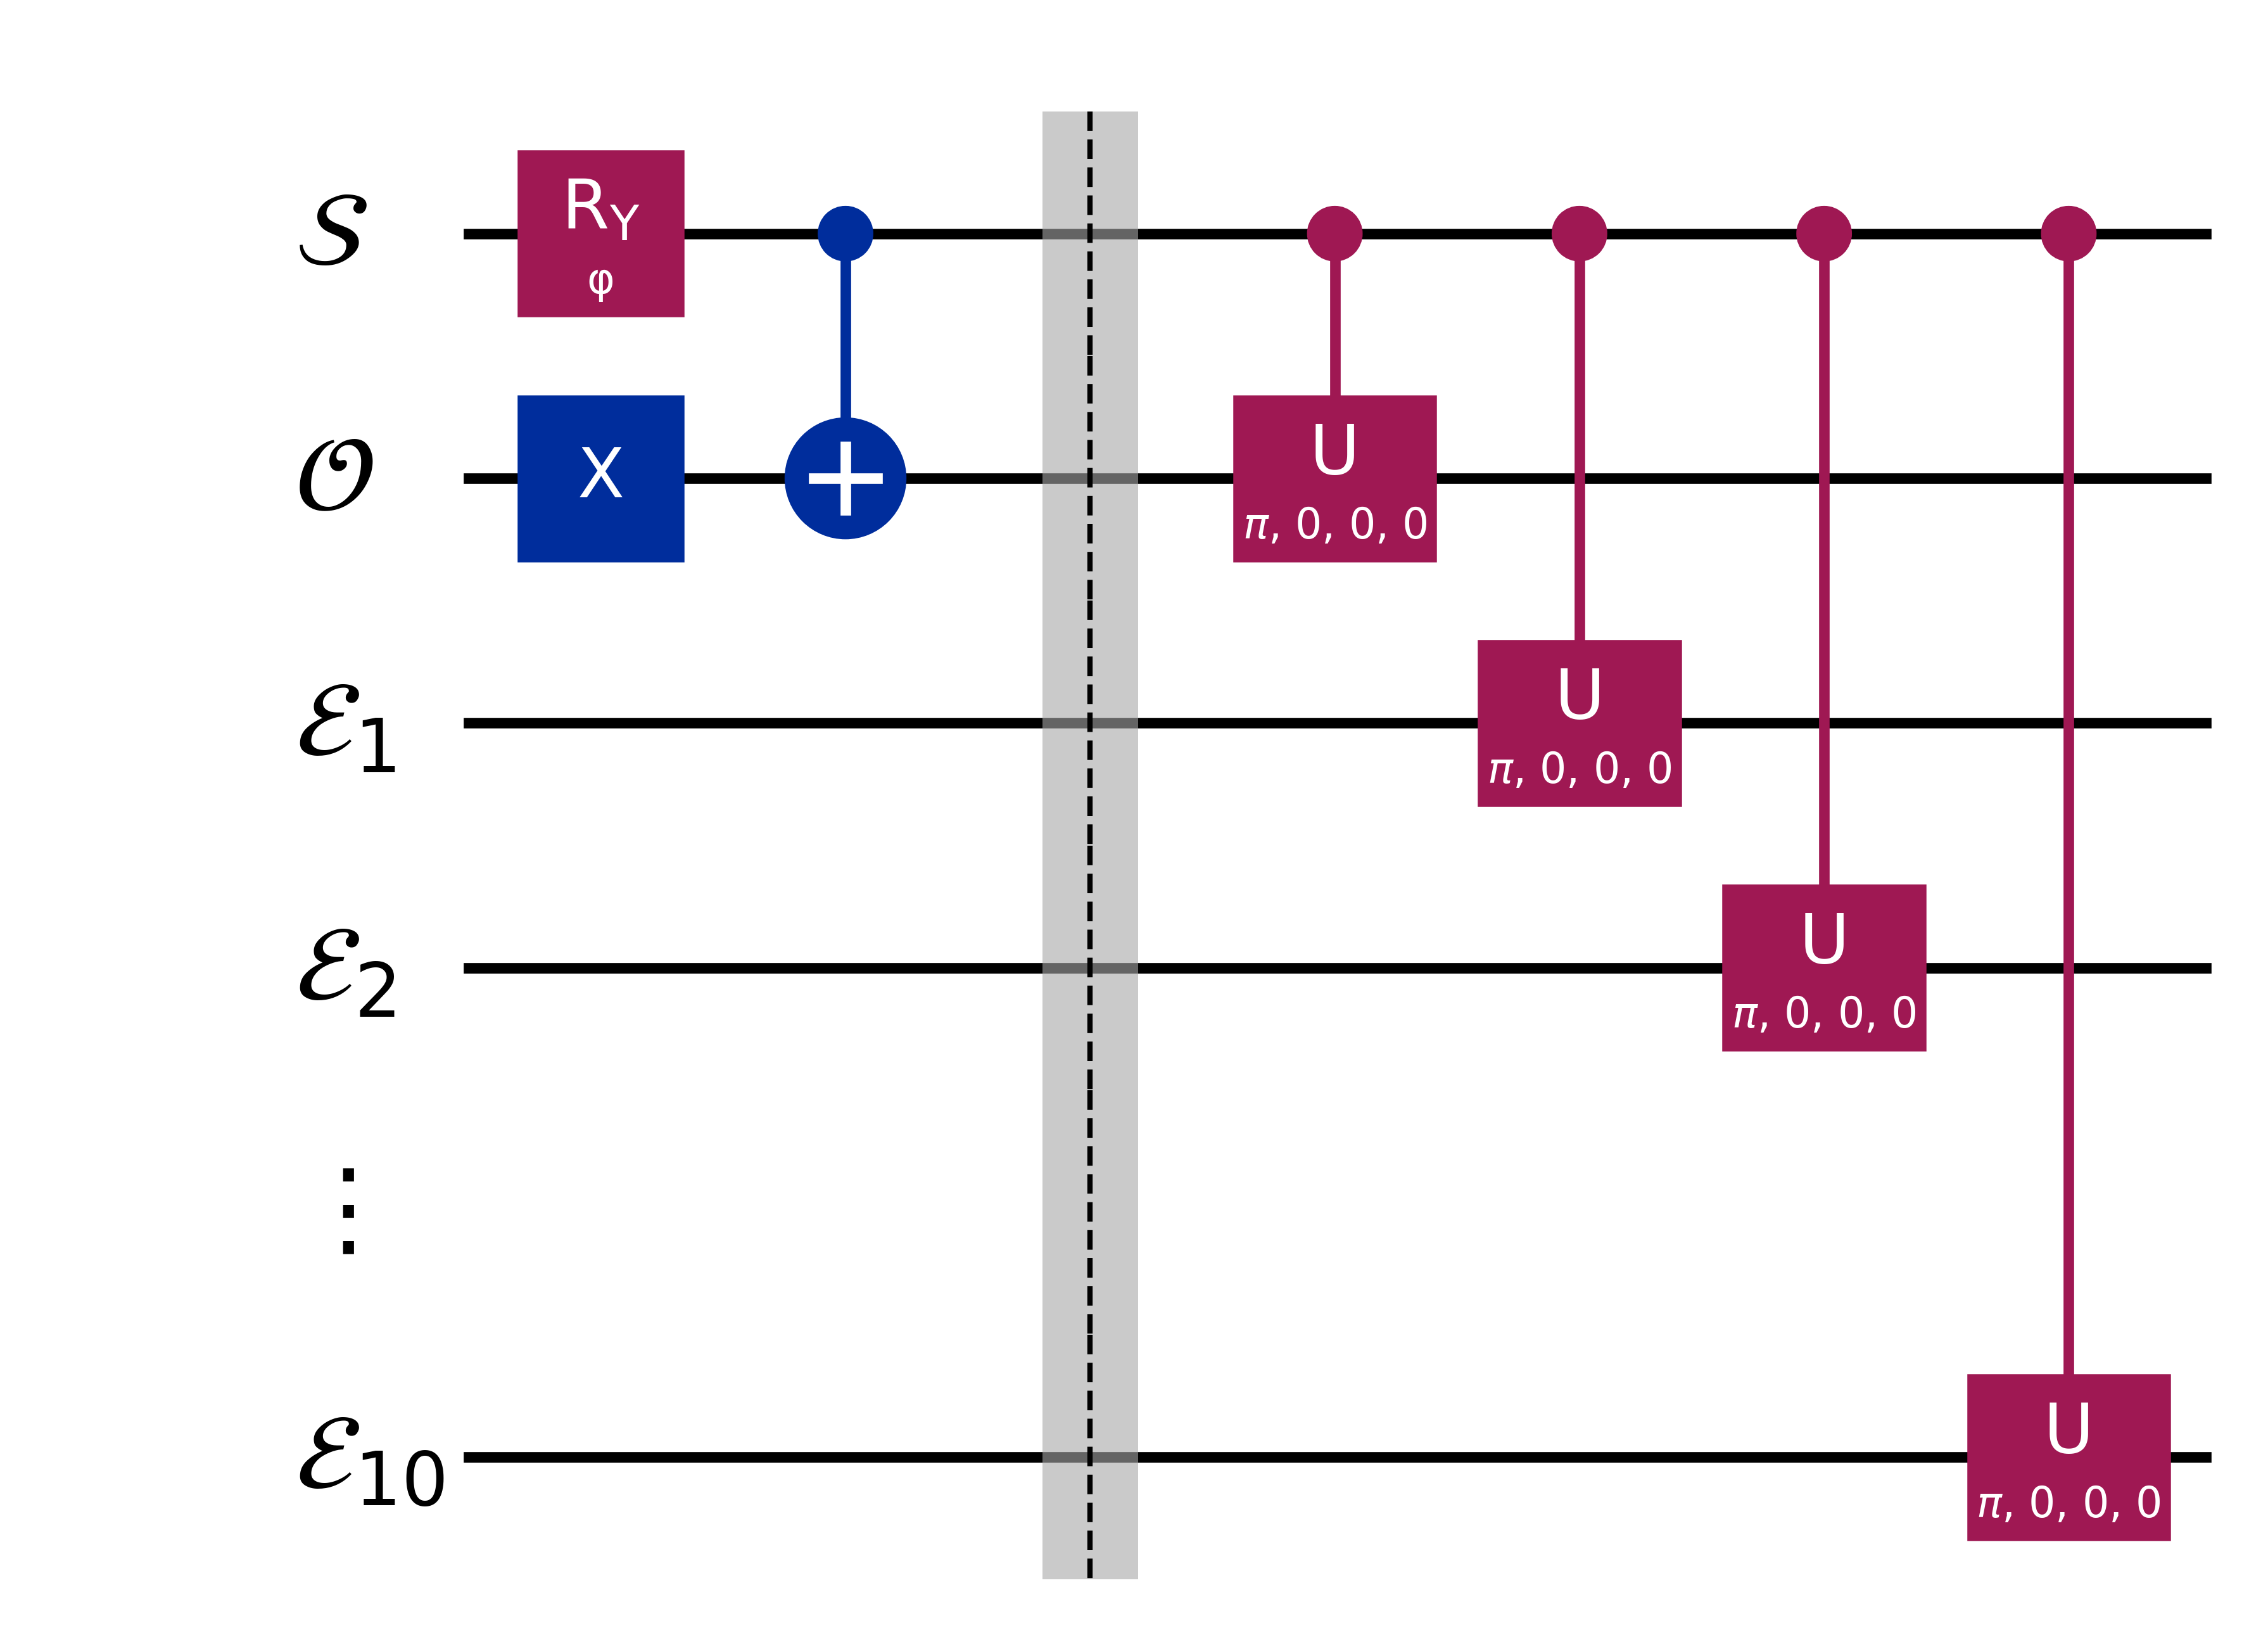

In [ ]:
# QC-Wigner
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate

# Thiết lập độ phân giải cao cho hình ảnh
mpl.rcParams['figure.dpi'] = 600
phi = Parameter('φ')

# Khai báo các thanh ghi (giữ tên phân biệt để tránh lỗi trùng tên)
q0 = QuantumRegister(1, 'q0') # System
q1 = QuantumRegister(1, 'q1') # Observer
q2 = QuantumRegister(1, 'q2') # environment
q3 = QuantumRegister(1, 'q3')
q4 = QuantumRegister(1, 'q4')
qdots = QuantumRegister(1, 'qdots')
q12 = QuantumRegister(1, 'q12')

# Khởi tạo mạch
qc = QuantumCircuit(q0, q1, q2, q3, qdots, q12)

# Khối khởi tạo
qc.ry(phi, q0)
qc.x(q1)
qc.cx(q0, q1)
qc.barrier()

# Khối tương tác môi trường
u3_gate = UGate(np.pi, 0, 0, label="U").control(1)
qc.append(u3_gate, [q0, q1])
qc.append(u3_gate, [q0, q2])
qc.append(u3_gate, [q0, q3])
qc.append(u3_gate, [q0, q12])

# 1. Vẽ mạch từ Qiskit bằng MPL backend
fig = qc.draw(output="mpl", idle_wires=True)
ax = fig.axes[0]

# 2. Xử lý các nhãn gốc: ẩn văn bản và xóa hộp bbox
original_y_coords = []
for text in ax.texts:
    x, y = text.get_position()
    # Các nhãn qubit luôn nằm bên trái dây (x < 0)
    if x < 0:
        original_y_coords.append(y)
        # Ẩn văn bản cũ
        text.set_visible(False)
        # !!! SỬA LỖI TẠI ĐÂY !!!
        # Xóa bỏ hộp bbox mặc định để nó không đè lên chữ mới
        text.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0.0))

# Sắp xếp tọa độ y thực tế từ trên xuống dưới
original_y_coords = sorted(original_y_coords, reverse=True)

# 3. Danh sách nhãn LaTeX theo đúng thứ tự: S -> E1 -> E2 -> E3 -> ⋮ -> E11
latex_labels = [
    r'$\mathcal{S}$',
    r'$\mathcal{O}$',
    r'$\mathcal{E}_1$',
    r'$\mathcal{E}_2$',
    r'$\vdots$',
    r'$\mathcal{E}_{10}$'
]

# 4. Ghi đè nhãn LaTeX mới vào đúng tọa độ y của từng dây
# Tinh chỉnh độ cao bằng y_offset nếu cần (ví dụ -0.05)
y_offset = -0.01
y_dots = original_y_coords[4]
x_offset = -0.95  # Dịch sang trái để tránh trùng với dây
for line in ax.lines:
    ydata = line.get_ydata()
    if len(ydata) > 0 and all(np.isclose(y, y_dots) for y in ydata):
        line.set_visible(False)  # Ẩn hoàn toàn wire
for y_pos, label in zip(original_y_coords, latex_labels):
    # Dấu 3 chấm đứng nhích nhẹ sang phải cho thẳng hàng với chữ E
    x_pos = x_offset if label == r'$\vdots$' else x_offset
    
    ax.text(
        x_pos, y_pos + y_offset, label,
        fontsize=20,
        ha='left', # Căn lề phải
        va='center', # Căn giữa theo chiều dọc
        color='black',
        zorder=100  # Đảm bảo chữ luôn nằm trên cùng
    )
fig.savefig(r"Figure\QC_Wigner.eps", dpi=600, bbox_inches='tight')
fig.savefig(r"Figure\QC_Wigner.png", dpi=600, bbox_inches='tight')
# Hiển thị hình
fig

In [ ]:
# 3D QMI Simulation - Zurek model (11 qubits)

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle
from joblib import Parallel, delayed
from tqdm import tqdm

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        # System prepare |+> using Hadamard gate 
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits, rho=None):
            trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
            
            if rho is None:
                rho = self.DensityMatrix()
            return partial_trace(rho, trace_out_qubits).data
    

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    

# ================== Helper Function ==================

def compute_qmi(theta, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, 0, numQubits)
    
    # 1. Lấy ma trận toàn phần 1 LẦN DUY NHẤT
    full_rho = qc.DensityMatrix()
    
    # 2. Dùng hàm get_reduced_dm của bạn và truyền full_rho vào
    rho_S = qc.get_reduced_dm([0], rho=full_rho)
    
    qmi_vals = []
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        
        # Gọi hàm get_reduced_dm quen thuộc của bạn
        rho_Ef   = qc.get_reduced_dm(Ef, rho=full_rho)
        rho_SEf  = qc.get_reduced_dm([0] + Ef, rho=full_rho)
        
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
        
    return qmi_vals

# ================== MAIN SIMULATION ==================
numQubits = 11
phi = 0
env_qubits = list(range(1, numQubits))  # q1..q10
QI_calc = QuantumInformation()

theta_vals = np.linspace(0, 2*np.pi, 50)   # 50 steps
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100  # fragment size %

Theta, FS = np.meshgrid(theta_vals, fs)

# Parallel + Progress bar
results = Parallel(n_jobs=-1)(
    delayed(compute_qmi)(theta, env_qubits, numQubits, QI_calc) 
    for theta in tqdm(theta_vals, desc="Simulating QMI vs Theta")
)

QMI_matrix = np.array(results).T  # chuyển kết quả thành ma trận


# Sau khi tính xong QMI_matrix
data_to_save = {
    "FS": FS,
    "Theta": Theta,
    "QMI_matrix": QMI_matrix
}

# Lưu vào file pkl
with open("3D_QMI_Zurek.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

Simulating QMI vs Theta: 100%|██████████| 50/50 [04:11<00:00,  5.03s/it] 


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


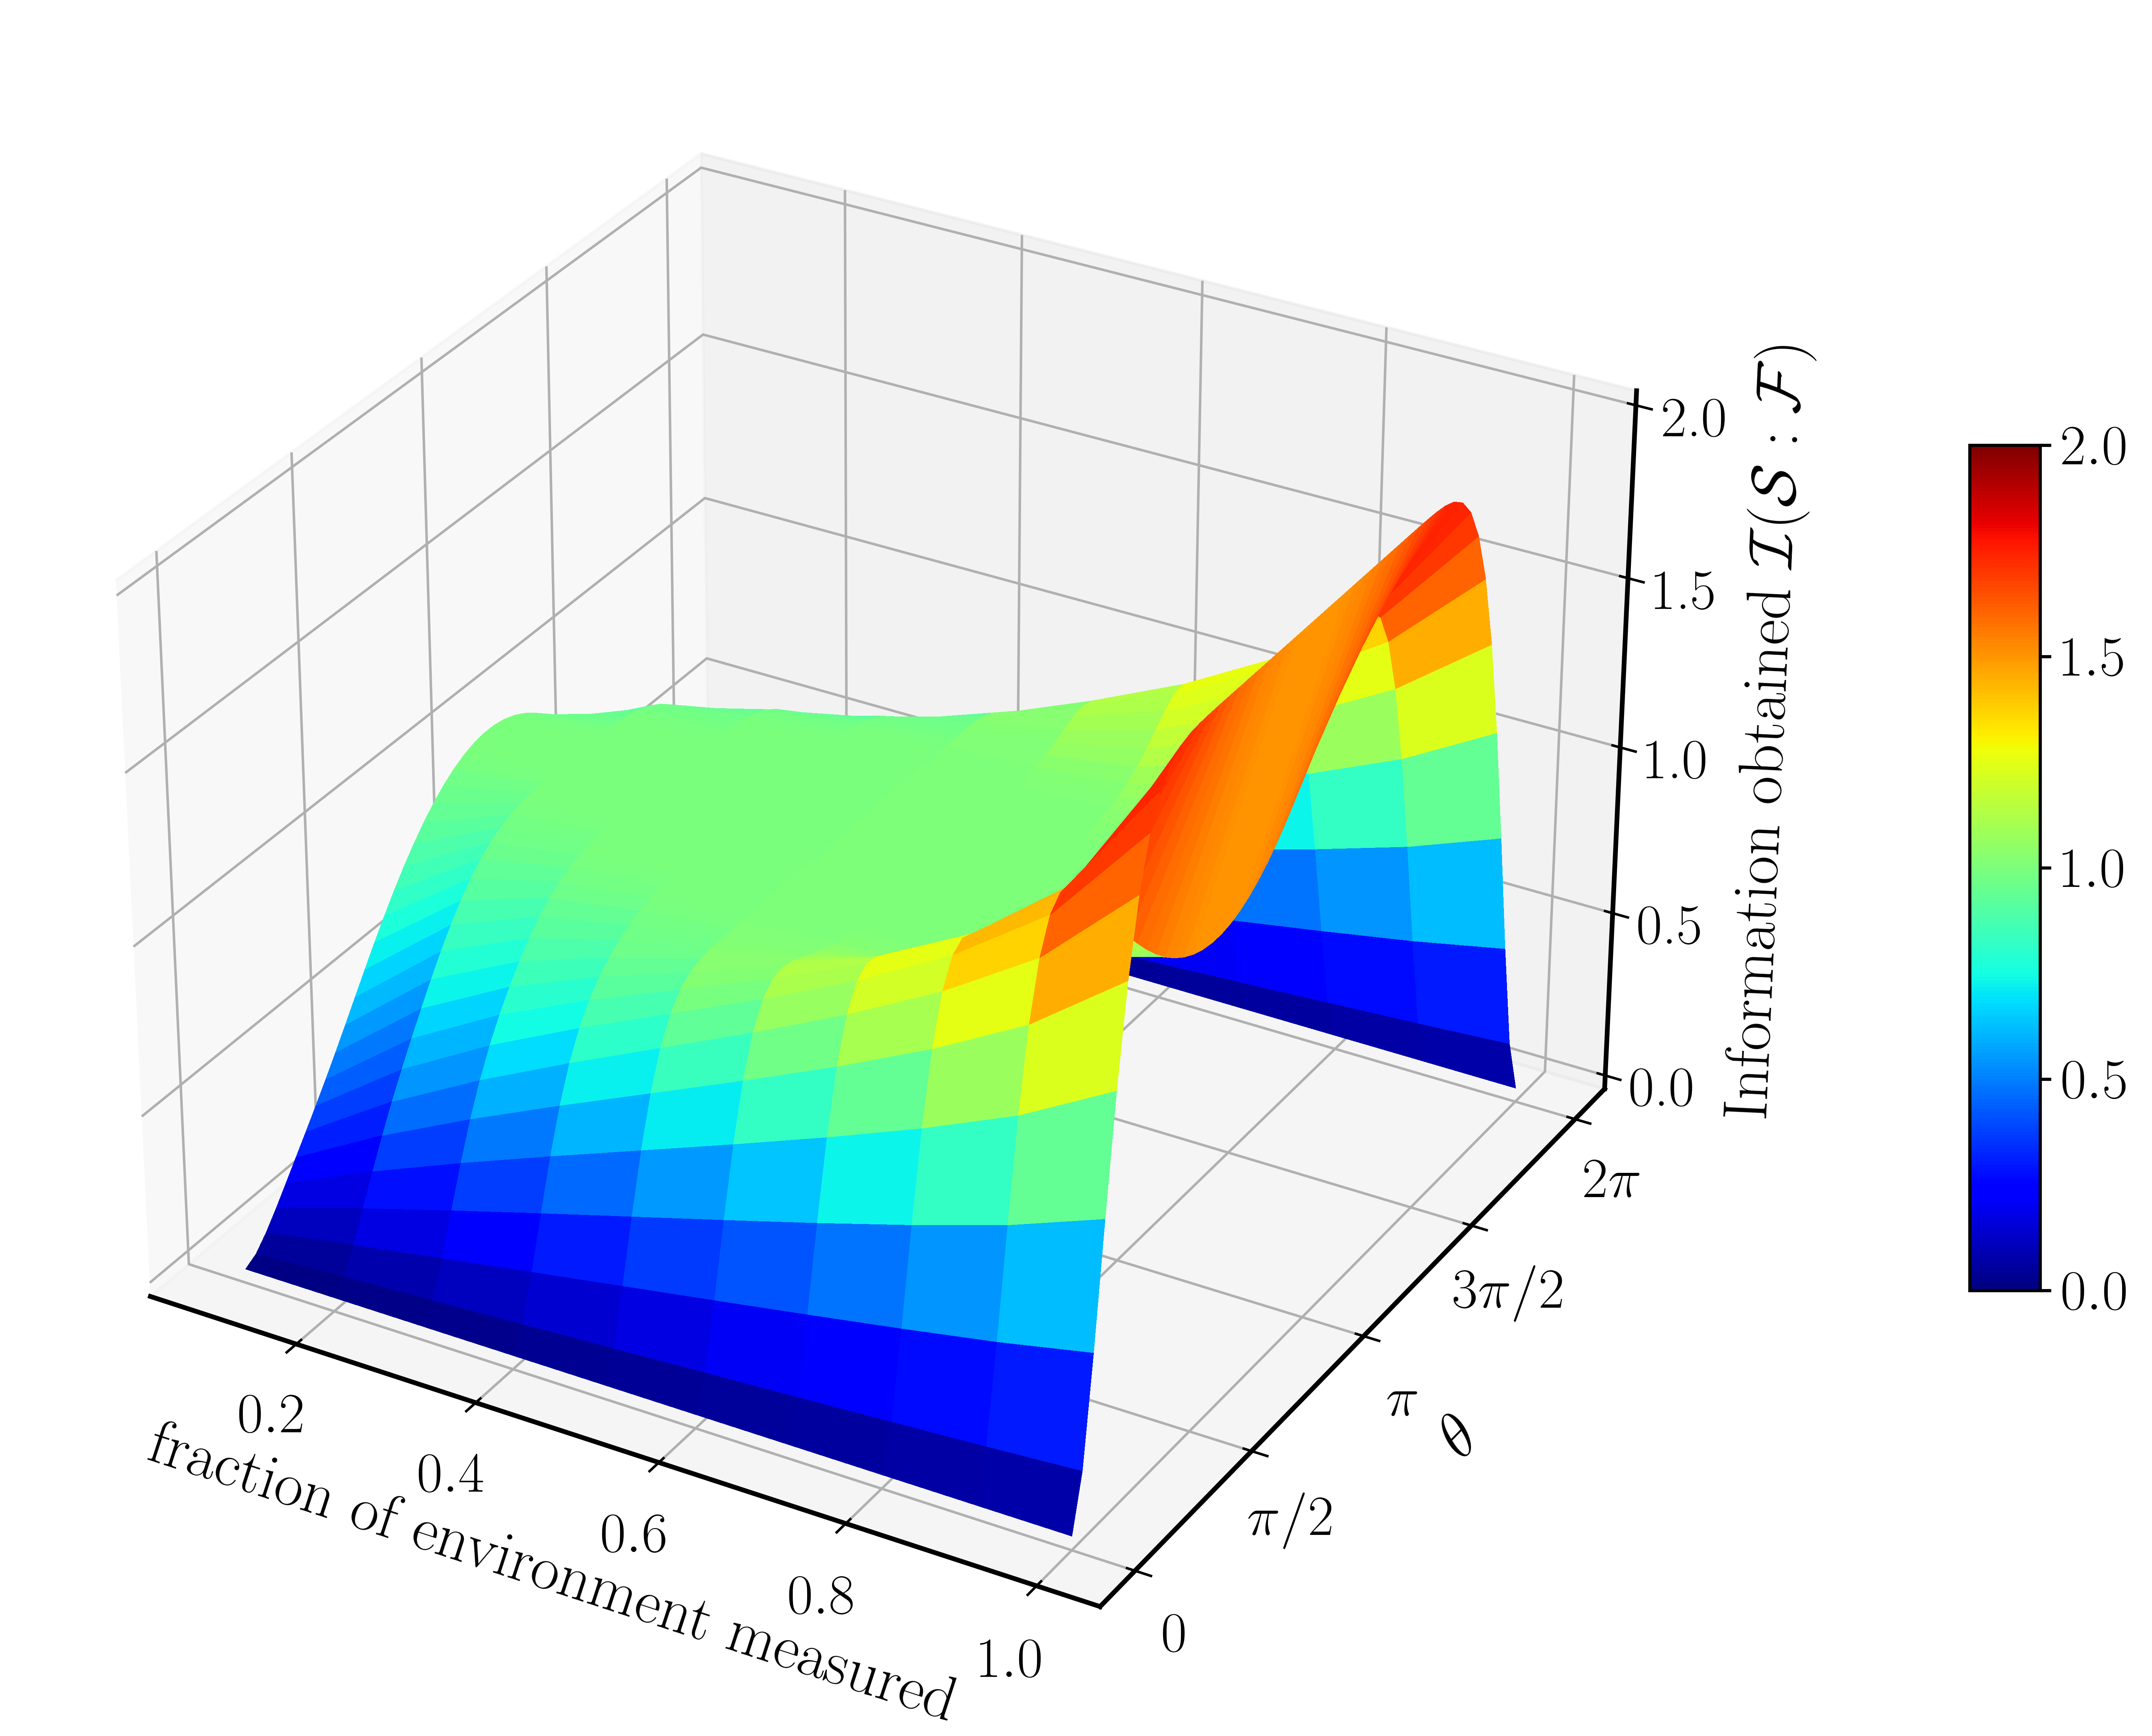

In [ ]:
# PLOT Zurek model - QMI 3D Simulation
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['savefig.transparent'] = False

# Load dữ liệu từ file pkl
with open("3D_QMI_Zurek.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
FS_norm = FS / 100.0
Theta = loaded_data["Theta"]
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ lại 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    FS_norm, Theta, QMI_matrix, 
    cmap='jet', 
    shade=False,        # Tắt bóng mờ chứa alpha ngầm
    antialiased=False,  # Tắt khử răng cưa chứa alpha ở mép
    linewidth=0,
    vmin=0.0,   # Cố định giá trị nhỏ nhất của dải màu
    vmax=2.0    # Cố định giá trị lớn nhất của dải màu

)


ax.set_xlabel('fraction of environment measured', fontsize=20, labelpad = 8)

ax.set_ylabel(r'$\theta$', fontsize=20, labelpad=8)
ax.set_zlabel("Information obtained " + r'$\mathcal{I}(\mathcal{S}:\mathcal{F})$', 
              fontsize=20, labelpad=8)
# Chỉnh ticks cho trục z
ax.set_zticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax.set_zticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])



ax.set_title('', fontsize=40, ha = 'center')


ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])



ax.tick_params(axis='x', labelsize=18, width=2.5)
ax.tick_params(axis='y', labelsize=18, width=2.5)
ax.tick_params(axis='z', labelsize=18, width=2.5)

cbar = fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.1)
cbar.set_ticks([0.0, 0.5, 1.0, 1.5, 2.0])
cbar.ax.tick_params(labelsize=18, width=1.0)
cbar.outline.set_linewidth(1.0)

fig.subplots_adjust(right=0.95, bottom=0.02, top=0.95, left=0.01)
for artist in fig.get_children():
    if hasattr(artist, 'set_alpha'):
        artist.set_alpha(1.0)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.line.set_linewidth(1.5)  # Thay đổi độ dày đường viền
    axis.line.set_color('black')   # Đảm bảo màu đen rõ nét

fig.savefig(r"Figure\3D_QMI_Zurek.png", dpi=600, bbox_inches='tight')
fig.savefig(r"Figure\3D_QMI_Zurek.eps", dpi=600,    transparent=False,  # Tắt transparency
    facecolor="white",  # Ép nền màu trắng đục
    edgecolor="none",
    pad_inches=0.02,
)
plt.show()



In [ ]:
# Zurek model - QMI & Holevo & Discord
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from qiskit import qpy

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        # System prepare |+> using Hadamard gate 
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
   
    # Holevo Bound χ(S:F) = S(E) - Σ p_i S(E|i) 
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:

                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)

                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) 
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr
    
# ========== MAIN ==========
numQubits = 11 # q0 system, q1..q10 environment
theta, phi = np.pi, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(1, numQubits))

results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):

    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)

    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Quantum Discord
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)

qcircuit_obj = qc.Circuit()

rho_E_full  = qc.get_reduced_dm(env_qubits)

rho_SE_full = qc.get_reduced_dm([0]+env_qubits)

QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

Holevo_E_full = QI_calc.HolevoBound(rho_SE_full, rho_S)

Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ===================== SAVING ====================

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,
    "QMI_S_Efull": QMI_S_Efull,
    "Holevo_E_full": Holevo_E_full,
    "Discord_SE_full": Discord_SE_full,
    "qcircuit_obj": qcircuit_obj
}

with open("QMI_Holevo_Discord_Zurek.pkl", "wb") as f:
    pickle.dump(data, f)

print("="*50)
print(f"Saved QMI_Holevo_Discord_Zurek.pkl to the working directory: {os.getcwd()}")
print("="*50)


Saved QMI_Holevo_Discord_Zurek.pkl to the working directory: d:\Quantum Darwinism Macbook project\Quantum-Darwinism


<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

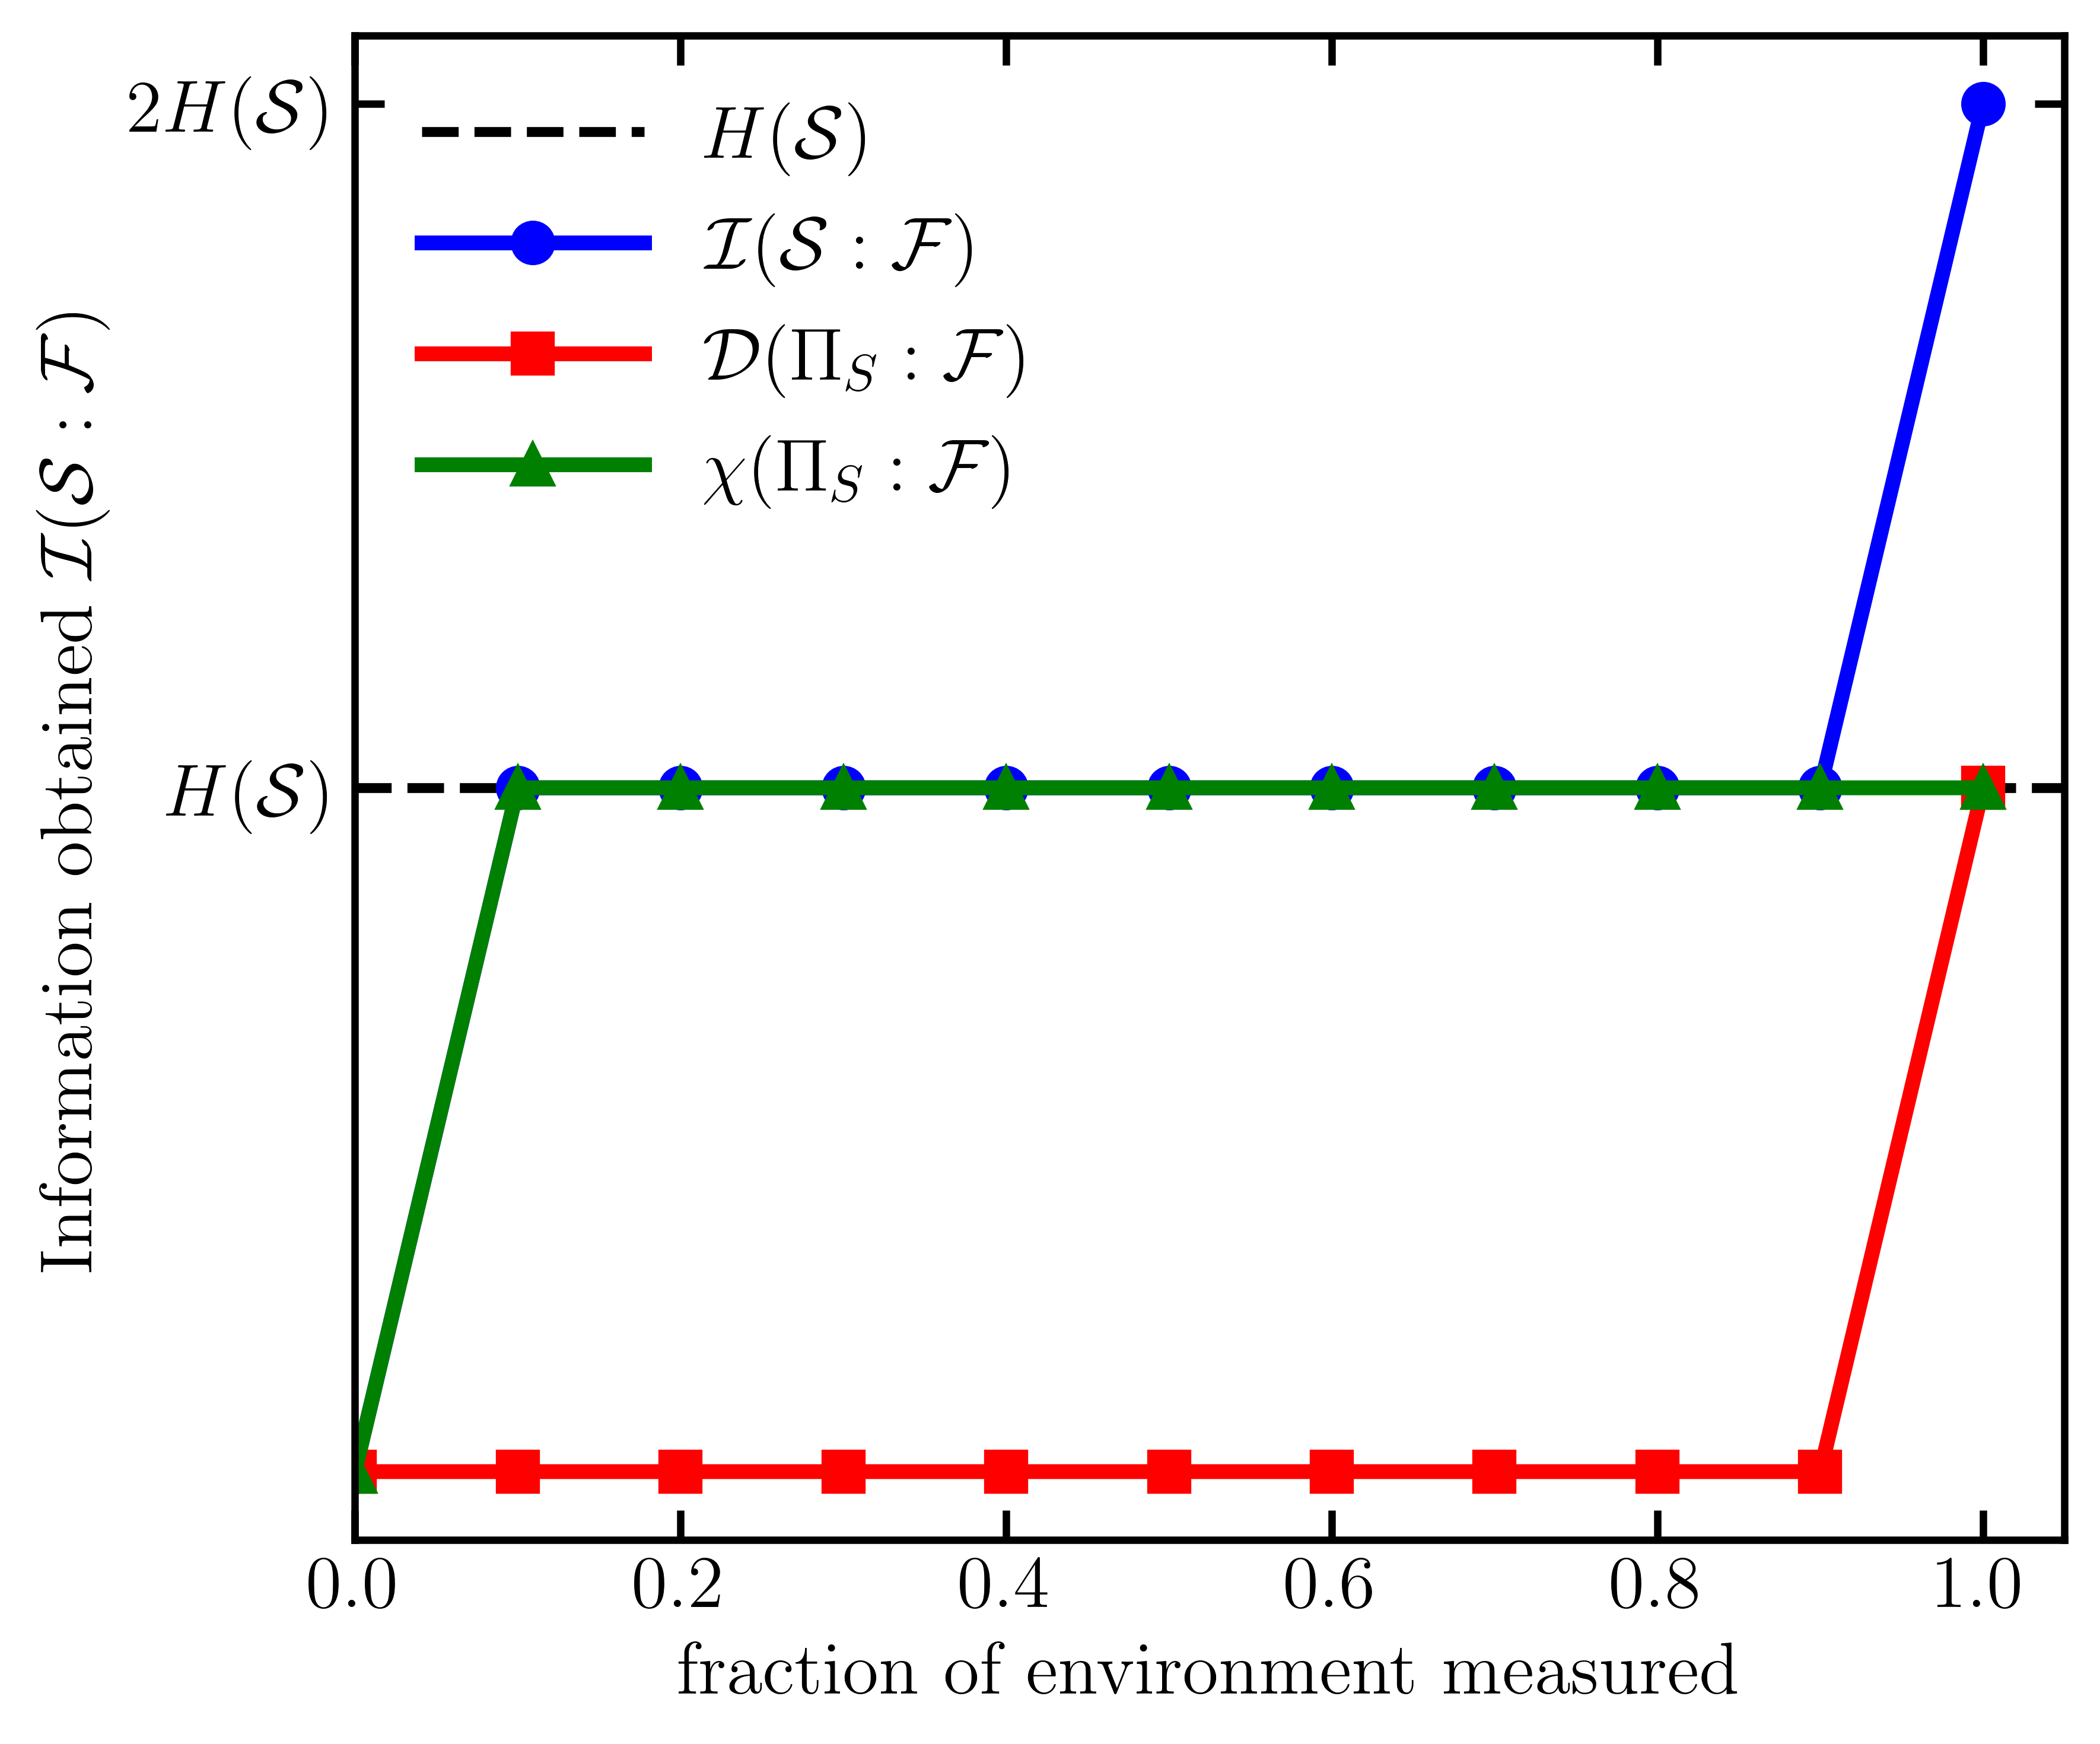

In [ ]:
# PLOT Zurek model - QMI & Holevo & Discord for theta = pi

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# Working directory

with open("QMI_Holevo_Discord_Zurek.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")

plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment measured', fontsize=15)
plt.ylabel('Information obtained ' + r'$\mathcal{I}(\mathcal{S}:\mathcal{F})$', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()



plt.savefig(r"Figure\QMI_Holevo_Discord_Zurek.png", dpi=600, bbox_inches='tight')
plt.savefig(
    r"Figure\QMI_Holevo_Discord_Zurek.eps",
    format="eps",
    transparent=False,  # Tắt transparency
    facecolor="white",  # Ép nền màu trắng đục
    edgecolor="none",
    pad_inches=0.02,
)

display(plt)

In [1]:
# 3D QMI Simulation - Wigner model (12 qubits)

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate

class QCircuit:    
    def __init__(self, theta, phi_sys, phi_env, n):  
        self.theta = theta        # góc cho controlled-U3
        self.phi_sys = phi_sys    # góc quay Ry của hệ thống
        self.phi_env = phi_env    # góc cho controlled-U3
        self.n = n        

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System & Observer
        qc.ry(self.phi_sys, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        qc.barrier()
        
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi_env, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits, rho=None):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        if rho is None:
            rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data


class QuantumInformation(): 
    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
        
    # Quantum mutual information I(A:B) = H(A) + H(B) - H(AB)
    def quantum_mutual_I(self, A_State, B_State, AB_State):
        VNE_A  = self.VNE(A_State)
        VNE_B  = self.VNE(B_State)
        VNE_AB = self.VNE(AB_State)
        return VNE_A + VNE_B - VNE_AB


# ================== Helper Function ==================

def compute_all_qmi(theta, phi_sys, phi_env, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, phi_sys, phi_env, numQubits)
    full_rho = qc.DensityMatrix()
    
    # Lay cac trang thai don le cho S va O
    rho_S = qc.get_reduced_dm([0], rho=full_rho)
    rho_O = qc.get_reduced_dm([1], rho=full_rho)
    rho_SO = qc.get_reduced_dm([0, 1], rho=full_rho)
    
    # 1. Tinh I(S:O) - Gia tri scalar (1 gia tri duy nhat cho moi phi_sys)
    qmi_SO = QI_calc.quantum_mutual_I(rho_S, rho_O, rho_SO)
    
    qmi_SE_vals = []
    qmi_EO_vals = []
    
    # 2. Tinh I(S:Ef) va I(Ef:O) theo tung phan khuc Ef
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        
        # Reduced density matrices
        rho_Ef  = qc.get_reduced_dm(Ef, rho=full_rho)
        rho_SEf = qc.get_reduced_dm([0] + Ef, rho=full_rho)
        rho_OEf = qc.get_reduced_dm([1] + Ef, rho=full_rho)
        
        # I(S:Ef)
        qmi_SE = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
        qmi_SE_vals.append(qmi_SE)
        
        # I(Ef:O)
        qmi_EO = QI_calc.quantum_mutual_I(rho_Ef, rho_O, rho_OEf)
        qmi_EO_vals.append(qmi_EO)
        
    return qmi_SE_vals, qmi_SO, qmi_EO_vals


# ================== MAIN SIMULATION ==================
if __name__ == "__main__":
    numQubits = 12
    theta = np.pi       # co dinh
    phi_env = 0         # co dinh
    env_qubits = list(range(2, numQubits))
    QI_calc = QuantumInformation()

    phi_sys_vals = np.linspace(0, 2*np.pi, 50)   # vary phi_sys
    fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

    PhiSys, FS = np.meshgrid(phi_sys_vals, fs)

    # Parallel computation
    results = Parallel(n_jobs=-1)(
        delayed(compute_all_qmi)(theta, phi_sys, phi_env, env_qubits, numQubits, QI_calc) 
        for phi_sys in tqdm(phi_sys_vals, desc="Simulating QMI (S-E, S-O, E-O)")
    )

    # Tach ket qua
    qmi_SE_list = [r[0] for r in results]
    qmi_SO_list = [r[1] for r in results]
    qmi_EO_list = [r[2] for r in results]

    # Matrix 2D (Dimensions: len(fs) x len(phi_sys_vals))
    QMI_SE_matrix = np.array(qmi_SE_list).T
    QMI_EO_matrix = np.array(qmi_EO_list).T

    # Array 1D cho I(S:O) vì nó không phụ thuộc vào phân khúc f (Dimensions: len(phi_sys_vals))
    # Nhưng nếu bạn muốn map lên cùng kích thước 2D meshgrid với FS, dùng np.tile:
    QMI_SO_matrix = np.tile(np.array(qmi_SO_list), (len(fs), 1))

    # Lưu đầy đủ dữ liệu vào file pickle
    data_to_save = {
        "FS": FS,
        "Phi_sys": PhiSys,
        "QMI_SE_matrix": QMI_SE_matrix,  # I(S:E)
        "QMI_SO_matrix": QMI_SO_matrix,  # I(S:O) 
        "QMI_EO_matrix": QMI_EO_matrix   # I(E:O)
    }

    with open("3D_QMI_Wigner.pkl", "wb") as f:
        pickle.dump(data_to_save, f)

    print("Đã tính xong và lưu thành công 3 đại lượng QMI vào file '3D_QMI_Wigner.pkl'!")

Simulating QMI (S-E, S-O, E-O):   0%|          | 0/50 [00:00<?, ?it/s]

Simulating QMI (S-E, S-O, E-O): 100%|██████████| 50/50 [01:16<00:00,  1.52s/it]


Đã tính xong và lưu thành công 3 đại lượng QMI vào file '3D_QMI_Wigner.pkl'!


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


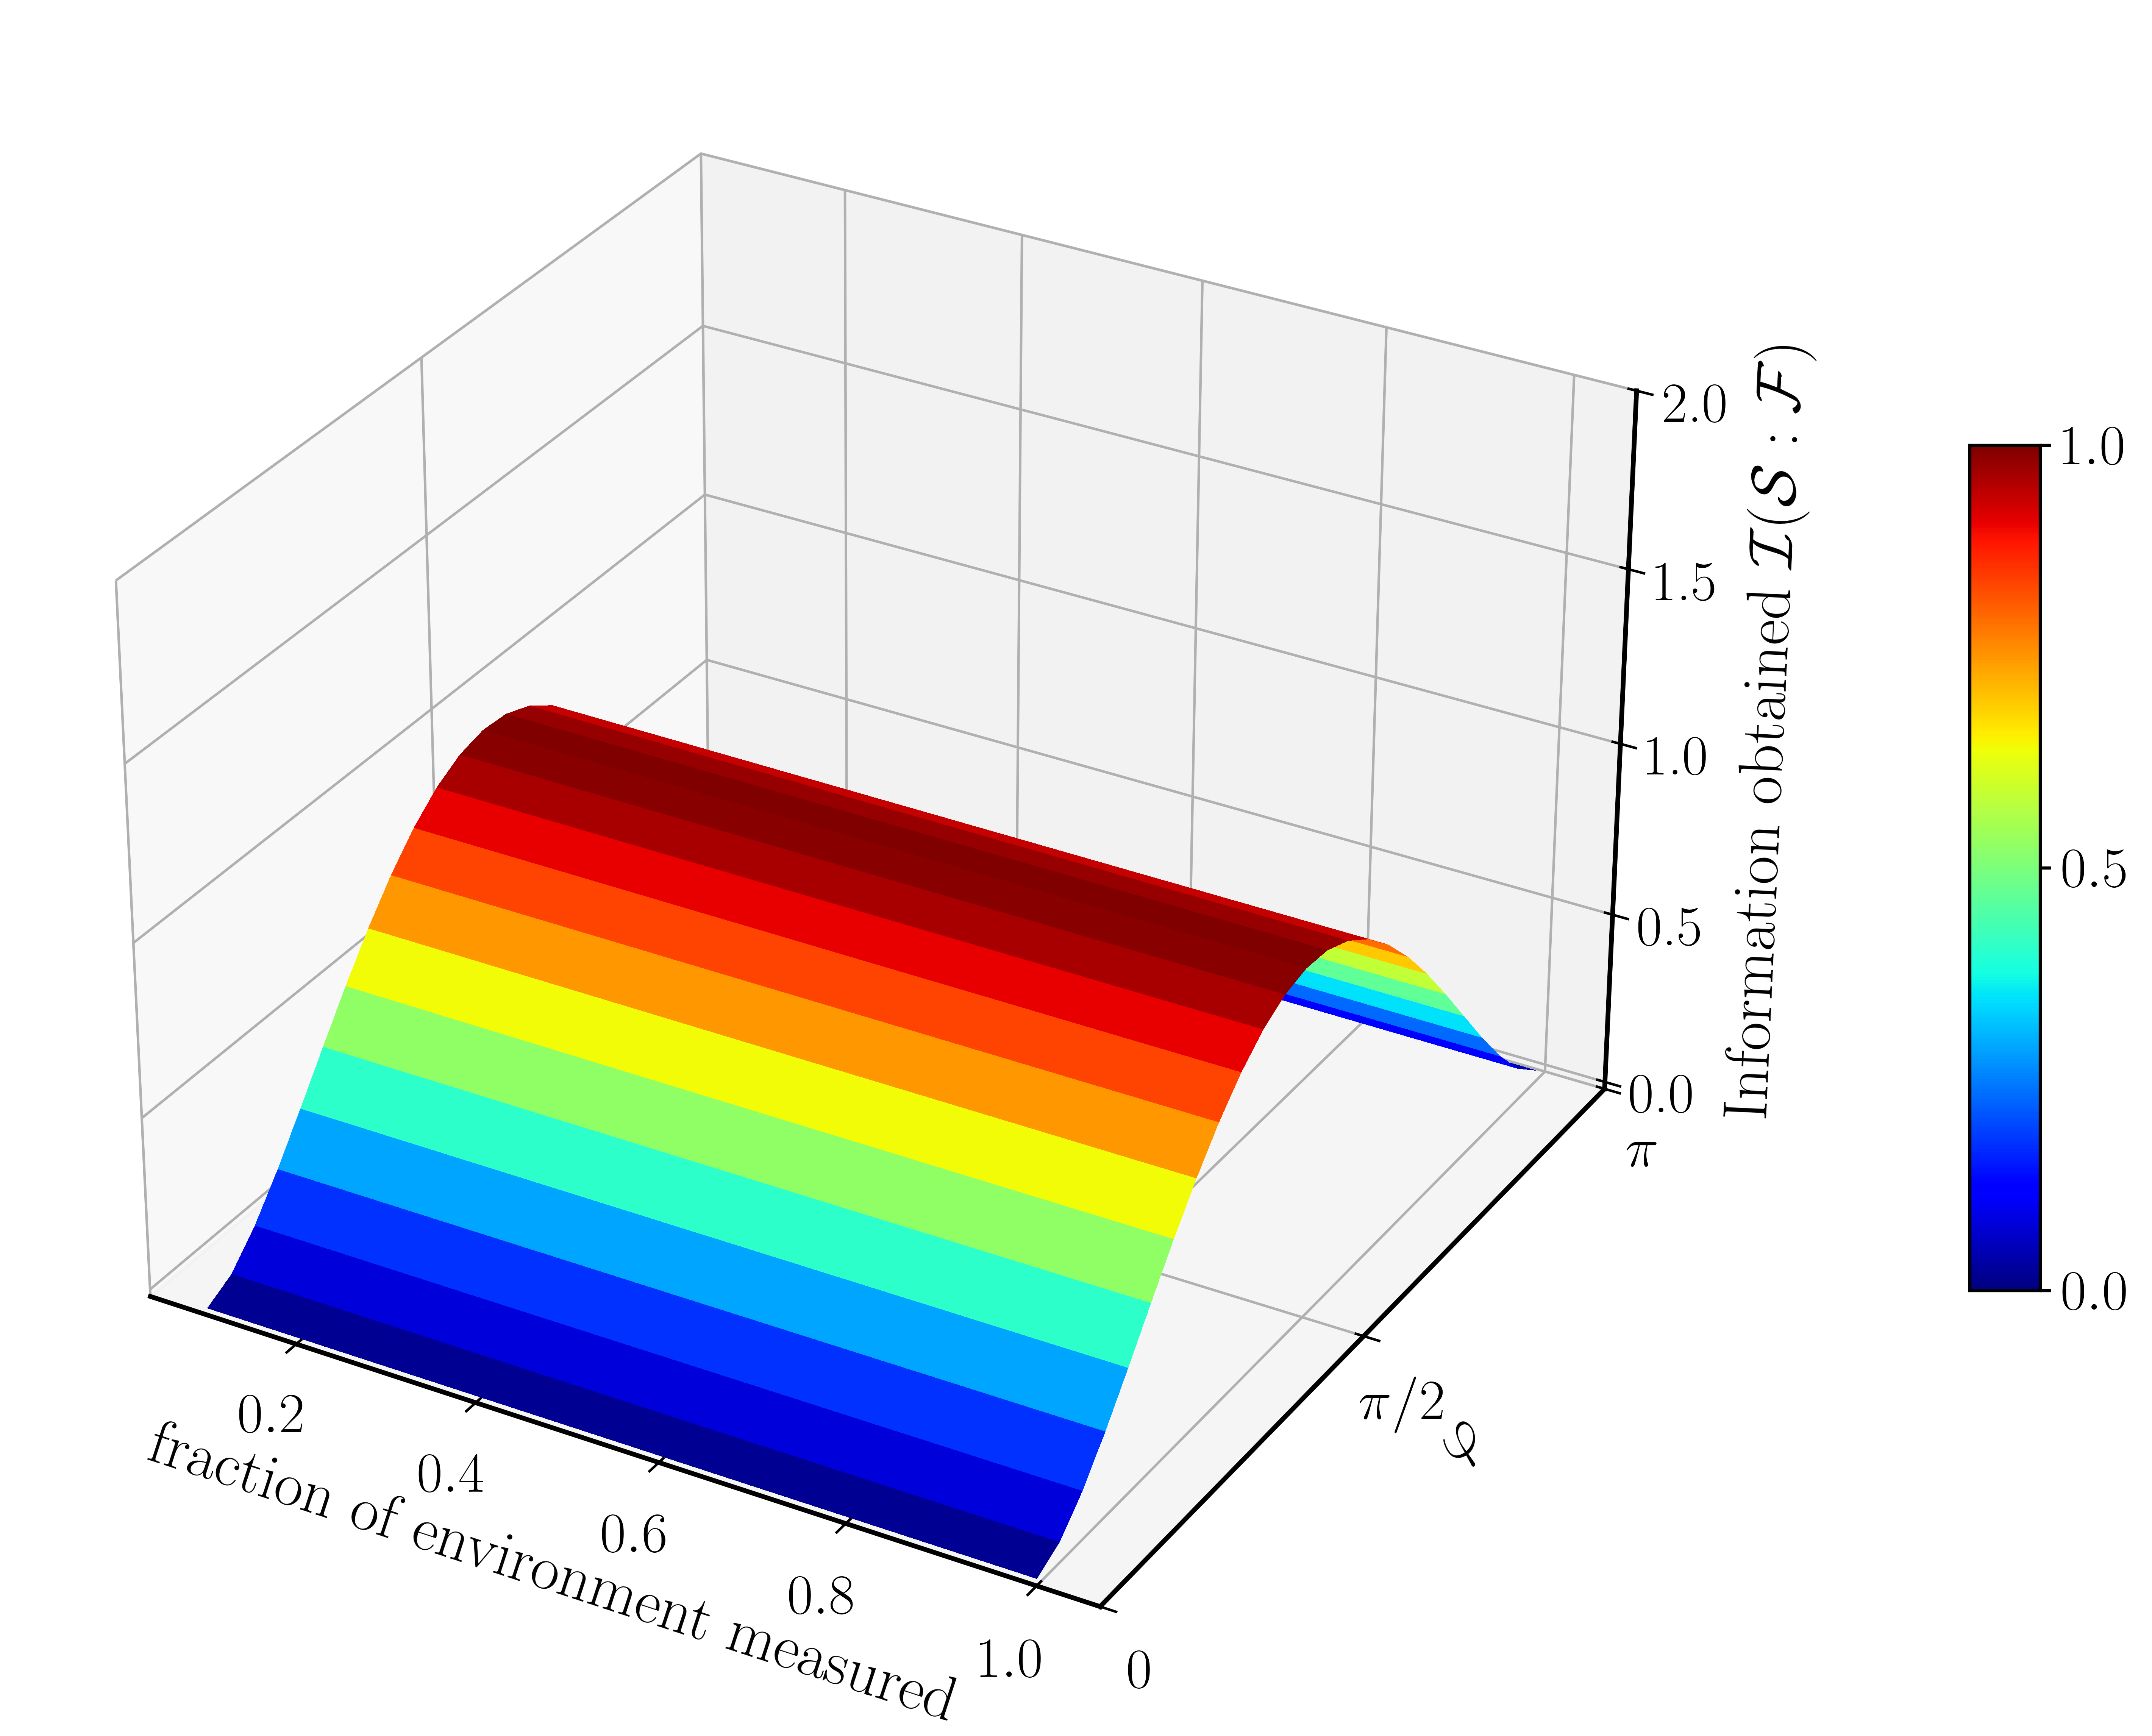

In [ ]:
# Plot_3D_QMI_Wigner_Limit_Pi.


import os
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['savefig.transparent'] = False

# Load dữ liệu từ file pkl
with open("3D_QMI_Wigner.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
FS_norm = FS / 100.0
PhiSys = loaded_data["Phi_sys"]
QMI_matrix = loaded_data["QMI_SE_matrix"]

# ------------------------------------------------------------
# GIỚI HẠN DỮ LIỆU TRỤC PHI TỪ 0 ĐẾN PI
# ------------------------------------------------------------
mask = PhiSys <= (np.pi + 1e-5)  # Thêm eps nhỏ để không mất điểm pi do sai số float

FS_norm_filtered = FS_norm[mask].reshape(FS_norm.shape[0], -1)
PhiSys_filtered = PhiSys[mask].reshape(PhiSys.shape[0], -1)
QMI_matrix_filtered = QMI_matrix[mask].reshape(QMI_matrix.shape[0], -1)

# Vẽ 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_alpha(1.0)
ax.patch.set_alpha(1.0)

surf = ax.plot_surface(
    FS_norm_filtered, PhiSys_filtered, QMI_matrix_filtered, 
    cmap='jet', 
    shade=False,        # Tắt bóng mờ chứa alpha ngầm
    antialiased=False,  # Tắt khử răng cưa
    linewidth=0,
    alpha=1.0,
    vmin=0.0,   # Cố định giá trị nhỏ nhất của dải màu
    vmax=1.0    # Cố định giá trị lớn nhất của dải màu
)

ax.set_xlabel('fraction of environment measured', fontsize=20, labelpad=8)
ax.set_ylabel(r'$\varphi$', fontsize=20, labelpad=8)
ax.set_zlabel(r'Information obtained $\mathcal{I}(\mathcal{S}:\mathcal{F})$', 
              fontsize=20, labelpad=8)

# Giới hạn góc nhìn trục Y
ax.set_ylim(0, np.pi)

# Chỉnh ticks cho trục Z
ax.set_zticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax.set_zticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

# Chỉnh ticks cho trục Y (chỉ tới pi)
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels(['0', r'$\pi/2$', r'$\pi$'])

# Tăng độ dày cạnh trục X, Y, Z
ax.tick_params(axis='x', labelsize=18, width=2.5)
ax.tick_params(axis='y', labelsize=18, width=2.5)
ax.tick_params(axis='z', labelsize=18, width=2.5)

cbar = fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.1)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=18, width=1.0)
cbar.outline.set_linewidth(1.0)

fig.subplots_adjust(right=0.95, bottom=0.02, top=0.95, left=0.01)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.line.set_linewidth(1.5)  # Độ dày đường viền
    axis.line.set_color('black')   # Màu đen rõ nét

# Lưu kết quả
os.makedirs("Figure", exist_ok=True)
fig.savefig(r"Figure/3D_QMI_Wigner.png", dpi=600, bbox_inches='tight')
fig.savefig(
    "Figure/3D_QMI_Wigner.eps", 
    format="eps", 
    dpi=600, 
    transparent=False, 
    facecolor="white", 
    edgecolor="none",
    pad_inches=0.02,
)
plt.show()

In [ ]:
# Wigner model - QMI & Holevo & Discord
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from qiskit import qpy

class QCircuit:    
    def __init__(self, theta, phi_sys, phi_env, n):  
        self.theta = theta        # góc cho controlled-U3
        self.phi_sys = phi_sys    # góc quay Ry của hệ thống
        self.phi_env = phi_env    # góc cho controlled-U3
        self.n = n        

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser =1
        qb_envir = list(range(2, self.n))
        # System 
        qc.ry(self.phi_sys, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        qc.barrier()
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi_env, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
   
    # Holevo Bound χ(S:F) = S(E) - Σ p_i S(E|i) 
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:

                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)

                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) 
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr
    
# ========== MAIN ==========
numQubits = 12 # q0 system, q1..q10 environment
theta, phi_sys, phi_env = np.pi,np.pi/2, 0
qc = QCircuit(theta, phi_sys, phi_env, numQubits)
QI_calc = QuantumInformation()

rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):

    Ef = env_qubits[:k]
    
    # Trace out observer luôn, chỉ giữ system + mảnh môi trường
    rho_Ef   = qc.get_reduced_dm(Ef)          # chỉ môi trường
    rho_SEf  = qc.get_reduced_dm([0] + Ef)    # system + môi trường

    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Quantum Discord
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)

qcircuit_obj = qc.Circuit()

rho_E_full  = qc.get_reduced_dm(env_qubits)

rho_SE_full = qc.get_reduced_dm([0]+env_qubits)

QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

Holevo_E_full = QI_calc.HolevoBound(rho_SE_full, rho_S)

Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ===================== SAVING ====================

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,
    "QMI_S_Efull": QMI_S_Efull,
    "Holevo_E_full": Holevo_E_full,
    "Discord_SE_full": Discord_SE_full,
    "qcircuit_obj": qcircuit_obj
}

with open("QMI_Holevo_Discord_Wigner.pkl", "wb") as f:
    pickle.dump(data, f)




<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

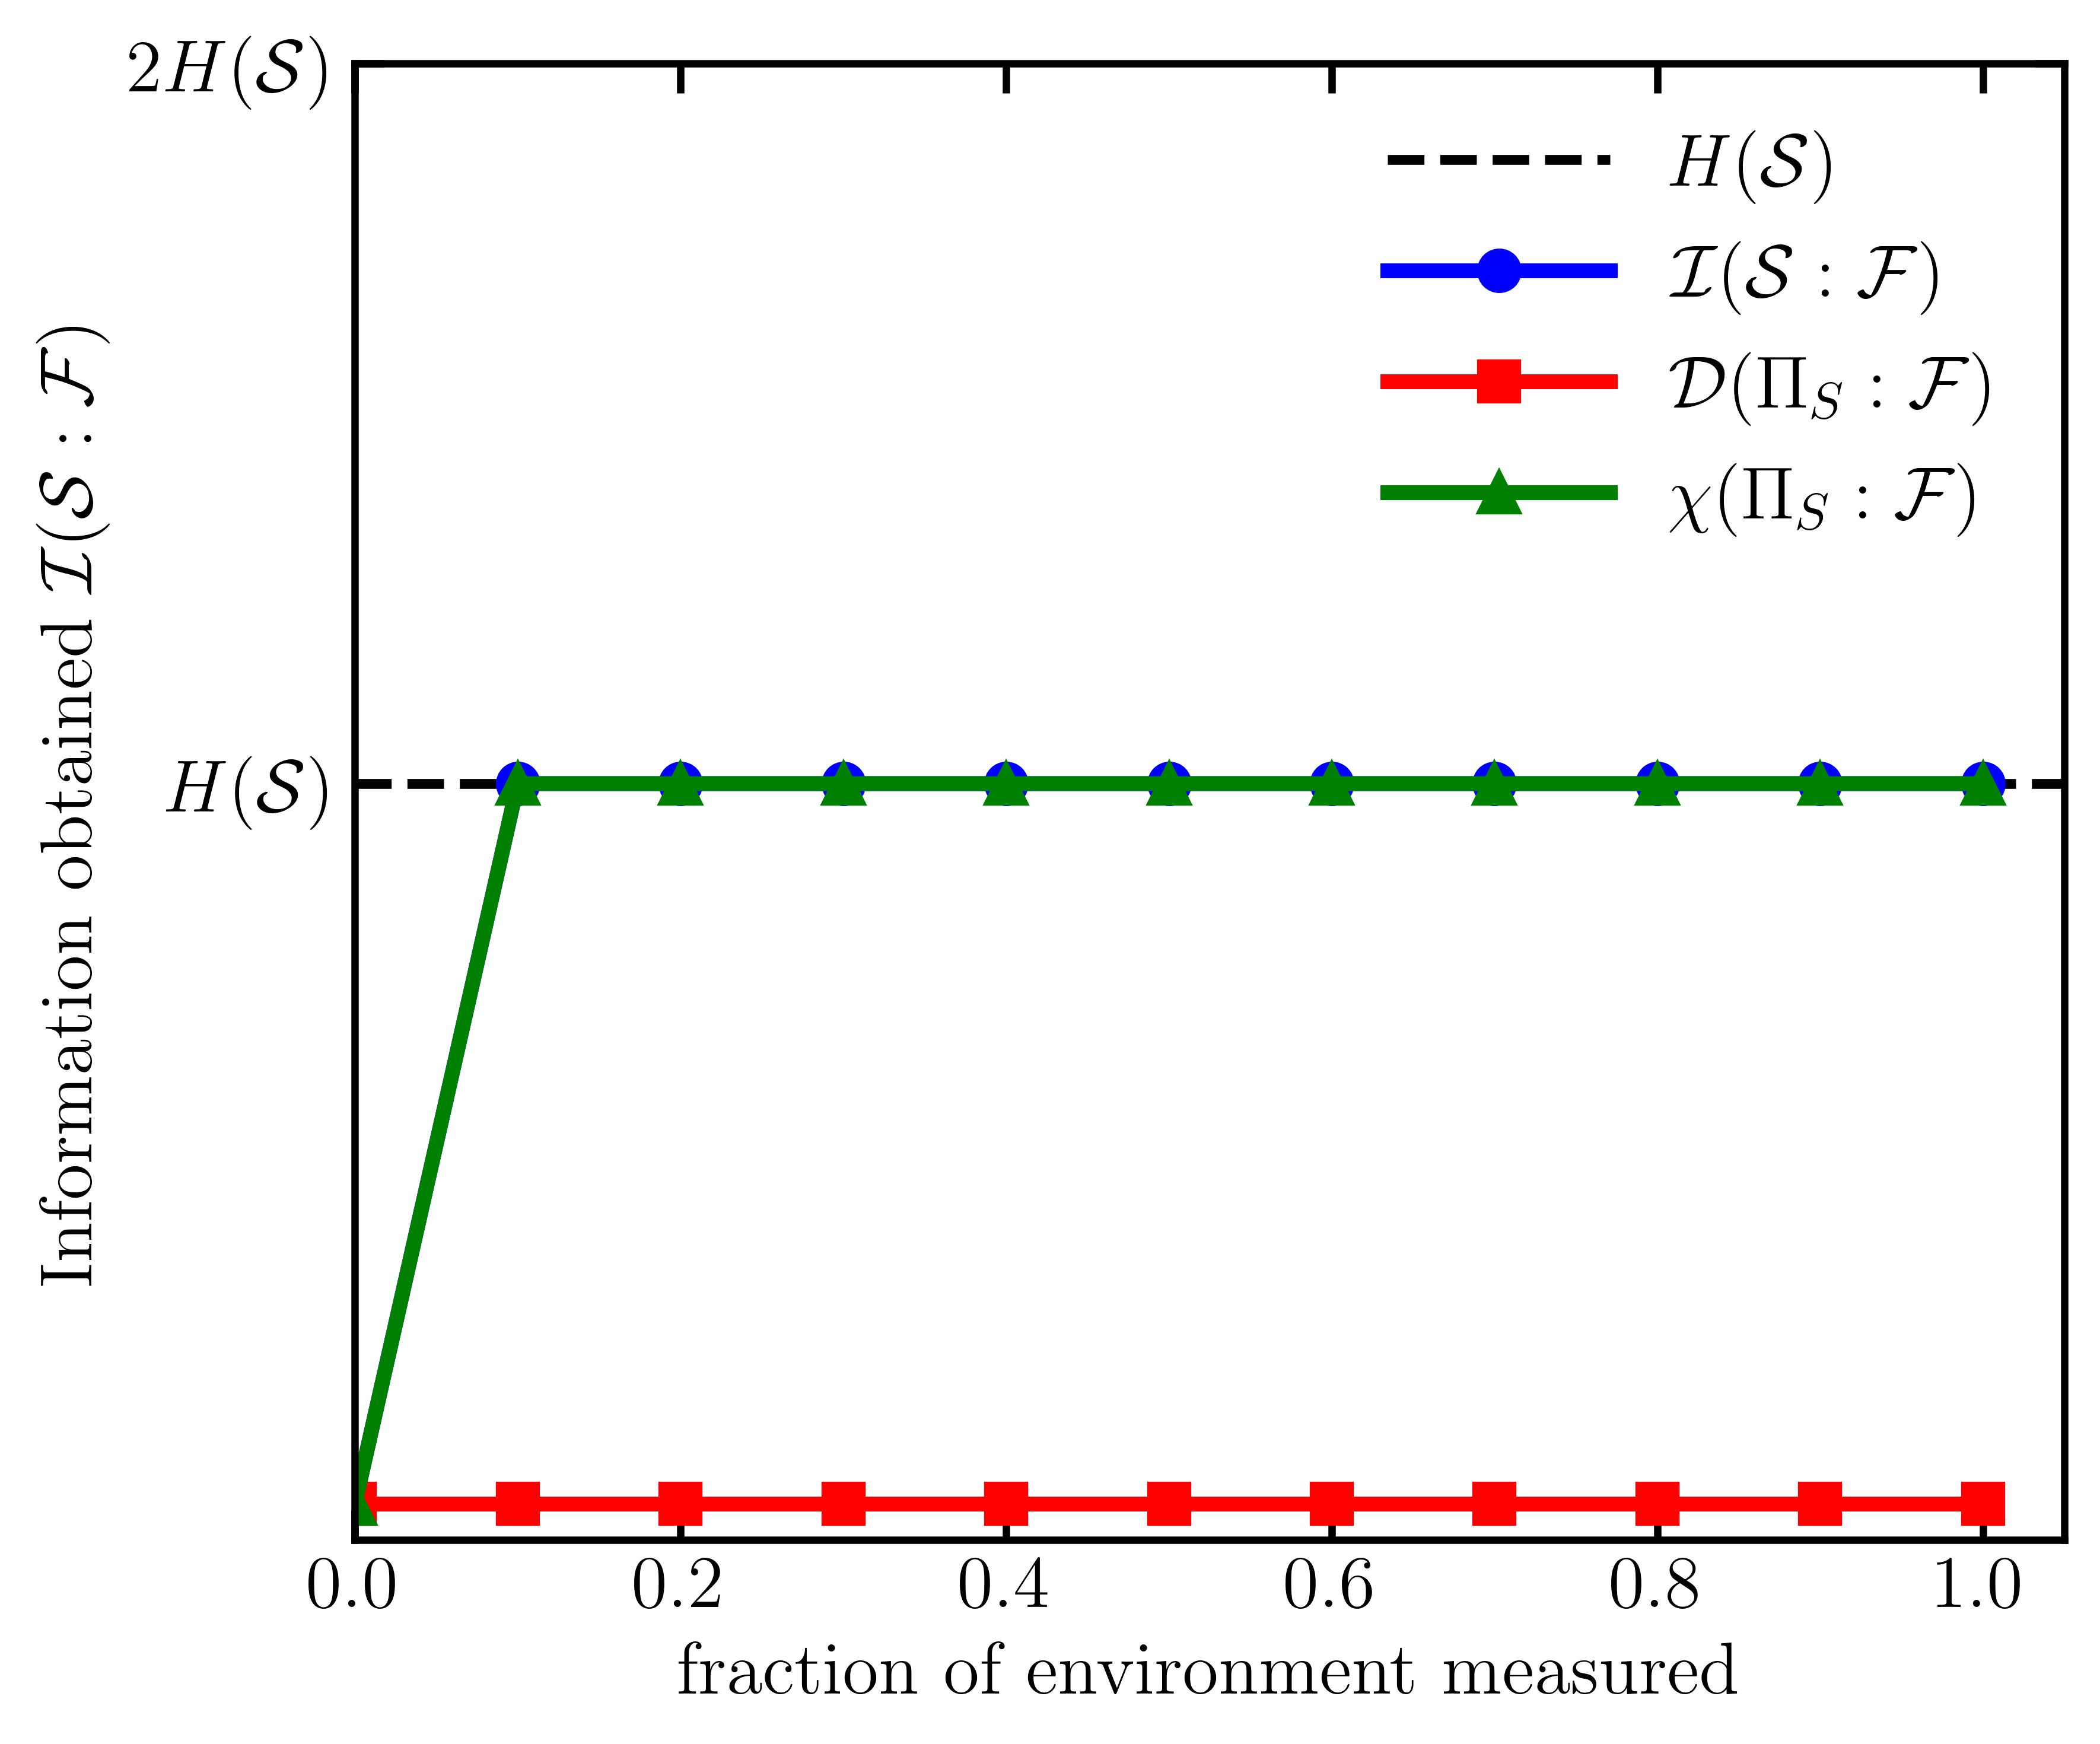

In [ ]:
# PLOT Wigner model - QMI & Holevo & Discord for theta = pi, phi_sys = pi/2, phi_env = 0

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# Working directory

with open("QMI_Holevo_Discord_Wigner.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

numQubits = 12
env_qubits = list(range(2, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1

fs_ext = np.concatenate([[0.0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")

plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment measured', fontsize=15)
plt.ylabel('Information obtained ' + r'$\mathcal{I}(\mathcal{S}:\mathcal{F})$', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()



plt.savefig(r"Figure\QMI_Holevo_Discord_Wigner.png", dpi=600, bbox_inches='tight')
plt.savefig(r"Figure\QMI_Holevo_Discord_Wigner.eps", dpi=600,
    transparent=False,  # Tắt transparency
    facecolor="white",  # Ép nền màu trắng đục
    edgecolor="none",
    pad_inches=0.02,
)

display(plt)


In [ ]:
# Zurek model - QMI & Holevo & Discord with random states
import os
import pickle
import numpy as np
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        qc.h(qb_sys)
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation: 
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        return self.VNE(S_State) + self.VNE(E_State) - self.VNE(SE_State)
   
    def HolevoBound(self, rho_SEf, rho_S):
        rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
        S_Ef = self.VNE(rho_Ef)
        
        sum_cond_entropy = 0
        d_Ef = rho_SEf.shape[0] // 2
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
            p_i = np.real(np.trace(proj_SEf @ rho_SEf))
            
            if p_i > 1e-12:
                rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                
        return S_Ef - sum_cond_entropy
    
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ==================== MAIN CONFIGURATION ====================
numQubits = 11  # q0: system, q1..q10: environment
env_qubits = list(range(1, numQubits))
n_env = len(env_qubits)
fractions = [k / n_env for k in range(1, n_env + 1)]
QI_calc = QuantumInformation()

# ------------------------------------------------------------
# 1. TÍNH CHO ZUREK MODEL (CỰC RÕ RÀNG / ĐƯỜNG ĐỎ)
# ------------------------------------------------------------
print("Đang tính cho Zurek Model...")
theta, phi = np.pi, 0
qc = QCircuit(theta, phi, numQubits)
rho_S_zurek = qc.get_reduced_dm([0])

zurek_QMI, zurek_Holevo, zurek_Discord = [], [], []

for k in range(1, n_env + 1):
    Ef = env_qubits[:k]
    rho_Ef = qc.get_reduced_dm(Ef)
    rho_SEf = qc.get_reduced_dm([0] + Ef)

    zurek_QMI.append(QI_calc.quantum_mutual_I(rho_S_zurek, rho_Ef, rho_SEf))
    zurek_Holevo.append(QI_calc.HolevoBound(rho_SEf, rho_S_zurek))
    zurek_Discord.append(QI_calc.quantum_discord(rho_SEf, rho_S_zurek))

# ------------------------------------------------------------
# 2. TÍNH CHO HAAR RANDOM STATE (LẤY TRUNG BÌNH MẪU / ĐƯỜNG XANH LÁ)
# ------------------------------------------------------------
print("Đang tính cho Haar Random State (20 mẫu)...")
num_samples = 20
haar_QMI_samples, haar_Holevo_samples, haar_Discord_samples = [], [], []

for sample_idx in range(num_samples):
    psi_haar = qi.random_statevector(2**numQubits)
    rho_SE_haar = DensityMatrix(psi_haar).data
    
    qmi_s, holevo_s, discord_s = [], [], []
    for k in range(1, n_env + 1):
        Ef = env_qubits[:k]
        trace_out = [i for i in range(numQubits) if i not in [0] + Ef]
        
        rho_S_haar = partial_trace(DensityMatrix(rho_SE_haar), env_qubits).data
        rho_Ef = partial_trace(DensityMatrix(rho_SE_haar), [i for i in range(numQubits) if i not in Ef]).data
        rho_SEf = partial_trace(DensityMatrix(rho_SE_haar), trace_out).data
        
        qmi_s.append(QI_calc.quantum_mutual_I(rho_S_haar, rho_Ef, rho_SEf))
        holevo_s.append(QI_calc.HolevoBound(rho_SEf, rho_S_haar))
        discord_s.append(QI_calc.quantum_discord(rho_SEf, rho_S_haar))
        
    haar_QMI_samples.append(qmi_s)
    haar_Holevo_samples.append(holevo_s)
    haar_Discord_samples.append(discord_s)

# Lấy trung bình cộng qua 20 mẫu Haar
haar_QMI = np.mean(haar_QMI_samples, axis=0)
haar_Holevo = np.mean(haar_Holevo_samples, axis=0)
haar_Discord = np.mean(haar_Discord_samples, axis=0)

# ------------------------------------------------------------
# 3. LƯU TỔNG CỘNG 6 ĐƯỜNG VÀO FILE .PKL
# ------------------------------------------------------------
data = {
    "fractions": fractions,
    # 3 đường Zurek Model
    "zurek_QMI": zurek_QMI,
    "zurek_Holevo": zurek_Holevo,
    "zurek_Discord": zurek_Discord,
    # 3 đường Haar Random State
    "haar_QMI": haar_QMI,
    "haar_Holevo": haar_Holevo,
    "haar_Discord": haar_Discord,
    # Object mạch để tham khảo
    "qcircuit_obj": qc.Circuit()
}

output_filename = "QMI_Holevo_Discord_Combined.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(data, f)

print("=" * 60)
print(f"Đã lưu thành công 6 đường dữ liệu vào: {os.path.join(os.getcwd(), output_filename)}")
print("=" * 60)

Đang tính cho Zurek Model...
Đang tính cho Haar Random State (20 mẫu)...
Đã lưu thành công 6 đường dữ liệu vào: d:\Quantum Darwinism Macbook project\Quantum-Darwinism\QMI_Holevo_Discord_Combined.pkl


<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

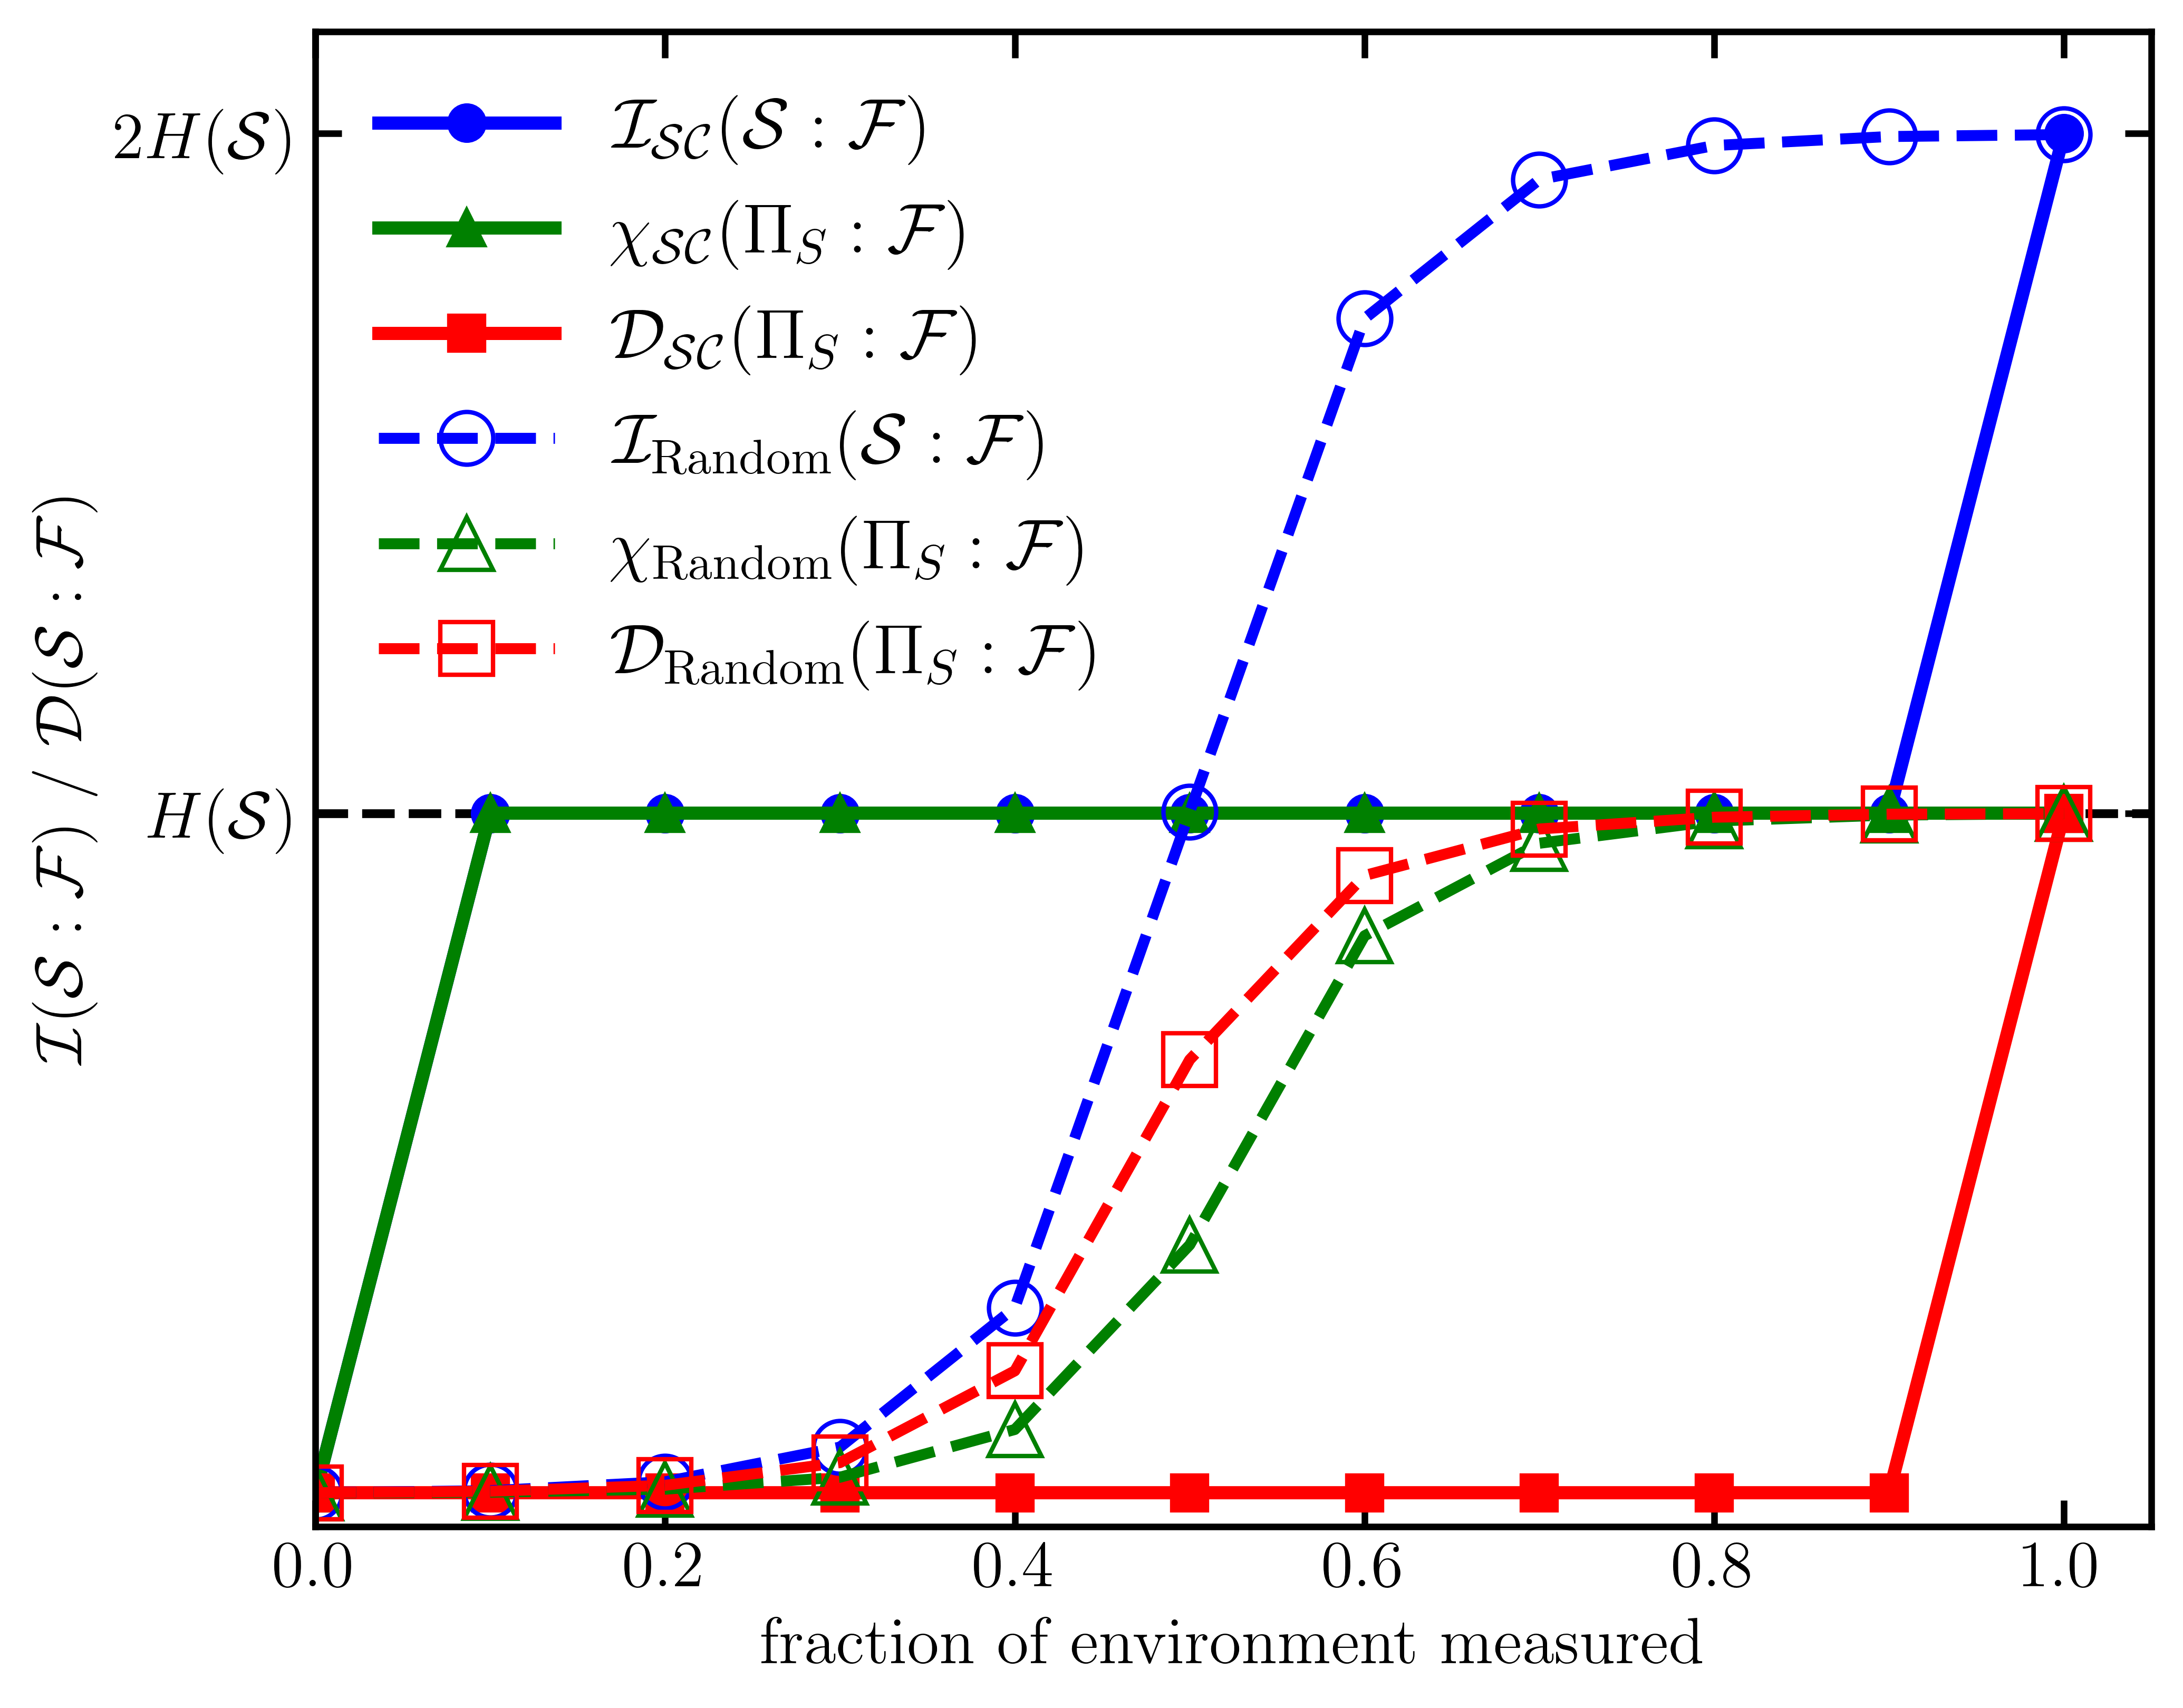

In [7]:
# PLOT Zurek model & Haar Random State - QMI & Holevo & Discord
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
from IPython.display import display

# Cấu hình đường dẫn LaTeX (nếu dùng trên macOS, nếu dùng Windows/Linux và có LaTeX thì giữ nguyên)
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Cấu hình Matplotlib LaTeX Style chuẩn bài báo
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# ==================== 1. NẠP DỮ LIỆU .PKL ====================
with open("QMI_Holevo_Discord_Combined.pkl", "rb") as f:
    data = pickle.load(f)

# Dữ liệu Zurek Model
zurek_qmi = data["zurek_QMI"]
zurek_holevo = data["zurek_Holevo"]
zurek_discord = data["zurek_Discord"]

# Dữ liệu Haar Random State
haar_qmi = data["haar_QMI"]
haar_holevo = data["haar_Holevo"]
haar_discord = data["haar_Discord"]

fractions = data["fractions"]  # Tỉ lệ từ 1/N đến 1.0

# ==================== 2. CHUẨN BỊ TRỤC VÀ ĐIỂM 0 ====================
plt.figure(figsize=(7, 5.5))

fs_ext = np.concatenate([[0.0], fractions])

# Mở rộng gốc (0.0) cho 6 đường
zurek_qmi_ext = np.concatenate([[0.0], zurek_qmi])
zurek_holevo_ext = np.concatenate([[0.0], zurek_holevo])
zurek_discord_ext = np.concatenate([[0.0], zurek_discord])

haar_qmi_ext = np.concatenate([[0.0], haar_qmi])
haar_holevo_ext = np.concatenate([[0.0], haar_holevo])
haar_discord_ext = np.concatenate([[0.0], haar_discord])

# Đường giới hạn H(S)
plt.axhline(1.0, color='black', linestyle='--', linewidth=2)

# ==================== 3. VẼ 6 ĐƯỜNG THEO BỘ MÀU CHUẨN ====================

# --- ZUREK MODEL (Nét liền - Solid Lines) ---
plt.plot(fs_ext, zurek_qmi_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}_{\mathcal{SC}}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, zurek_holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi_{\mathcal{SC}}(\Pi_S:\mathcal{F})$")

plt.plot(fs_ext, zurek_discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}_{\mathcal{SC}}(\Pi_S:\mathcal{F})$")

# --- RANDOM STATE (Nét đứt - Dashed Lines) ---
plt.plot(fs_ext, haar_qmi_ext, 'b--o', linewidth=2.5, markersize=12, markerfacecolor='none',
         label=r"$\mathcal{I}_{\mathrm{Random}}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, haar_holevo_ext, 'g--^', linewidth=2.5, markersize=12, markerfacecolor='none',
         label=r"$\chi_{\mathrm{Random}}(\Pi_S:\mathcal{F})$")

plt.plot(fs_ext, haar_discord_ext, 'r--s', linewidth=2.5, markersize=12, markerfacecolor='none',
         label=r"$\mathcal{D}_{\mathrm{Random}}(\Pi_S:\mathcal{F})$")


# ==================== 4. DINH DẠNG TỤC VÀ STYLE ====================
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize=15)
plt.xticks(fontsize=15)

plt.xlabel('fraction of environment measured', fontsize=15)
plt.ylabel('$\mathcal{I}(\mathcal{S}:\mathcal{F})$ / $\mathcal{D}(\mathcal{S}:\mathcal{F})$', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')

# Legend chia làm 2 cột để gọn gàng hơn khi có 6 đường
plt.legend(fontsize=16, frameon=False, loc='upper left', handlelength=2.5, ncol=1)

plt.grid(False)
plt.xlim(0, 1.05)
plt.ylim(-0.05, 2.15)
plt.tight_layout()

# ==================== 5. LƯU ẢNH ====================
os.makedirs("Figure", exist_ok=True)

plt.savefig(r"Figure\QMI_Holevo_Discord_6_Curves.png", dpi=600, bbox_inches='tight')
plt.savefig(
    r"Figure\QMI_Holevo_Discord_6_Curves.eps",
    format="eps",
    transparent=False,
    facecolor="white",
    edgecolor="none",
    pad_inches=0.02,
)

display(plt)

In [3]:
# Wigner model - QMI & Holevo & Discord with random states
import os
import pickle
import numpy as np
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate

class QCircuit:    
    def __init__(self, theta, phi_sys, phi_env, n):  
        self.theta = theta        # góc cho controlled-U3
        self.phi_sys = phi_sys    # góc quay Ry của hệ thống
        self.phi_env = phi_env    # góc cho controlled-U3
        self.n = n        

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System & Observer
        qc.ry(self.phi_sys, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        qc.barrier()
        
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi_env, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation: 
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        return self.VNE(S_State) + self.VNE(E_State) - self.VNE(SE_State)
   
    def HolevoBound(self, rho_SEf, rho_S):
        rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
        S_Ef = self.VNE(rho_Ef)
        
        sum_cond_entropy = 0
        d_Ef = rho_SEf.shape[0] // 2 
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
            p_i = np.real(np.trace(proj_SEf @ rho_SEf))
            
            if p_i > 1e-12:
                rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                
        return S_Ef - sum_cond_entropy
    
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ==================== CẤU HÌNH HỆ THỐNG ====================
numQubits = 12  # q0: System, q1: Observer (Apparatus), q2..q11: Environment (10 qubits)
env_qubits = list(range(2, numQubits))
n_env = len(env_qubits)
fractions = [k / n_env for k in range(1, n_env + 1)]
QI_calc = QuantumInformation()

# ------------------------------------------------------------
# 1. TÍNH CHO WIGNER MODEL (CỰC RÕ RÀNG / 3 ĐƯỜNG ZUREK-WIGNER)
# ------------------------------------------------------------
print("Đang tính toán cho Wigner Model...")
theta, phi_sys, phi_env = np.pi, np.pi / 2, 0
qc = QCircuit(theta, phi_sys, phi_env, numQubits)

# System S là qubit 0
rho_S_wigner = qc.get_reduced_dm([0])

wigner_QMI, wigner_Holevo, wigner_Discord = [], [], []

for k in range(1, n_env + 1):
    Ef = env_qubits[:k]
    # Observer (q1) tự động bị trace out khi chỉ giữ [Ef] và [0 + Ef]
    rho_Ef = qc.get_reduced_dm(Ef)
    rho_SEf = qc.get_reduced_dm([0] + Ef)

    wigner_QMI.append(QI_calc.quantum_mutual_I(rho_S_wigner, rho_Ef, rho_SEf))
    wigner_Holevo.append(QI_calc.HolevoBound(rho_SEf, rho_S_wigner))
    wigner_Discord.append(QI_calc.quantum_discord(rho_SEf, rho_S_wigner))

# ------------------------------------------------------------
# 2. TÍNH CHO HAAR RANDOM STATE TRÊN CẢ HỆ S + O + E (3 ĐƯỜNG RANDOM)
# ------------------------------------------------------------
print("Đang tính toán cho Haar Random State (20 mẫu)...")
num_samples = 20
haar_QMI_samples, haar_Holevo_samples, haar_Discord_samples = [], [], []

for sample_idx in range(num_samples):
    # Vector ngẫu nhiên cho toàn bộ không gian S (q0) + O (q1) + E (q2..q11)
    psi_haar = qi.random_statevector(2**numQubits)
    rho_SOE_haar = DensityMatrix(psi_haar).data
    
    qmi_s, holevo_s, discord_s = [], [], []
    for k in range(1, n_env + 1):
        Ef = env_qubits[:k]
        
        # Các qubit bị trace out bao gồm Observer (q1) và phần môi trường còn lại không thuộc Ef
        trace_out_S = [i for i in range(numQubits) if i != 0]
        trace_out_Ef = [i for i in range(numQubits) if i not in Ef]
        trace_out_SEf = [i for i in range(numQubits) if i not in [0] + Ef]
        
        rho_S_haar = partial_trace(DensityMatrix(rho_SOE_haar), trace_out_S).data
        rho_Ef = partial_trace(DensityMatrix(rho_SOE_haar), trace_out_Ef).data
        rho_SEf = partial_trace(DensityMatrix(rho_SOE_haar), trace_out_SEf).data
        
        qmi_s.append(QI_calc.quantum_mutual_I(rho_S_haar, rho_Ef, rho_SEf))
        holevo_s.append(QI_calc.HolevoBound(rho_SEf, rho_S_haar))
        discord_s.append(QI_calc.quantum_discord(rho_SEf, rho_S_haar))
        
    haar_QMI_samples.append(qmi_s)
    haar_Holevo_samples.append(holevo_s)
    haar_Discord_samples.append(discord_s)

# Lấy trung bình cộng qua các mẫu
haar_QMI = np.mean(haar_QMI_samples, axis=0)
haar_Holevo = np.mean(haar_Holevo_samples, axis=0)
haar_Discord = np.mean(haar_Discord_samples, axis=0)

# ------------------------------------------------------------
# 3. LƯU TỔNG CỘNG 6 ĐƯỜNG VÀO FILE .PKL
# ------------------------------------------------------------
data = {
    "fractions": fractions,
    # 3 đường Wigner Model
    "wigner_QMI": wigner_QMI,
    "wigner_Holevo": wigner_Holevo,
    "wigner_Discord": wigner_Discord,
    # 3 đường Haar Random State
    "haar_QMI": haar_QMI,
    "haar_Holevo": haar_Holevo,
    "haar_Discord": haar_Discord,
    "qcircuit_obj": qc.Circuit()
}

output_filename = "QMI_Holevo_Discord_Combined_Wigner.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(data, f)

print("=" * 60)
print(f"Đã lưu thành công 6 đường dữ liệu vào: {os.path.join(os.getcwd(), output_filename)}")
print("=" * 60)

Đang tính toán cho Wigner Model...
Đang tính toán cho Haar Random State (20 mẫu)...
Đã lưu thành công 6 đường dữ liệu vào: /home/dw/trandon/Quantum-Darwinism/QMI_Holevo_Discord_Combined_Wigner.pkl


<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

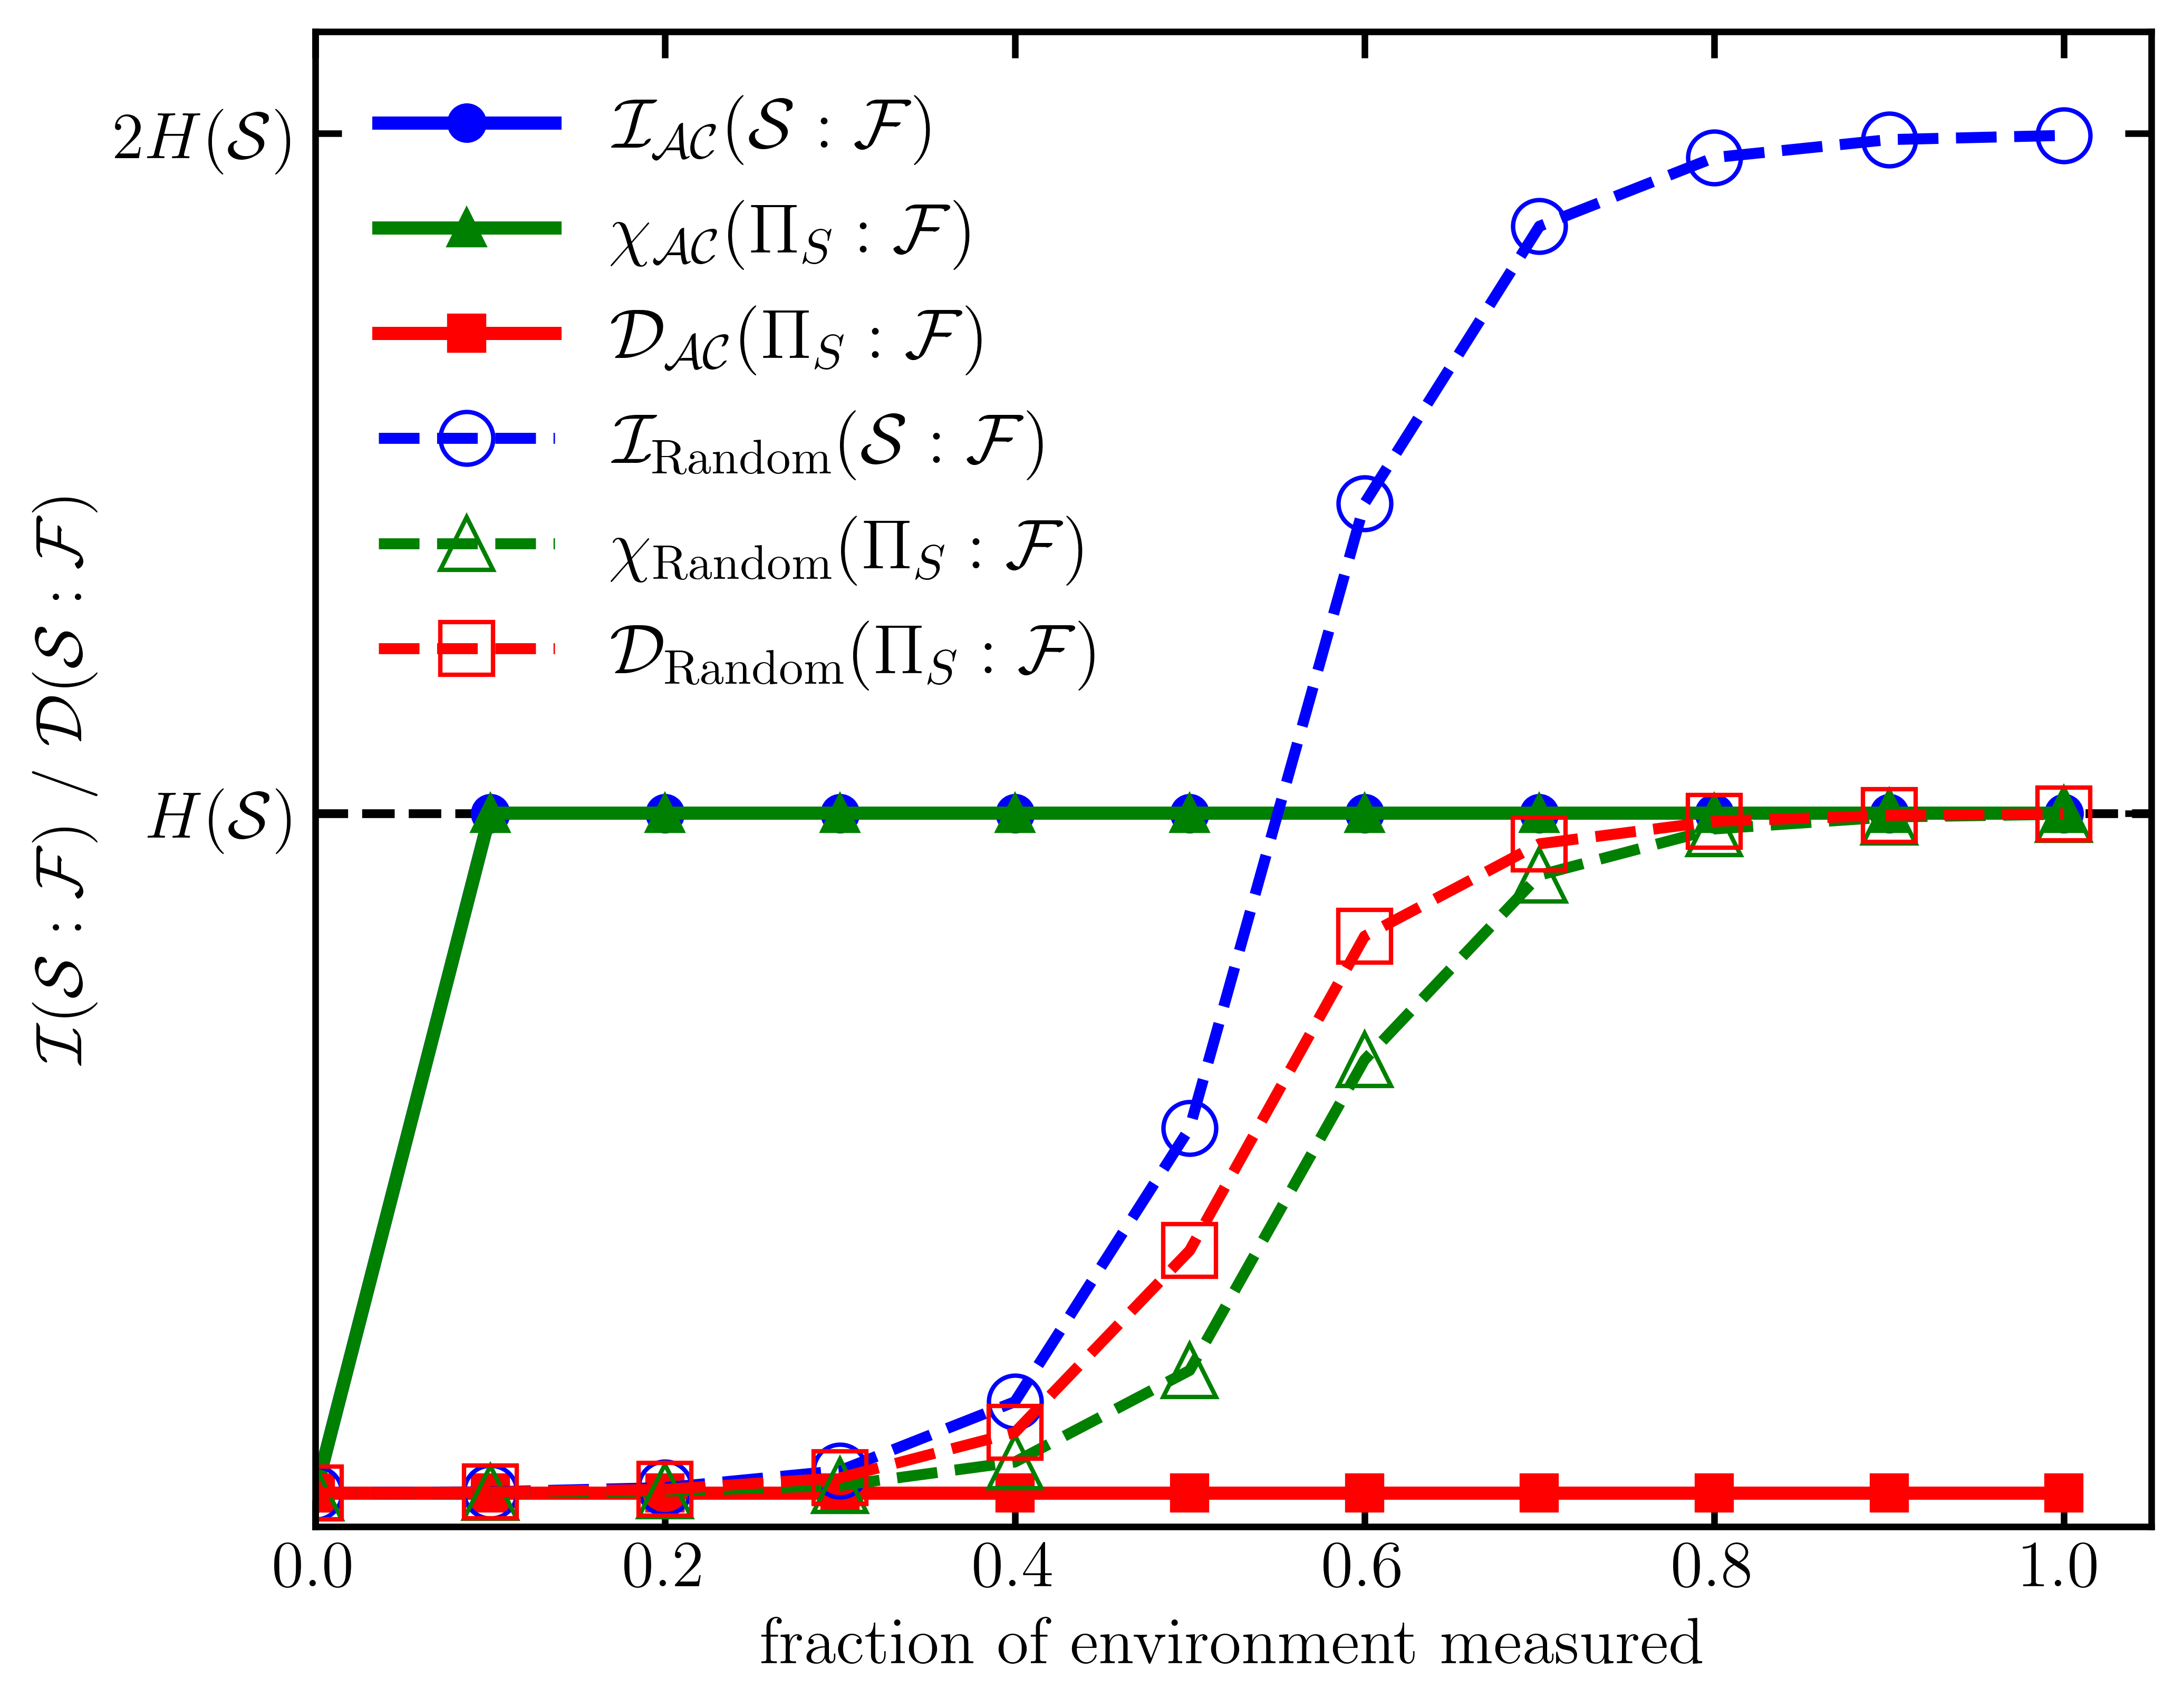

In [13]:
# PLOT Wigner model & Haar Random State - QMI & Holevo & Discord
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# Nạp file data Wigner
with open("QMI_Holevo_Discord_Combined_Wigner.pkl", "rb") as f:
    data = pickle.load(f)

wigner_qmi = data["wigner_QMI"]
wigner_holevo = data["wigner_Holevo"]
wigner_discord = data["wigner_Discord"]

haar_qmi = data["haar_QMI"]
haar_holevo = data["haar_Holevo"]
haar_discord = data["haar_Discord"]

fractions = data["fractions"]

plt.figure(figsize=(7, 5.5))

fs_ext = np.concatenate([[0.0], fractions])

# Mở rộng điểm (0.0)
wigner_qmi_ext = np.concatenate([[0.0], wigner_qmi])
wigner_holevo_ext = np.concatenate([[0.0], wigner_holevo])
wigner_discord_ext = np.concatenate([[0.0], wigner_discord])

haar_qmi_ext = np.concatenate([[0.0], haar_qmi])
haar_holevo_ext = np.concatenate([[0.0], haar_holevo])
haar_discord_ext = np.concatenate([[0.0], haar_discord])

# Đường giới hạn H(S)
plt.axhline(1.0, color='black', linestyle='--', linewidth=2)

# --- WIGNER MODEL (Nét liền) ---
plt.plot(fs_ext, wigner_qmi_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}_{\mathcal{AC}}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, wigner_holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi_{\mathcal{AC}}(\Pi_S:\mathcal{F})$")

plt.plot(fs_ext, wigner_discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}_{\mathcal{AC}}(\Pi_S:\mathcal{F})$")
# --- RANDOM STATE (Nét đứt - Dashed Lines) ---
plt.plot(fs_ext, haar_qmi_ext, 'b--o', linewidth=2.5, markersize=12, markerfacecolor='none',
         label=r"$\mathcal{I}_{\mathrm{Random}}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, haar_holevo_ext, 'g--^', linewidth=2.5, markersize=12, markerfacecolor='none',
         label=r"$\chi_{\mathrm{Random}}(\Pi_S:\mathcal{F})$")

plt.plot(fs_ext, haar_discord_ext, 'r--s', linewidth=2.5, markersize=12, markerfacecolor='none',
         label=r"$\mathcal{D}_{\mathrm{Random}}(\Pi_S:\mathcal{F})$")

# Format khung viền
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize=15)
plt.xticks(fontsize=15)

plt.xlabel('fraction of environment measured', fontsize=15)
plt.ylabel('$\mathcal{I}(\mathcal{S}:\mathcal{F})$ / $\mathcal{D}(\mathcal{S}:\mathcal{F})$', fontsize=15)
plt.legend(fontsize=16, frameon=False, loc='upper left', handlelength=2.5, ncol=1)

plt.grid(False)
plt.xlim(0, 1.05)
plt.ylim(-0.05, 2.15)
plt.tight_layout()

os.makedirs("Figure", exist_ok=True)

plt.savefig(r"Figure\QMI_Holevo_Discord_Wigner_6_Curves.png", dpi=600, bbox_inches='tight')
plt.savefig(
    r"Figure\QMI_Holevo_Discord_Wigner_6_Curves.eps",
    format="eps",
    transparent=False,
    facecolor="white",
    edgecolor="none",
    pad_inches=0.02,
)

display(plt)

In [ ]:
# Zurek model - QMI & Holevo & Discord with theta = 0.3, 0.6, 1.0
import os
import pickle
import numpy as np
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        
        # System prepare |+> using Hadamard gate 
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation: 
    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
   
    # Holevo Bound χ(S:F) = S(E) - Σ p_i S(E|i) 
    def HolevoBound(self, rho_SEf, rho_S):
        rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
        S_Ef = self.VNE(rho_Ef)
        
        sum_cond_entropy = 0
        d_Ef = rho_SEf.shape[0] // 2 
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
            p_i = np.real(np.trace(proj_SEf @ rho_SEf))
            
            if p_i > 1e-12:
                rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                
        return S_Ef - sum_cond_entropy
    
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) 
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 11  # q0 system, q1..q10 environment
phi = 0
theta_list = [0.3 * np.pi, 0.6 * np.pi, 1.0 * np.pi]

env_qubits = list(range(1, numQubits))
n_env = len(env_qubits)
FS = np.array([k / n_env for k in range(1, n_env + 1)])

QI_calc = QuantumInformation()

# Ma trận lưu trữ kết quả cho các góc theta
QMI_matrix = []
Holevo_matrix = []
Discord_matrix = []

print("Đang tính toán Zurek model cho các góc theta:", theta_list)

for theta in theta_list:
    print(f"--> Tính toán cho theta = {theta} rad...")
    qc = QCircuit(theta, phi, numQubits)
    rho_S = qc.get_reduced_dm([0])
    
    qmi_row, holevo_row, discord_row = [], [], []
    
    for k in range(1, n_env + 1):
        Ef = env_qubits[:k]
        rho_Ef  = qc.get_reduced_dm(Ef)
        rho_SEf = qc.get_reduced_dm([0] + Ef)

        # QMI
        QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
        qmi_row.append(QMI_S_Ef)
        
        # Holevo
        Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
        holevo_row.append(Holevo_Ef)
        
        # Quantum Discord
        Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
        discord_row.append(Discord_S_Ef)
        
    QMI_matrix.append(qmi_row)
    Holevo_matrix.append(holevo_row)
    Discord_matrix.append(discord_row)

# ===================== SAVING ====================
data = {
    "FS": FS,
    "Theta_list": theta_list,          # Lưu theta_list dưới key Phi_sys để đồng bộ cấu trúc đọc file
    "QMI_matrix": QMI_matrix,
    "Holevo_matrix": Holevo_matrix,
    "Discord_matrix": Discord_matrix
}

# Lưu file chuẩn hóa theo cấu trúc 3D
output_filename = "QMI_Zurek_0.3_0.6_1.0.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(data, f)




Đang tính toán Zurek model cho các góc theta: [0.9424777960769379, 1.8849555921538759, 3.141592653589793]
--> Tính toán cho theta = 0.9424777960769379 rad...
--> Tính toán cho theta = 1.8849555921538759 rad...
--> Tính toán cho theta = 3.141592653589793 rad...


In [ ]:
# Wigner model - QMI & Holevo & Discord with theta = 0.3, 0.6, 1.0
import os
import pickle
import numpy as np
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate

class QCircuit:    
    def __init__(self, theta, phi_sys, phi_env, n):  
        self.theta = theta        # góc cho controlled-U3
        self.phi_sys = phi_sys    # góc quay Ry của hệ thống
        self.phi_env = phi_env    # góc cho controlled-U3
        self.n = n        

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System 
        qc.ry(self.phi_sys, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        qc.barrier()
        
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi_env, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation: 
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
   
    def HolevoBound(self, rho_SEf, rho_S):
        rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
        S_Ef = self.VNE(rho_Ef)
        
        sum_cond_entropy = 0
        d_Ef = rho_SEf.shape[0] // 2 
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
            p_i = np.real(np.trace(proj_SEf @ rho_SEf))
            
            if p_i > 1e-12:
                rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                
        return S_Ef - sum_cond_entropy
    
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        
        for proj_S in [proj_0, proj_1]:
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q10 environment
phi_sys = np.pi / 2
phi_env = 0
theta_list = [0.3 * np.pi, 0.6 * np.pi, 1.0 * np.pi]

env_qubits = list(range(2, numQubits))
n_env = len(env_qubits)
FS = np.array([k / n_env for k in range(1, n_env + 1)])

QI_calc = QuantumInformation()

QMI_matrix = []
Holevo_matrix = []
Discord_matrix = []

for theta in theta_list:
    qc = QCircuit(theta, phi_sys, phi_env, numQubits)
    rho_S = qc.get_reduced_dm([0])
    
    qmi_row, holevo_row, discord_row = [], [], []
    
    for k in range(1, n_env + 1):
        Ef = env_qubits[:k]
        rho_Ef  = qc.get_reduced_dm(Ef)
        rho_SEf = qc.get_reduced_dm([0] + Ef)

        qmi_row.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
        holevo_row.append(QI_calc.HolevoBound(rho_SEf, rho_S))
        discord_row.append(QI_calc.quantum_discord(rho_SEf, rho_S))
        
    QMI_matrix.append(qmi_row)
    Holevo_matrix.append(holevo_row)
    Discord_matrix.append(discord_row)

# ===================== SAVING ====================
data = {
    "FS": FS,
    "Theta_list": theta_list,
    "Phi_sys": phi_sys,
    "QMI_matrix": QMI_matrix,
    "Holevo_matrix": Holevo_matrix,
    "Discord_matrix": Discord_matrix
}


# Lưu thêm tên file riêng cho góc theta 0.3, 0.6, 1.0
with open("QMI_Wigner_0.3_0.6_1.0.pkl", "wb") as f:
    pickle.dump(data, f)

<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

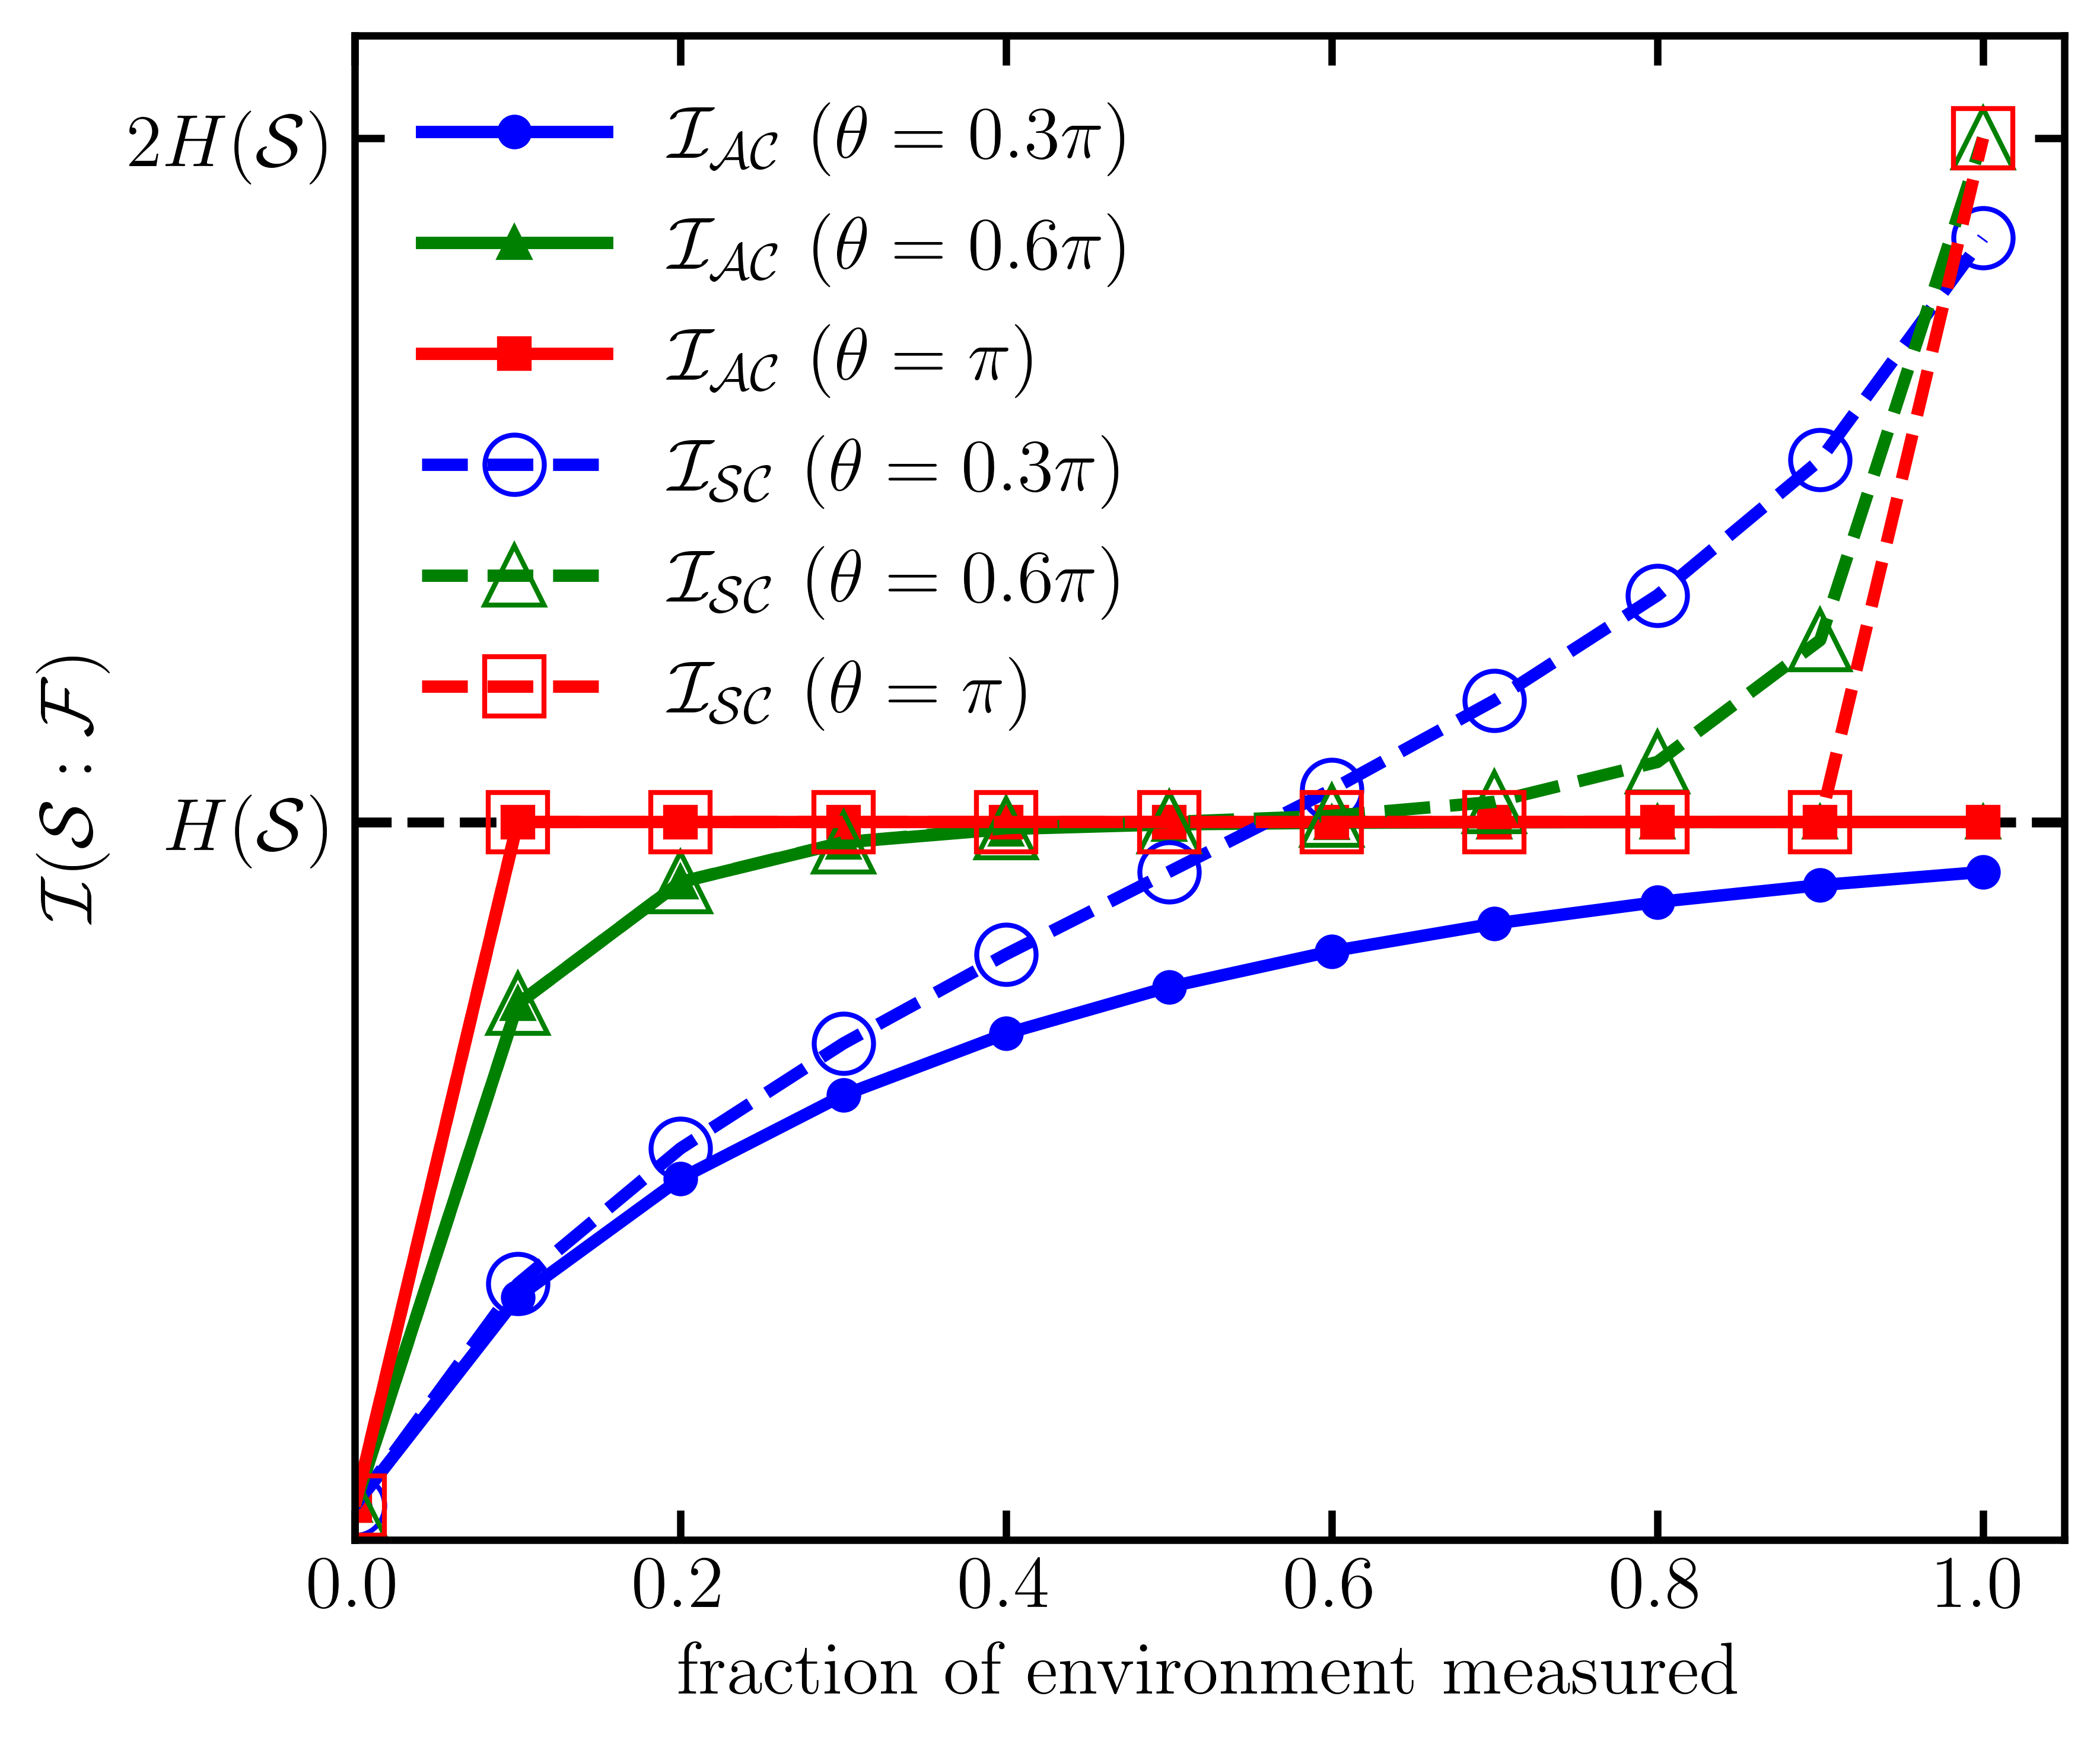

In [8]:
# Zurek model vs Wigner model - QMI & Holevo & Discord with theta = 0.3, 0.6, 1.0
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

# Cấu hình LaTeX
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# ==================== 1. ĐỌC DỮ LIỆU TỪ FILE .PKL ====================
with open("QMI_Zurek_0.3_0.6_1.0.pkl", "rb") as f:
    zurek_data = pickle.load(f)

with open("QMI_Wigner_0.3_0.6_1.0.pkl", "rb") as f:
    wigner_data = pickle.load(f)

FS_zurek = np.array(zurek_data["FS"]).flatten()
FS_wigner = np.array(wigner_data["FS"]).flatten()

FS_zurek_norm = FS_zurek / 100.0 if np.max(FS_zurek) > 1.0 else FS_zurek
FS_wigner_norm = FS_wigner / 100.0 if np.max(FS_wigner) > 1.0 else FS_wigner

QMI_zurek_matrix = np.array(zurek_data["QMI_matrix"])
QMI_wigner_matrix = np.array(wigner_data["QMI_matrix"])

# Danh sách nhãn góc theta dạng 0,3\pi; 0,6\pi; \pi
theta_labels = [r"0{.}3\pi", r"0{.}6\pi", r"\pi"]

# ==================== 2. VẼ ĐỒ THỊ ====================
plt.figure(figsize=(6, 5))

# Đường giới hạn H(S)
plt.axhline(1.0, color='black', linestyle='--', linewidth=2)

configs = [
    (0, 'b', 'o'),  # theta = 0,3 pi
    (1, 'g', '^'),  # theta = 0,6 pi
    (2, 'r', 's')   # theta = 1,0 pi
]

# --- A. WIGNER MODEL (I_AC - NÉT LIỀN) ---
for idx, color, marker in configs:
    th_label = theta_labels[idx]
    qmi_curve = QMI_wigner_matrix[idx, :]
    
    fs_ext = np.concatenate([[0.0], FS_wigner_norm])
    qmi_ext = np.concatenate([[0.0], qmi_curve])
    
    plt.plot(
        fs_ext, qmi_ext, 
        f"{color}-{marker}", 
        linewidth=2.5, 
        markersize=6, 
        label=rf"$\mathcal{{I}}_{{\mathcal{{A}}\mathcal{{C}}}}$ ($\theta = {th_label}$)"
    )

# --- B. ZUREK MODEL (I_SC - NÉT ĐỨT) ---
for idx, color, marker in configs:
    th_label = theta_labels[idx]
    qmi_curve = QMI_zurek_matrix[idx, :]
    
    fs_ext = np.concatenate([[0.0], FS_zurek_norm])
    qmi_ext = np.concatenate([[0.0], qmi_curve])
    
    plt.plot(
        fs_ext, qmi_ext, 
        f"{color}--{marker}", 
        linewidth=2.5, 
        markersize=12, 
        markerfacecolor='none', 
        label=rf"$\mathcal{{I}}_{{\mathcal{{S}}\mathcal{{C}}}}$ ($\theta = {th_label}$)"
    )

# ==================== 3. ĐỊNH DẠNG KHUNG VÀ TRỤC ====================
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize=15)
plt.xticks(fontsize=15)

plt.xlabel('fraction of environment measured', fontsize=15)
plt.ylabel(r'$\mathcal{I}(\mathcal{S}:\mathcal{F})$', fontsize=15)

# Đặt Legend nằm bên phải đồ thị
plt.legend(
    fontsize=15, 
    frameon=False, 
    loc='best', 
    ncol=1, 
    handlelength=2.5
)

plt.grid(False)
plt.xlim(0, 1.05)
plt.ylim(-0.05, 2.15)
plt.tight_layout()

# Save ảnh
os.makedirs("Figure", exist_ok=True)
plt.savefig(r"Figure\QMI_Zurek_vs_Wigner_theta.png", dpi=600, bbox_inches='tight')

display(plt)

<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

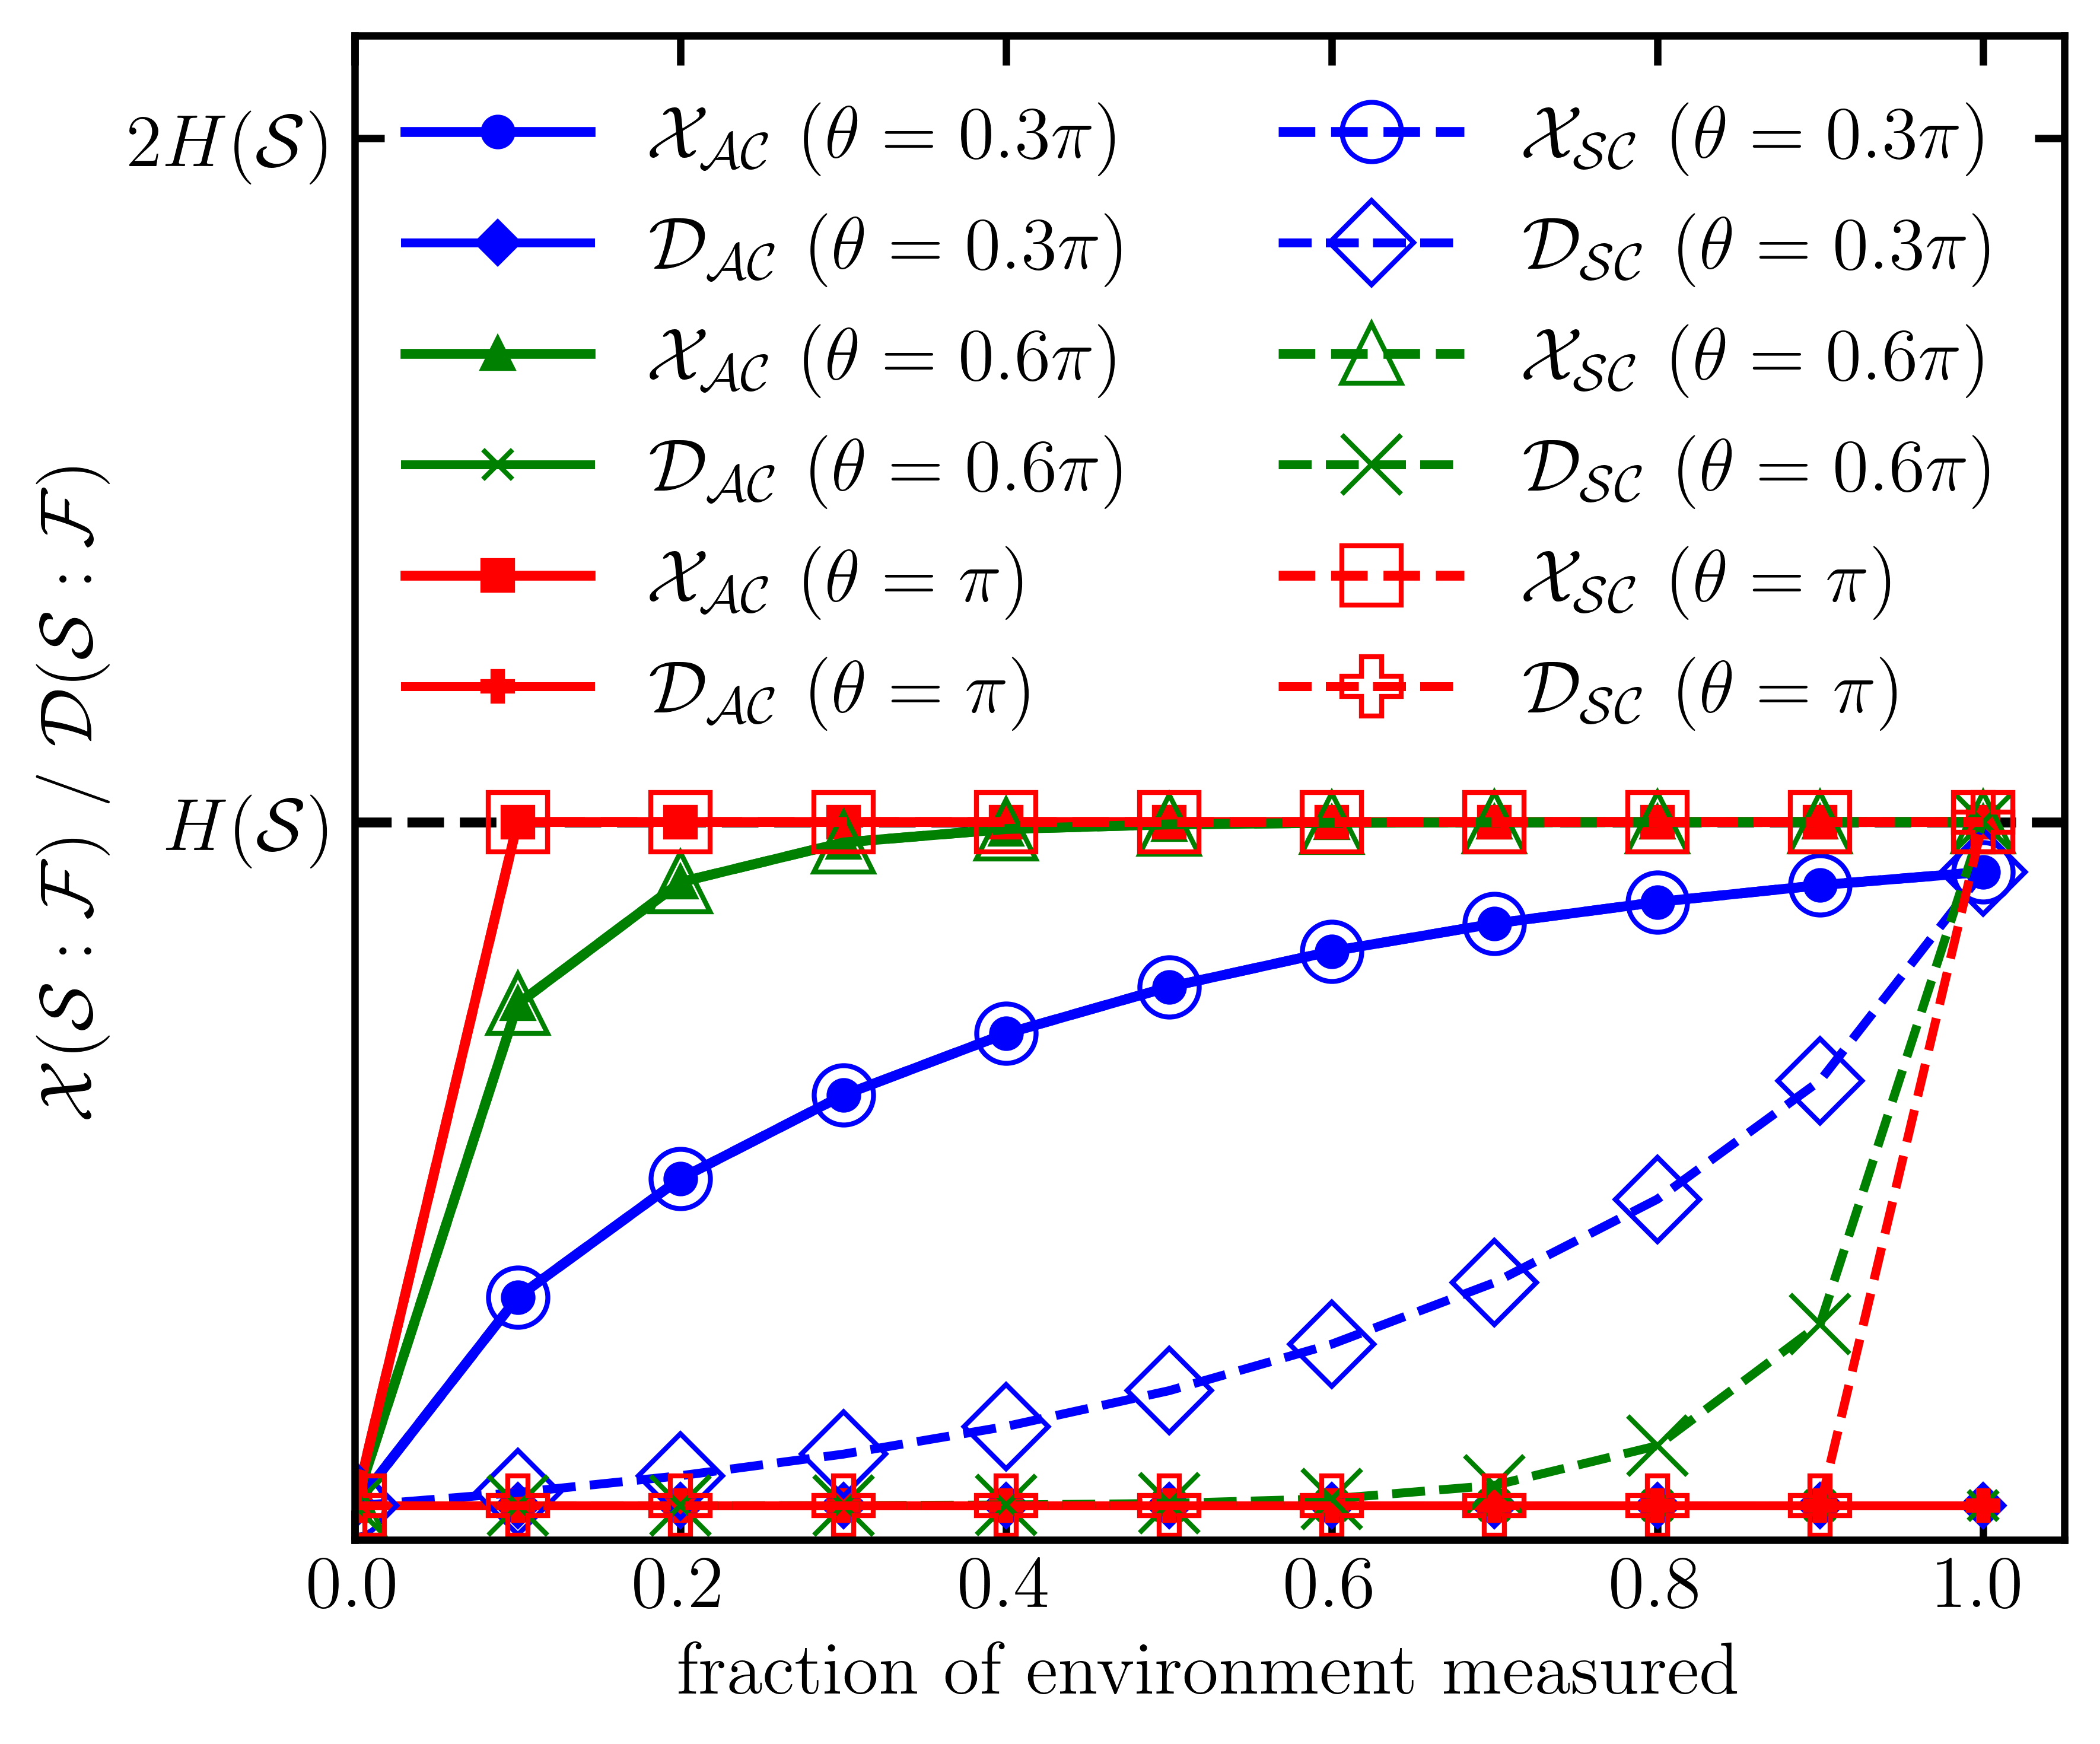

In [6]:
# PLOT Zurek model vs Wigner model - Holevo (X) and Discord (D) Comparison
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

# Cấu hình LaTeX
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# ==================== 1. NẠP DỮ LIỆU TỪ FILE .PKL ====================
with open("QMI_Zurek_0.3_0.6_1.0.pkl", "rb") as f:
    zurek_data = pickle.load(f)

with open("QMI_Wigner_0.3_0.6_1.0.pkl", "rb") as f:
    wigner_data = pickle.load(f)

FS_zurek = np.array(zurek_data["FS"]).flatten()
FS_wigner = np.array(wigner_data["FS"]).flatten()

FS_zurek_norm = FS_zurek / 100.0 if np.max(FS_zurek) > 1.0 else FS_zurek
FS_wigner_norm = FS_wigner / 100.0 if np.max(FS_wigner) > 1.0 else FS_wigner

# Ma trận Holevo (X) và Discord (D)
QMI_zurek_matrix = np.array(zurek_data["Holevo_matrix"])       # Holevo matrix
Discord_zurek_matrix = np.array(zurek_data["Discord_matrix"])

QMI_wigner_matrix = np.array(wigner_data["Holevo_matrix"])     # Holevo matrix
Discord_wigner_matrix = np.array(wigner_data["Discord_matrix"])

# Danh sách nhãn góc theta dạng số thực dùng dấu chấm (0.3pi, 0.6pi, pi)
theta_labels = [r"0.3\pi", r"0.6\pi", r"\pi"]

# ==================== 2. VẼ ĐỒ THỊ CHUNG HOLEVO (X) VÀ DISCORD (D) ====================
plt.figure(figsize=(6, 5))

# Đường giới hạn H(S)
plt.axhline(1.0, color='black', linestyle='--', linewidth=2)

# Cấu hình màu sắc và marker cho các góc theta
colors = ['b', 'g', 'r']  # theta = 0.3 (blue), 0.6 (green), 1.0 (red)
m_holevo = ['o', '^', 's'] # Marker cho Holevo (X)
m_dis = ['D', 'x', 'P']    # Marker cho Discord (D)

# --- A. WIGNER MODEL (NÉT LIỀN - SOLID) ---
for idx, color in enumerate(colors):
    th_label = theta_labels[idx]
    fs_w_ext = np.concatenate([[0.0], FS_wigner_norm])
    
    # Holevo Wigner (X_AC)
    holevo_ext = np.concatenate([[0.0], QMI_wigner_matrix[idx, :]])
    plt.plot(
        fs_w_ext, holevo_ext, 
        f"{color}-{m_holevo[idx]}", 
        linewidth=2, 
        markersize=6,
        label=rf"$\mathcal{{X}}_{{\mathcal{{A}}\mathcal{{C}}}}$ ($\theta = {th_label}$)"
    )
    
    # Discord Wigner (D_AC)
    dis_ext = np.concatenate([[0.0], Discord_wigner_matrix[idx, :]])
    plt.plot(
        fs_w_ext, dis_ext, 
        f"{color}-{m_dis[idx]}", 
        linewidth=1.8, 
        markersize=6,
        label=rf"$\mathcal{{D}}_{{\mathcal{{A}}\mathcal{{C}}}}$ ($\theta = {th_label}$)"
    )

# --- B. ZUREK MODEL (NÉT ĐỨT - DASHED) ---
for idx, color in enumerate(colors):
    th_label = theta_labels[idx]
    fs_z_ext = np.concatenate([[0.0], FS_zurek_norm])
    
    # Holevo Zurek (X_SC)
    holevo_ext = np.concatenate([[0.0], QMI_zurek_matrix[idx, :]])
    plt.plot(
        fs_z_ext, holevo_ext, 
        f"{color}--{m_holevo[idx]}", 
        linewidth=2, 
        markersize=12, 
        markerfacecolor='none',
        label=rf"$\mathcal{{X}}_{{\mathcal{{S}}\mathcal{{C}}}}$ ($\theta = {th_label}$)"
    )
    
    # Discord Zurek (D_SC)
    dis_ext = np.concatenate([[0.0], Discord_zurek_matrix[idx, :]])
    plt.plot(
        fs_z_ext, dis_ext, 
        f"{color}--{m_dis[idx]}", 
        linewidth=1.8, 
        markersize=12, 
        markerfacecolor='none',
        label=rf"$\mathcal{{D}}_{{\mathcal{{S}}\mathcal{{C}}}}$ ($\theta = {th_label}$)"
    )

# ==================== 3. ĐỊNH DẠNG KHUNG VÀ TRỤC ====================
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize=15)
plt.xticks(fontsize=15)

plt.xlabel('fraction of environment measured', fontsize=15)
plt.ylabel(r'$\mathcal{X}(\mathcal{S}:\mathcal{F})$ / $\mathcal{D}(\mathcal{S}:\mathcal{F})$', fontsize=15)

# Bố trí Legend tự động tìm vị trí thích hợp nhất (loc='best')
plt.legend(
    fontsize=15, 
    frameon=False, 
    loc='best', 
    ncol=2, 
    handlelength=2.5
)

plt.grid(False)
plt.xlim(0, 1.05)
plt.ylim(-0.05, 2.15)
plt.tight_layout()

# Save ảnh
os.makedirs("Figure", exist_ok=True)
plt.savefig(r"Figure\Holevo_and_Discord_Zurek_vs_Wigner_theta.png", dpi=600, bbox_inches='tight')

display(plt)

<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

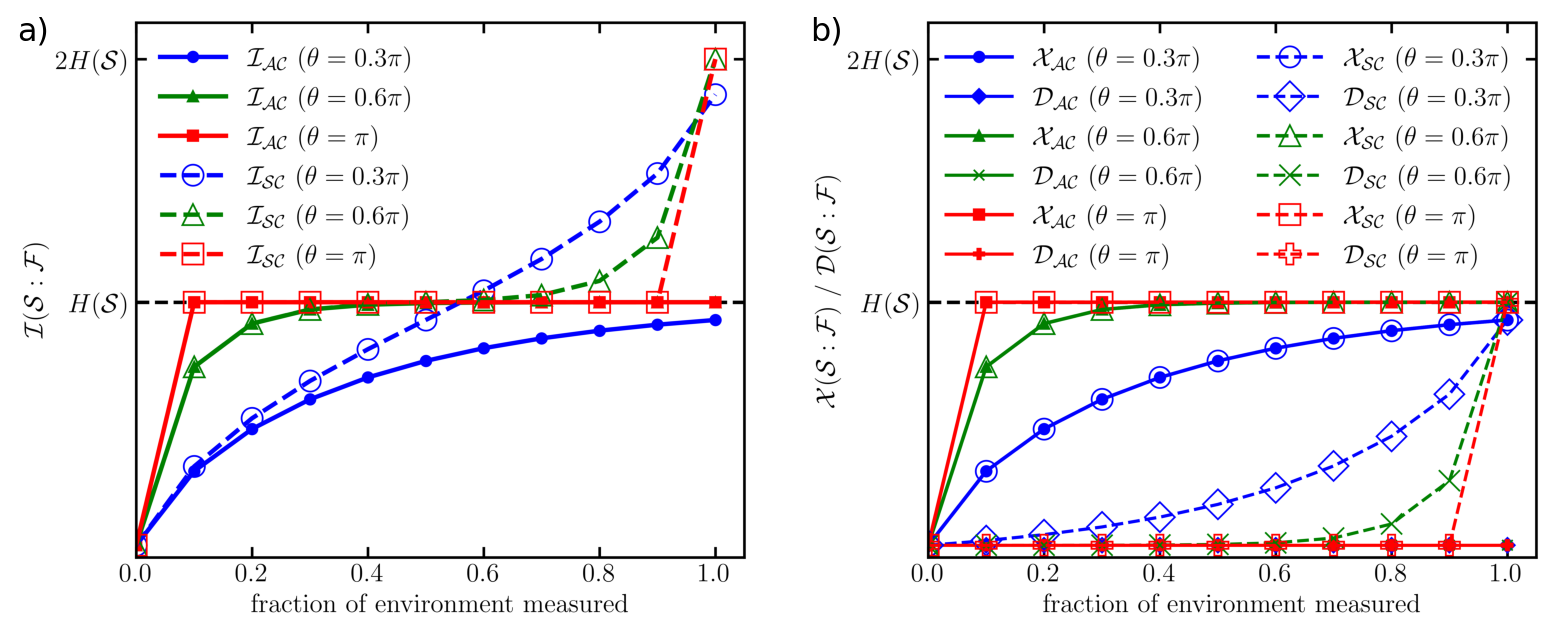

In [1]:
# PLOT Zurek model vs Wigner model - Panel Comparison
import os
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

# ==================== 1. ĐƯỜNG DẪN 2 TỆP ẢNH ĐÃ LƯU ====================
img_qmi_path = r"Figure\QMI_Zurek_vs_Wigner_theta.png"
img_xd_path = r"Figure\Holevo_and_Discord_Zurek_vs_Wigner_theta.png"

# Đọc ảnh vào bộ nhớ
img_qmi = mpimg.imread(img_qmi_path)
img_xd = mpimg.imread(img_xd_path)

# ==================== 2. GHÉP THÀNH PANEL VỚI NHÃN a) VÀ b) ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# --- SUBPLOT TRÁI (a) ---
ax1.imshow(img_qmi)
ax1.axis('off')
# Thêm nhãn a) ở góc trên bên trái
ax1.text(0.01, 0.99, r'a)', transform=ax1.transAxes, 
         fontsize=23, va='top', ha='left')

# --- SUBPLOT PHẢI (b) ---
ax2.imshow(img_xd)
ax2.axis('off')
# Thêm nhãn b) ở góc trên bên trái
ax2.text(0.01, 0.99, r'b)', transform=ax2.transAxes, 
         fontsize=23, va='top', ha='left')

plt.tight_layout()

# ==================== 3. LƯU VÀ HIỂN THỊ PANEL MỚI ====================


plt.savefig(r"Figure\Zurek_Wigner_comparision.png", dpi=600, bbox_inches='tight')
plt.savefig(r"Figure\Zurek_Wigner_comparision.eps", bbox_inches='tight')
display(plt)

<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

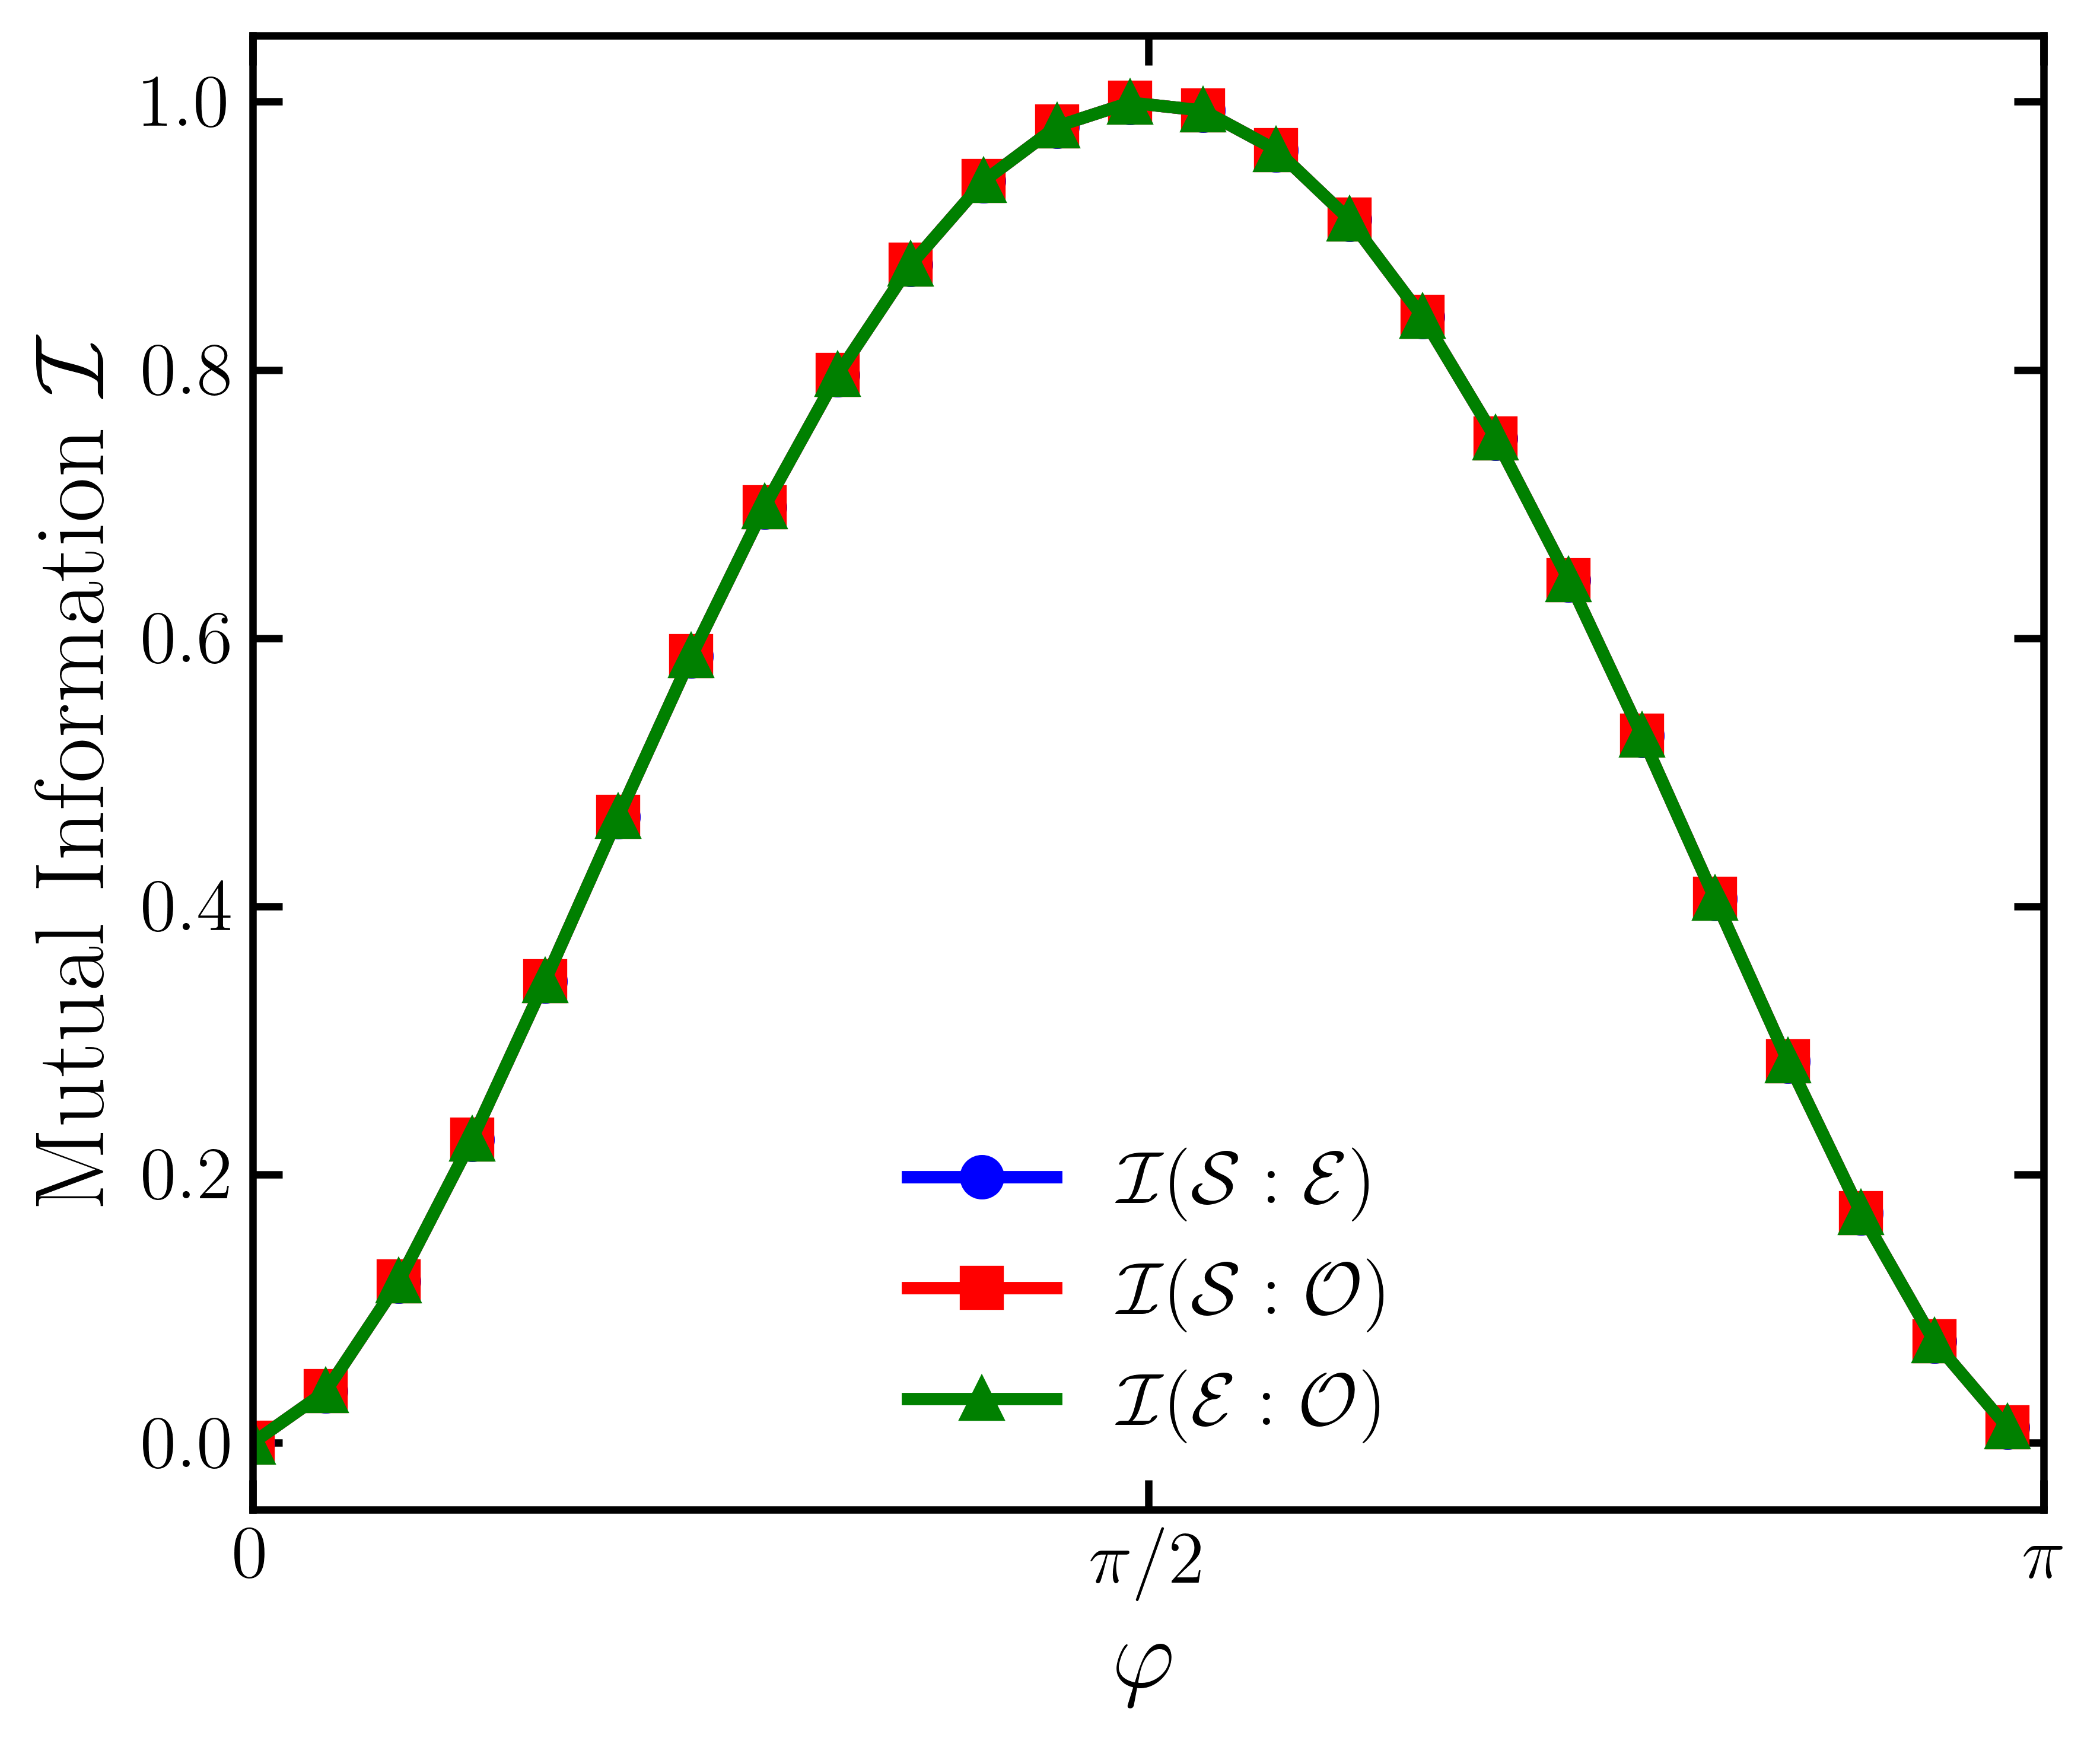

In [3]:
# PLOT QMI vs Phi_sys for Zurek model - I(S:E), I(S:O), I(E:O)
import os
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Cấu hình LaTeX font và môi trường
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# ================== LOAD DATA ==================
with open("3D_QMI_Wigner.pkl", "rb") as f:
    data = pickle.load(f)

# Lấy trục phi_sys
phi_sys_vals = data["Phi_sys"][0, :] 

# Trường hợp vẽ cho toàn bộ môi trường E (f = 100%)
qmi_SE = data["QMI_SE_matrix"][-1, :]  # I(S:E)
qmi_SO = data["QMI_SO_matrix"][-1, :]  # I(S:O)
qmi_EO = data["QMI_EO_matrix"][-1, :]  # I(E:O)

# ================== FILTER DATA (0 to PI) ==================
# Tạo mask để lọc dữ liệu phi_sys <= pi
mask = phi_sys_vals <= (np.pi + 1e-5)

phi_sys_filtered = phi_sys_vals[mask]
qmi_SE_filtered = qmi_SE[mask]
qmi_SO_filtered = qmi_SO[mask]
qmi_EO_filtered = qmi_EO[mask]

# ================== PLOTTING ==================
plt.figure(figsize=(6, 5))

# Vẽ 3 đường QMI theo góc phi_sys đã lọc từ 0 đến pi
plt.plot(phi_sys_filtered, qmi_SE_filtered, 'b-o', linewidth=2.5, markersize=8, label=r"$\mathcal{I}(\mathcal{S}:\mathcal{E})$")
plt.plot(phi_sys_filtered, qmi_SO_filtered, 'r-s', linewidth=2.5, markersize=8, label=r"$\mathcal{I}(\mathcal{S}:\mathcal{O})$")
plt.plot(phi_sys_filtered, qmi_EO_filtered, 'g-^', linewidth=2.5, markersize=8, label=r"$\mathcal{I}(\mathcal{E}:\mathcal{O})$")

# Tùy chỉnh Spines & Ticks chuẩn APS
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

# Format trục X dạng radian chỉ đến pi (0, pi/2, pi)
xticks = [0, np.pi/2, np.pi]
xticklabels = [r"$0$", r"$\pi/2$", r"$\pi$"]
plt.xticks(xticks, xticklabels, fontsize=15)

# Format trục Y
plt.yticks(fontsize=15)
plt.xlabel(r'$\varphi$', fontsize=20)
plt.ylabel(r'Mutual Information $\mathcal{I}$', fontsize=20)

# Legend & Layout
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=2)
plt.xlim(0, np.pi)  # Giới hạn trục X từ 0 đến pi
plt.tight_layout()

# Tạo thư mục và lưu hình
os.makedirs("Figure", exist_ok=True)
plt.savefig(r"Figure/QMI_SEO_vs_PhiSys.png", dpi=600, bbox_inches='tight')
plt.savefig(
    r"Figure/QMI_SEO_vs_PhiSys.eps", 
    dpi=600,
    transparent=False,
    facecolor="white",
    edgecolor="none",
    pad_inches=0.02,
)

plt

In [1]:
# Simulation - Redundancy vs Phi_sys for different Theta values

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate

class QCircuit:    
    def __init__(self, theta, phi_sys, phi_env, n):  
        self.theta = theta        # góc tương tác cu_gate với Environment
        self.phi_sys = phi_sys    # góc quay Ry của System
        self.phi_env = phi_env    # góc cho controlled-U3
        self.n = n        

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System & Observer
        qc.ry(self.phi_sys, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        qc.barrier()
        
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi_env, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits, rho=None):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        if rho is None:
            rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data


class QuantumInformation(): 
    # Von Neumann entropy H(rho)
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
        
    # Quantum mutual information I(A:B) = H(A) + H(B) - H(AB)
    def quantum_mutual_I(self, A_State, B_State, AB_State):
        VNE_A  = self.VNE(A_State)
        VNE_B  = self.VNE(B_State)
        VNE_AB = self.VNE(AB_State)
        return VNE_A + VNE_B - VNE_AB


# ================== Helper Function ==================

def compute_min_qubits_for_redundancy(theta, phi_sys, phi_env, env_qubits, numQubits, QI_calc, delta=0.1):
    """
    Tính số qubit môi trường tối thiểu k sao cho:
    I(S:E_f) >= (1 - delta) * H(S)
    """
    qc = QCircuit(theta, phi_sys, phi_env, numQubits)
    full_rho = qc.DensityMatrix()
    
    rho_S = qc.get_reduced_dm([0], rho=full_rho)
    H_S = QI_calc.VNE(rho_S)
    
    # Trường hợp đặc biệt: Nếu H(S) gần như bằng 0 (trạng thái thuần khiết |0> hoặc |1>)
    # Ngưỡng redundancy bằng 0 và chỉ cần 0 qubit
    if H_S < 1e-6:
        return 0

    threshold = (1.0 - delta) * H_S
    
    # Duyệt số lượng qubit môi trường k từ 1 đến len(env_qubits)
    for k in range(1, len(env_qubits) + 1):
        Ef = env_qubits[:k]
        rho_Ef  = qc.get_reduced_dm(Ef, rho=full_rho)
        rho_SEf = qc.get_reduced_dm([0] + Ef, rho=full_rho)
        
        qmi_SE = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
        
        if qmi_SE >= threshold:
            return k  # Trả về số lượng qubit tối thiểu đạt điều kiện
            
    # Nếu quét hết môi trường vẫn chưa đạt (ví dụ tương tác rất yếu), trả về tổng số qubit môi trường
    return len(env_qubits)


def process_single_theta(theta, phi_sys_vals, phi_env, env_qubits, numQubits, QI_calc, delta):
    """ Hàm tính toán mảng min_qubits theo dải phi_sys cho 1 giá trị theta nhất định """
    min_qubits_list = Parallel(n_jobs=-1)(
        delayed(compute_min_qubits_for_redundancy)(
            theta, phi_sys, phi_env, env_qubits, numQubits, QI_calc, delta
        ) 
        for phi_sys in phi_sys_vals
    )
    return min_qubits_list


# ================== MAIN SIMULATION ==================
if __name__ == "__main__":
    numQubits = 12
    phi_env = 0         # cố định
    delta = 0.1         # hệ số dư thừa (redundancy factor)
    env_qubits = list(range(2, numQubits))  # 10 qubits môi trường
    QI_calc = QuantumInformation()

    phi_sys_vals = np.linspace(0, 2*np.pi, 50)  # vary phi_sys từ 0 đến 2pi
    theta_vals = [0.4 * np.pi, 0.6 * np.pi, 0.8 * np.pi, 1.0 * np.pi]  # 4 giá trị theta

    redundancy_results = {}

    # Chạy vòng lặp cho từng giá trị theta
    for theta in theta_vals:
        print(f"\n---> Đang mô phỏng Redundancy cho theta = {theta/np.pi:.1f}*pi ...")
        min_qubits = process_single_theta(
            theta, phi_sys_vals, phi_env, env_qubits, numQubits, QI_calc, delta
        )
        # Lưu kết quả dạng mảng 1D ứng với dải phi_sys
        redundancy_results[theta] = np.array(min_qubits)

    # Đóng gói dữ liệu xuất file
    data_to_save = {
        "phi_sys_vals": phi_sys_vals,
        "theta_vals": theta_vals,
        "delta": delta,
        "redundancy_results": redundancy_results  # Dict: {theta: array_of_min_qubits}
    }

    # Lưu vào file Redundancy_Wigner.pkl
    output_filename = "Redundancy_Wigner.pkl"
    with open(output_filename, "wb") as f:
        pickle.dump(data_to_save, f)

    print(f"\n[Hoàn tất] Đã lưu dữ liệu vào file '{output_filename}' thành công!")


---> Đang mô phỏng Redundancy cho theta = 0.4*pi ...

---> Đang mô phỏng Redundancy cho theta = 0.6*pi ...

---> Đang mô phỏng Redundancy cho theta = 0.8*pi ...

---> Đang mô phỏng Redundancy cho theta = 1.0*pi ...

[Hoàn tất] Đã lưu dữ liệu vào file 'Redundancy_Wigner.pkl' thành công!


<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

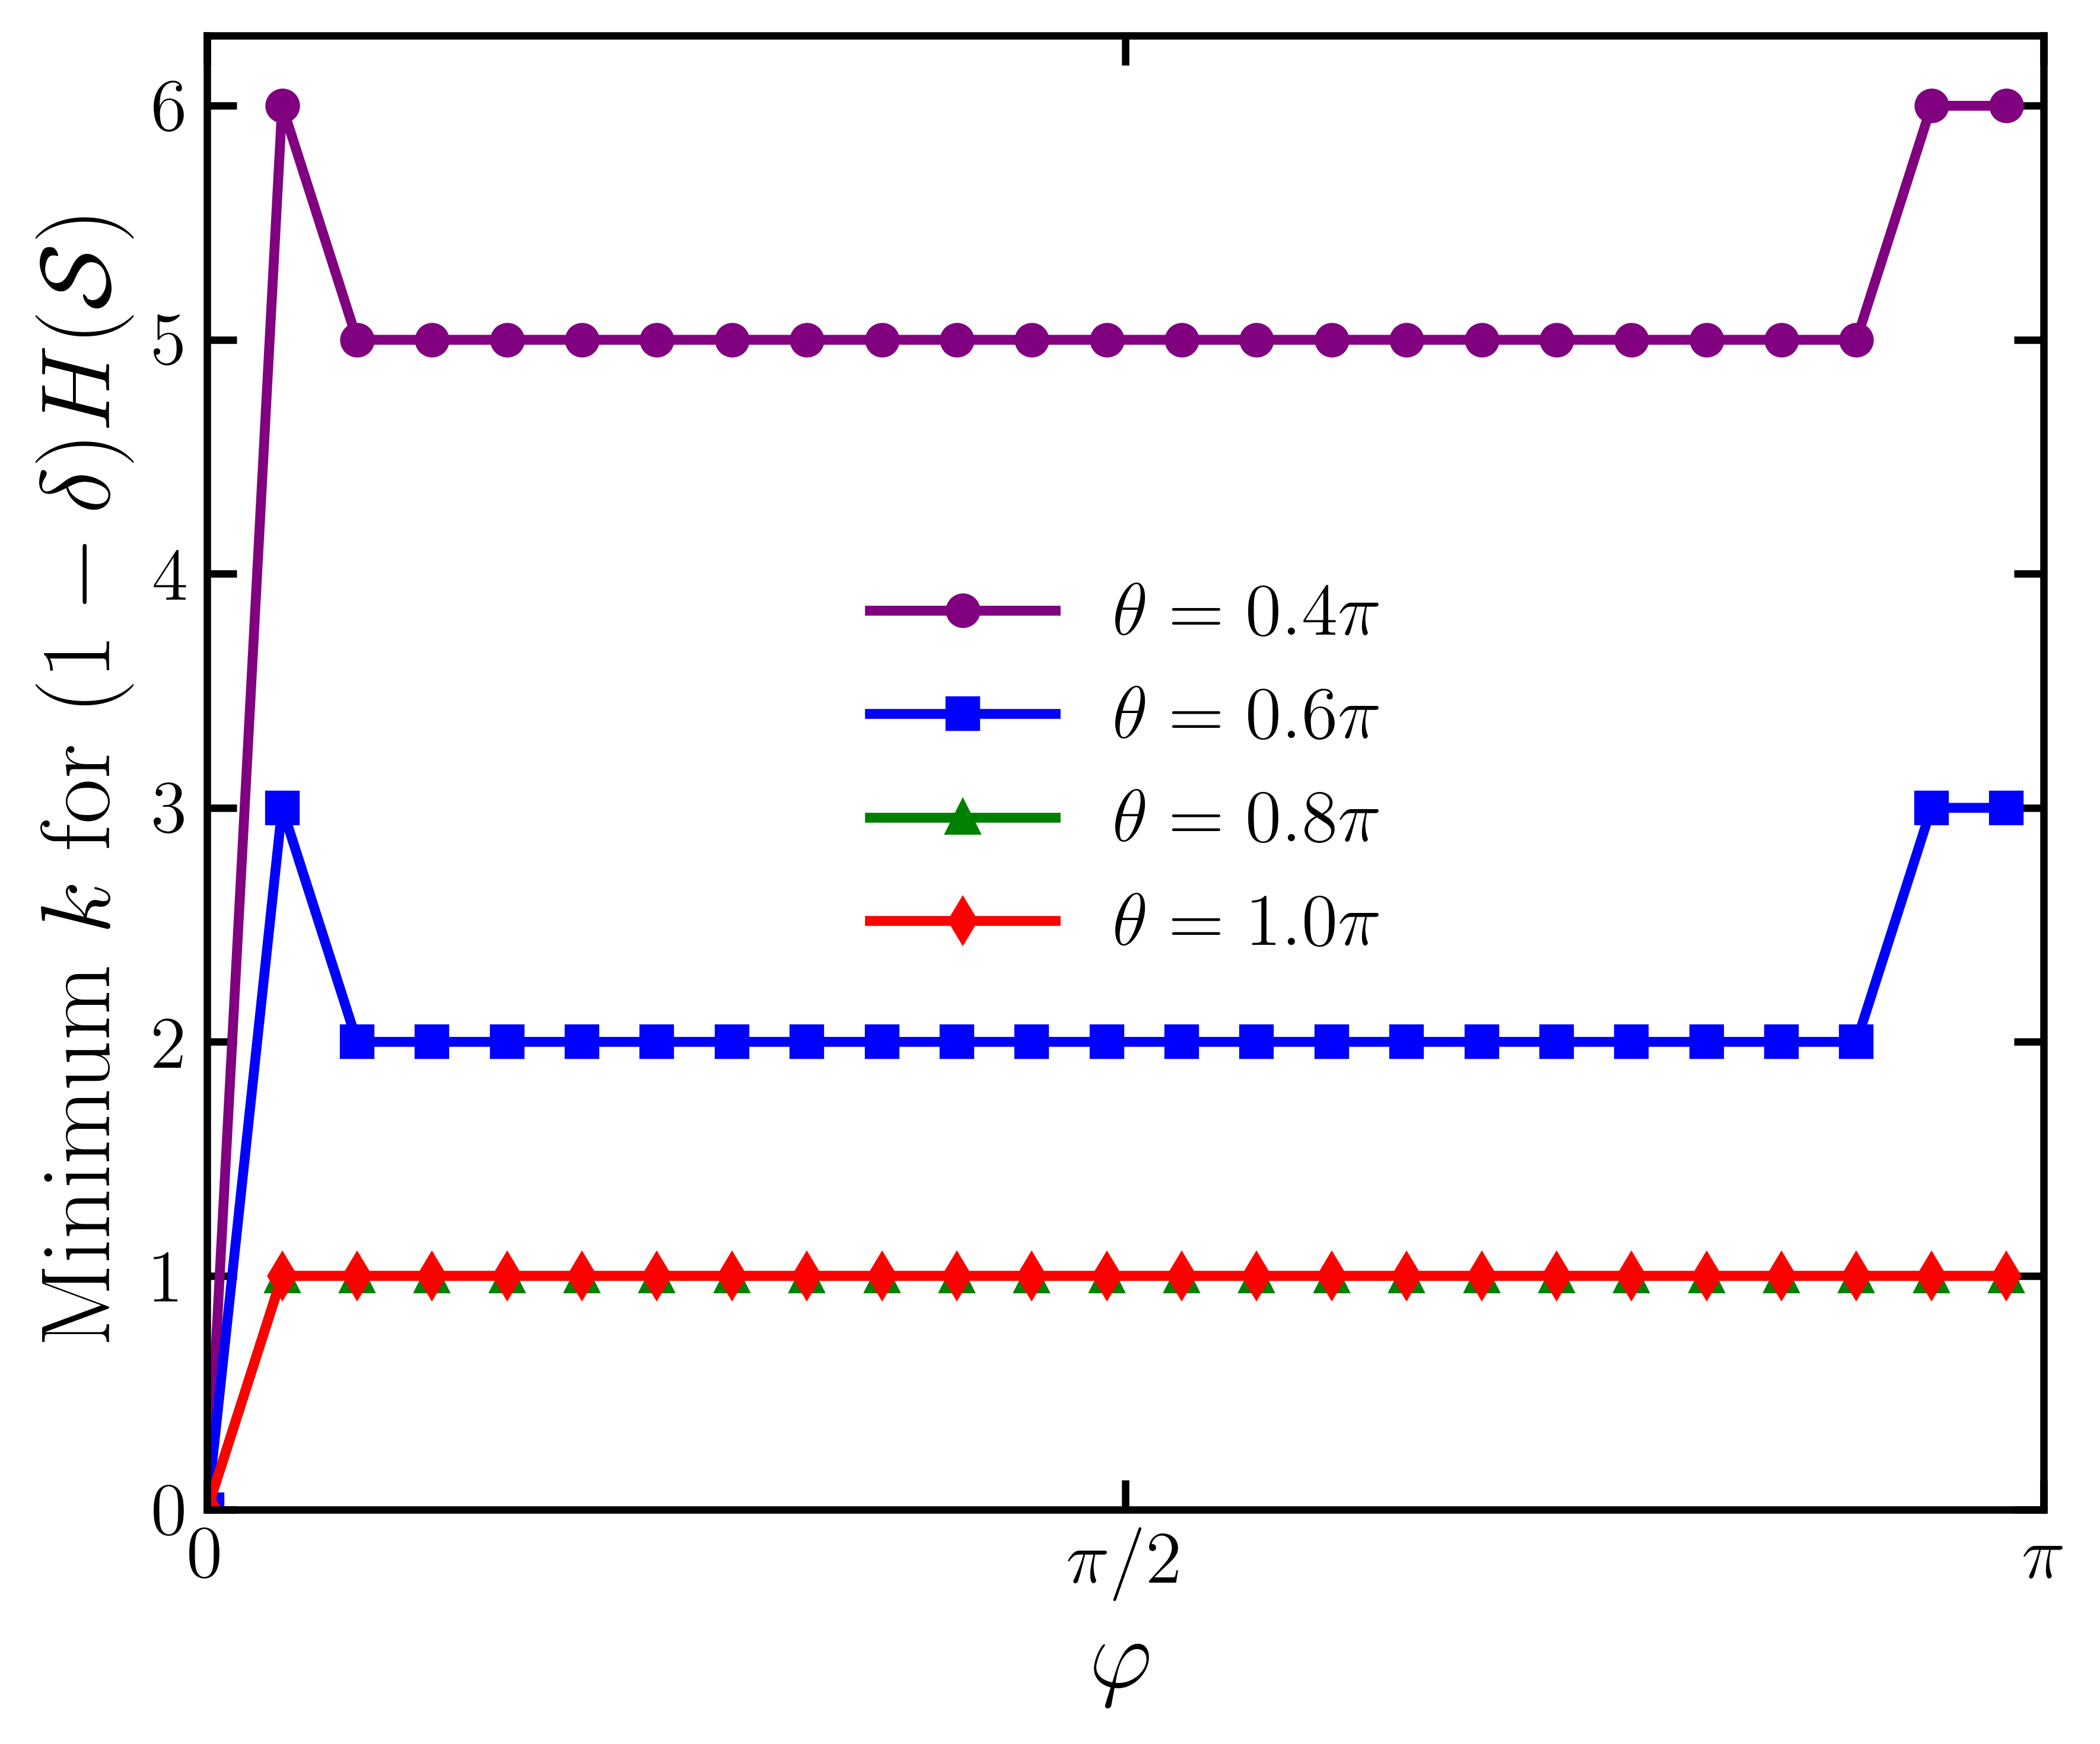

In [2]:
# PLOT Redundancy vs Phi_sys for different Theta values 
import os
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Cấu hình LaTeX font và môi trường chuẩn
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# ================== LOAD DATA ==================
with open("Redundancy_Wigner.pkl", "rb") as f:
    data = pickle.load(f)

phi_sys_vals = np.array(data["phi_sys_vals"])
theta_vals = data["theta_vals"]
redundancy_results = data["redundancy_results"]

# ================== FILTER DATA (0 to PI) ==================
# Lọc mask dữ liệu chỉ lấy giá trị phi_sys <= pi
mask = phi_sys_vals <= (np.pi + 1e-5)
phi_sys_filtered = phi_sys_vals[mask]

# ================== PLOTTING ==================
plt.figure(figsize=(6, 5))

markers = ['o', 's', '^', 'd']
colors = ['purple', 'blue', 'green', 'red']

for i, theta in enumerate(theta_vals):
    label_str = rf"$\theta = {theta/np.pi:.1f}\pi$"
    y_vals = np.array(redundancy_results[theta])[mask]  # Lọc y_vals tương ứng
    
    plt.plot(
        phi_sys_filtered, 
        y_vals, 
        linestyle='-',
        marker=markers[i],
        color=colors[i],
        linewidth=2, 
        markersize=6, 
        label=label_str
    )

# Tùy chỉnh khung và tick mark chuẩn APS
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

# Format trục X chỉ đến PI (0, pi/2, pi)
xticks = [0, np.pi/2, np.pi]
xticklabels = [r"$0$", r"$\pi/2$", r"$\pi$"]
plt.xticks(xticks, xticklabels, fontsize=15)

# Format trục Y (Số lượng qubit môi trường)
plt.yticks(fontsize=15)
plt.xlabel(r'$\varphi$', fontsize=20)
plt.ylabel(r'Minimum $k$ for $(1-\delta)H(\mathcal{S})$', fontsize=20)

# Legend & Limit
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=2.5)
plt.xlim(0, np.pi)  # Giới hạn trục X từ 0 đến PI
plt.ylim(bottom=0)
plt.tight_layout()

# Tạo thư mục và lưu file
os.makedirs("Figure", exist_ok=True)
plt.savefig(r"Figure/Redundancy_vs_PhiSys_Wigner.png", dpi=600, bbox_inches='tight')
plt.savefig(
    r"Figure/Redundancy_vs_PhiSys_Wigner.eps", 
    dpi=600,
    transparent=False,
    facecolor="white",
    edgecolor="none",
    pad_inches=0.02,
)

plt


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

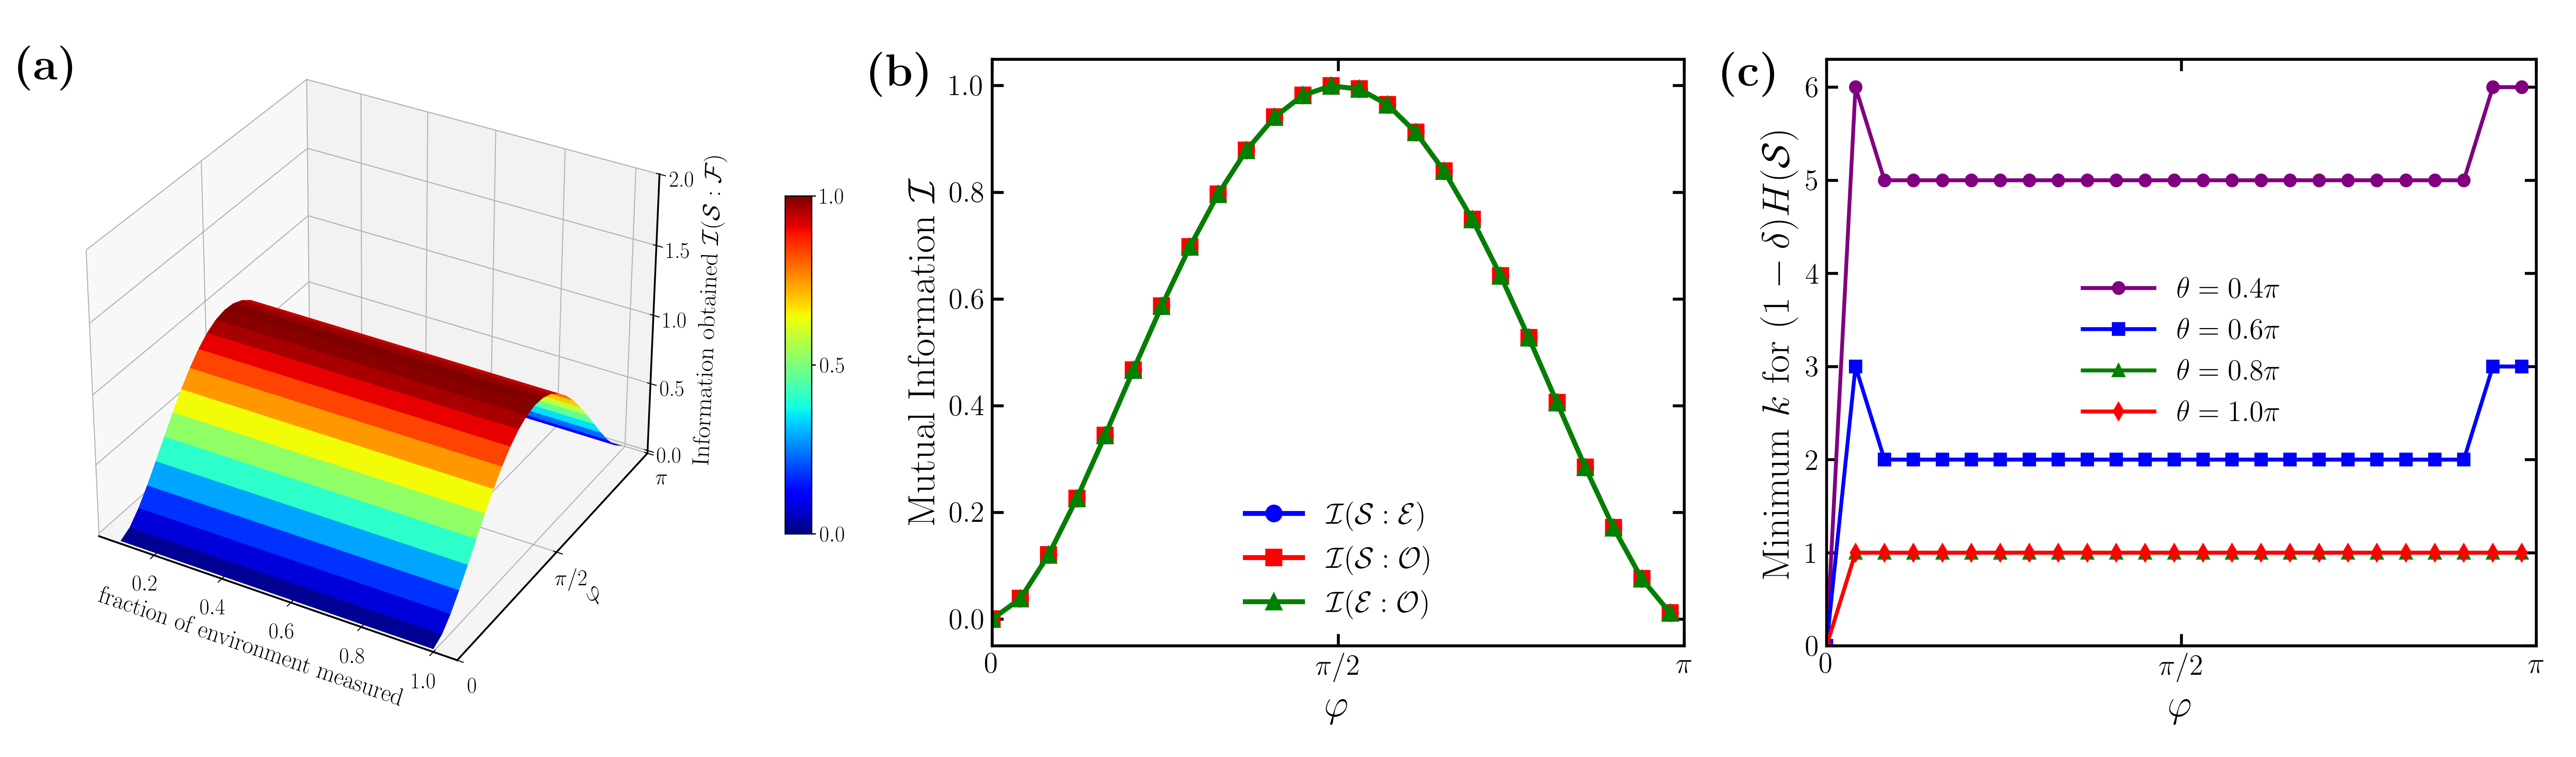

In [4]:
# ============================================================
# TÊN FILE: Merge_Figures_Adjust_Spacing.py
# CHỨC NĂNG: Điều chỉnh khoảng cách giữa 3 hình thực sự hoạt động
# ============================================================

import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# Cấu hình font LaTeX
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Đường dẫn tới 3 hình
img_paths = [
    r"Figure/3D_QMI_Wigner.png",
    r"Figure/QMI_SEO_vs_PhiSys.png",
    r"Figure/Redundancy_vs_PhiSys_Wigner.png"
]

imgs = [Image.open(p) for p in img_paths]

fig = plt.figure(figsize=(18, 5))

# ------------------------------------------------------------
# DÙNG GridSpec ĐỂ KHỐNG CHẾ KHOẢNG CÁCH (wspace)
# Tăng/giảm wspace ở đây (ví dụ: 0.01 là sát rạt, 0.15 là thưa ra)
# ------------------------------------------------------------
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.05)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
labels = [r"\textbf{(a)}", r"\textbf{(b)}", r"\textbf{(c)}"]

# Dời khung hình (a) lên cao
pos_a = axes[0].get_position()
axes[0].set_position([pos_a.x0, pos_a.y0 + 0.03, pos_a.width, pos_a.height])

for i, (ax, img, label) in enumerate(zip(axes, imgs, labels)):
    # Bật aspect='auto' để Matplotlib chịu co giãn theo wspace
    ax.imshow(img, aspect='auto')
    ax.axis('off')
    
    y_pos = 0.96 if i == 0 else 0.99
    ax.text(
        -0.03, y_pos, label, 
        transform=ax.transAxes, 
        fontsize=18, 
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.8, edgecolor='none')
    )

output_png = r"Figure/Combined_3_Plots.png"
output_eps = r"Figure/Combined_3_Plots.eps"

plt.savefig(output_png, dpi=600, bbox_inches='tight', pad_inches=0.01)
plt.savefig(output_eps, dpi=600, bbox_inches='tight', pad_inches=0.01)
plt